# Notebook test - optimisation hyperparametres pre-voyage

Copie independante du notebook final pour tester des optimisations du modele pre-voyage.

Ces essais ne sont ni documentes dans le livrable final, ni industrialises dans `train.py` ou l API.


## 0. Journal de bord du projet

Ce journal de bord synthetise les principales decisions et actions realisees pendant le projet. Il sert de trace de pilotage : chaque ligne indique ce qui a ete fait, pourquoi, le resultat obtenu et la suite retenue.

| Date / periode | Etape | Action realisee | Objectif | Resultat obtenu | Decision | Suite / preuve |
| --- | --- | --- | --- | --- | --- | --- |
| Juin 2026 | Initialisation | Creation de l'environnement Python `.venv`, Git et Docker | Isoler les dependances, versionner le projet et preparer une execution reproductible | Projet structure avec dependances, depot Git et conteneurisation | Retenu | `requirements.txt`, `.gitignore`, `docker-compose.yml` |
| Juin 2026 | Donnees | Identification du dataset `Examen_travel_planning_dataset.csv` | Verifier l'adequation du jeu de donnees aux besoins metier | Dataset synthetique, anonymise et utilisable pour la certification | Retenu | `data/Examen_travel_planning_dataset.csv` |
| Juin 2026 | Datasheet | Documentation du contexte, de la composition, des usages et limites du dataset | Justifier la pertinence et la coherence des donnees | Datasheet ajoutee au notebook final | Retenu | Section `2.1 Datasheet structuree` |
| Juin 2026 | Analyse metier | Controle des incoherences : satisfaction, budget, prix vol, cas operationnels | Identifier les lignes ou variables pouvant fausser la modelisation | Incoherences critiques traitees, incoherences explicables documentees | Retenu | Sections analyse metier et preparation des donnees |
| Juin 2026 | Preparation | Nettoyage, valeurs manquantes, outliers, valeurs negatives et unicite | Renforcer l'integrite des donnees avant modelisation | Donnees nettoyees et controles documentes | Retenu | Sections preparation et controles qualite |
| Juin 2026 | Feature engineering | Creation de variables derivees pre-voyage | Ajouter du contexte metier sans fuite de donnees | Variables pre-voyage conservees, variables post-voyage exclues du modele pre-voyage | Retenu | Liste des features dans le notebook |
| Juin 2026 | Modelisation pre-voyage | Tests de classification 3 classes avec pipeline scikit-learn | Predire la satisfaction probable avant depart | Performance modeste, coherente avec le faible signal pre-voyage | Retenu comme modele industrialise | Resultats `accuracy`, `balanced_accuracy`, `macro_f1` |
| Juin 2026 | Modelisation post-voyage | Tests avec variables operationnelles post-sejour | Comprendre les facteurs expliquant mieux la satisfaction | Scores meilleurs que le pre-voyage mais non retenus pour l'API pre-voyage | Conserve pour analyse qualite | Sections post-voyage |
| Juin 2026 | Ethique et RGPD | Analyse des risques, biais, supervision humaine et registre RGPD | Encadrer l'usage responsable du prototype IA | Risques documentes, usage limite a l'aide a la decision | Retenu | Sections ethique, RGPD et Model Card |
| Juin 2026 | Industrialisation | Creation de `train.py`, API FastAPI, monitoring et interface Streamlit | Servir le modele pre-voyage et tracer les predictions | API locale avec `/health`, `/predict`, `/monitoring/*` | Retenu | `app/`, `train.py`, `app_web.py` |
| Juin 2026 | CI/CD | Ajout du workflow GitHub Actions | Automatiser les tests, la validation notebook et le build Docker | Verification automatique a chaque push / pull request | Retenu | `.github/workflows/ci-cd.yml` |
| 2026-06-21 | C9 amelioration continue | Ajout du quality gate modele | Eviter une degradation silencieuse du modele | Seuils de performance et controle CI/CD ajoutes | Retenu | `configs/model_quality_gate.json`, `scripts/check_model_quality.py` |
| 2026-06-21 | Synthese finale | Centralisation des competences C1 a C9 dans le notebook final | Produire une version propre pour la suite du projet | Notebook final enrichi avec documentation, modelisation et industrialisation | En cours | `notebooks/00_notebook_final_pre_post_voyage.ipynb` |

Ce journal est vivant : il doit etre complete apres chaque decision importante, notamment en cas de nouveau dataset, changement de cible, reentrainement, modification des seuils ou passage en production.



## 0.1 Ordre du livrable selon la grille CISIA

La grille `kit candidat 02_Grille Evaluation_CISIA_V1.0.xlsx` contient 9 competences. Le notebook final est organise pour suivre cet ordre de lecture. Les cellules de code restent placees dans un ordre executable : chargement, nettoyage, modelisation, evaluation, puis industrialisation.

| Competence | Partie principale du notebook | Points couverts | Preuves principales |
| --- | --- | --- | --- |
| C1 | Cadrage, besoins metier, cas d'usage et dataset | Besoin metier, cas d'usage, donnees pertinentes, disponibilite, alternatives | Datasheet, contexte metier, analyse du dataset |
| C2 | Risques ethiques, societaux et registre RGPD | Chartes, impacts, biais, dilemmes, acteurs concernes, verification legale | Analyse ethique, registre RGPD, Model Card |
| C3 | Preparation des donnees | Nommage, formats, valeurs manquantes, doublons, incoherences, stockage, cycle de vie | Nettoyage, controles, feature engineering, gouvernance dataset |
| C4 | Choix du modele IA | Indicateurs, contraintes, familles de modeles, eco-conception, resultat attendu | Comparaison modeles, choix pre-voyage, criteres de decision |
| C5 | Entrainement supervise | Pipeline, hyperparametres, optimisation, validation, feature engineering | Pipelines scikit-learn, Optuna, SMOTE teste, validation croisee |
| C6 | Implementation et integration | Versioning, CI/CD, API, reporting, suivi des predictions | `train.py`, FastAPI, Streamlit, tests, GitHub Actions |
| C7 | Architecture cible | Scenarios d'architecture, contraintes, couts, acteurs a interroger | Schema d'architecture, scenarios local/Docker/cloud/MLOps |
| C8 | Performance et impacts | Metriques, seuils, suivi, interpretation, actions declenchees | Matrices, rapports, monitoring, CodeCarbon, metriques ethiques |
| C9 | Amelioration continue | Evaluation automatisee, metriques integrees, periodicite de revue | Quality gate CI/CD, strategie de reentrainement, monitoring |

Ce plan sert de guide de lecture pour l'evaluateur : chaque competence possede une section explicite ou une table de correspondance avec les preuves techniques du projet.



## C1. Cadrage, besoins metier, cas d usage et dataset

### 1.1 Définition du problème métier

L'agence de voyages souhaite améliorer la personnalisation des séjours et la satisfaction client à partir de l'historique des voyages. Le problème métier concret est double :

- avant le départ, estimer si les informations disponibles lors de la planification suffisent à anticiper la satisfaction client ;
- après le séjour, identifier les facteurs opérationnels associés à une satisfaction faible ou élevée afin d'améliorer les futures propositions.

La cible métier étudiée est `satisfaction_client`. Le projet distingue donc volontairement deux cas d'usage : un objectif pré-voyage, utile pour la planification, et un objectif post-voyage, utile pour l'analyse qualité et l'amélioration continue.

### 1.2 Objectifs IA retenus et règles de fuite de données

| Objectif | Moment d'utilisation | Variables autorisées | Variables exclues |
| --- | --- | --- | --- |
| Pré-voyage | Avant le départ | profil, budget, destination, saison, durée, hébergement, météo prévue, activité | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` |
| Post-voyage | Après ou pendant le séjour | variables pré-voyage + événements opérationnels observés | `retour_client` brut et variables NLP dérivées |

Pour le modèle post-voyage final, la satisfaction est regroupée en 3 classes :

- `0` : insatisfait, notes 1 et 2 ;
- `1` : neutre, note 3 ;
- `2` : satisfait, notes 4 et 5.

Cette séparation évite la fuite de données : les variables connues uniquement pendant ou après le séjour ne doivent pas être utilisées pour prédire la satisfaction avant le départ.

### 1.3 Indicateurs de succès du projet

| KPI | Rôle dans le projet | Seuil ou interprétation attendue |
| --- | --- | --- |
| `macro_f1` | Mesurer la performance globale en tenant compte des classes minoritaires | Indicateur principal pour comparer les modèles |
| `balanced_accuracy` | Vérifier que le modèle ne favorise pas uniquement la classe majoritaire | Doit être supérieur au modèle naïf `Dummy` |
| Matrice de confusion | Identifier les classes les plus confondues | La classe `neutre` est surveillée spécifiquement |
| Stabilité en validation croisée | Vérifier que le score ne dépend pas d'un seul découpage train/test | Écart-type faible recherché |
| Cohérence métier des variables importantes | Vérifier que le modèle s'appuie sur des signaux interprétables | Les variables post-voyage doivent ressortir dans l'objectif post-voyage |
| Absence de fuite de données | Garantir que le modèle respecte le moment d'utilisation prévu | Obligatoire pour comparer pré-voyage et post-voyage |

### 1.4 Contraintes du projet

| Contrainte | Impact sur le projet |
| --- | --- |
| Données synthétiques | Les résultats servent de preuve de méthode, pas de validation opérationnelle sur clients réels. |
| Volume limité, environ 1500 lignes | Les modèles complexes risquent de surapprendre et les performances restent sensibles au split train/test. |
| Sobriete technique | Les traitements lourds, notamment NLP avance ou optimisation massive, doivent rester optionnels ou isoles. |
| Délai de projet de certification | Priorité à une démarche claire, reproductible et documentée plutôt qu'à une optimisation excessive. |
| Contraintes RGPD | Le projet actuel utilise des données synthétiques ; toute donnée réelle nécessiterait un cadrage RGPD renforcé. |
| Industrialisation reportée | Le notebook final doit rester propre et complet avant de figer un pipeline de production. |

### 1.5 L'IA est-elle nécessaire ?

Une solution simple suffit pour certaines parties du projet : règles métier, tableaux de bord, contrôles de cohérence et statistiques descriptives permettent déjà d'identifier des anomalies et des facteurs de risque.

L'IA devient pertinente uniquement si l'objectif est de généraliser ces observations à de nouveaux séjours et de produire une estimation automatisée de la satisfaction. Les expériences du notebook montrent cependant que :

- le cas pré-voyage contient peu de signal prédictif avec les variables disponibles ;
- le cas post-voyage est plus cohérent pour l'analyse qualité, car il utilise les événements réellement observés pendant le séjour ;
- le modèle doit rester une aide à la décision, et non un système de décision automatique.




### C1.1 Documentation metier et datasheet

objectif dataset, datasheet, variables principales et principes de preparation des donnees.



### C1.2 Datasheet structuree du jeu de donnees

Cette sous-section formalise la datasheet du fichier `data/Examen_travel_planning_dataset.csv` selon les dimensions attendues pour documenter un jeu de données utilisé dans un projet IA.

#### Motivation et contexte de collecte

Le dataset est utilisé dans le cadre d'un projet de planification de voyages. L'objectif métier est d'analyser des séjours passés afin de comprendre les facteurs associés à la satisfaction client et d'évaluer la possibilité de construire un modèle de prédiction. Les données sont synthétiques et anonymisées ; elles ne proviennent donc pas d'une collecte client réelle, mais simulent des situations plausibles de voyages avec budgets, destinations, contraintes, imprévus et retours clients.

#### Composition et statistiques descriptives

Le fichier contient environ 1500 lignes et 15 colonnes. Chaque ligne représente un séjour. Les variables couvrent le profil client, le budget, la destination, la saison, la durée, l'hébergement, le prix du vol, la météo prévue, l'activité principale, les imprévus, la réorganisation, le respect du budget, la satisfaction client et le retour textuel. Les statistiques descriptives sont vérifiées dans le notebook : valeurs manquantes, distribution de la cible, types de variables, valeurs uniques, doublons, incohérences métier et valeurs atypiques.

#### Usages recommandés

Le dataset est adapté à l'exploration de données, à l'analyse de cohérence métier, à la comparaison entre un objectif pré-voyage et un objectif post-voyage, ainsi qu'à la construction d'un prototype de modèle IA. Pour le modèle pré-voyage, seules les variables disponibles avant le séjour doivent être utilisées. Pour le modèle post-voyage, les variables d'événements observés comme `imprevus`, `reorganisation_necessaire` et `respect_budget` peuvent être utilisées si l'objectif est l'analyse ou l'évaluation après séjour.

#### Limitations

Le dataset reste synthétique, de taille modérée et ne reflète pas nécessairement toute la complexité d'une activité réelle d'agence de voyages. Certaines variables pré-voyage contiennent peu de signal pour expliquer la satisfaction client. Plusieurs incohérences doivent être contrôlées avant modélisation. Les variables post-voyage ne doivent pas être utilisées dans un modèle censé prédire la satisfaction avant le départ, afin d'éviter une fuite de données.

#### Distribution

Le fichier est stocké localement dans le projet au chemin `data/Examen_travel_planning_dataset.csv`. Comme il s'agit d'un dataset synthétique et anonymisé fourni pour le projet, il peut être versionné dans GitHub dans le cadre de cette certification. Si des données réelles étaient ajoutées ultérieurement, une vérification RGPD, une anonymisation et une politique d'accès seraient nécessaires avant toute diffusion.

#### Maintenance

Toute modification du dataset doit être documentée : ajout de colonnes, correction d'incohérences, enrichissement externe, suppression de lignes ou changement de cible. Les traitements appliqués doivent rester reproductibles dans le notebook. En cas d'évolution du jeu de données, il faudra mettre à jour les statistiques descriptives, les contrôles de cohérence, la liste des variables autorisées et les résultats de modélisation.



## C2. Risques ethiques, societaux et registre RGPD

Dans ce projet, le traitement porte uniquement sur le fichier `data/Examen_travel_planning_dataset.csv`. Ce fichier est un dataset synthétique et anonymisé fourni pour la certification. Il ne contient pas de nom, prénom, email, téléphone, adresse, numéro de passeport ou identifiant client réel. Le registre ci-dessous documente donc le traitement réalisé dans ce projet, et non un traitement opérationnel de données clients réelles.

#### Finalités du traitement

| Finalité | Description |
| --- | --- |
| Documentation du dataset | Décrire le jeu de données utilisé pour répondre au besoin métier de planification de voyages. |
| Analyse de cohérence métier | Vérifier la qualité du fichier : valeurs manquantes, incohérences, doublons, valeurs atypiques. |
| Modélisation pré-voyage | Tester la capacité des variables disponibles avant le séjour à expliquer la satisfaction client. |
| Modélisation post-voyage | Tester l'apport des variables observées pendant ou après le séjour : `imprevus`, `respect_budget`, `reorganisation_necessaire`. |

#### Catégories de données collectées

| Catégorie | Colonnes concernées | Statut dans ce projet |
| --- | --- | --- |
| Identifiant technique | `trip_id` | Identifiant synthétique de ligne, non rattaché à une personne réelle. |
| Profil voyageur simulé | `client_type` | Catégorie générique : famille, couple, solo, business, senior. |
| Caractéristiques du séjour | `destination`, `saison`, `duree_jours`, `type_hebergement`, `activite_principale`, `meteo_prevue` | Variables descriptives du voyage fictif. |
| Données budgétaires simulées | `budget_total`, `prix_vol`, `respect_budget` | Montants fictifs utilisés pour l'analyse et la modélisation. |
| Événements post-voyage simulés | `imprevus`, `reorganisation_necessaire` | Variables opérationnelles fictives connues après ou pendant le séjour. |
| Satisfaction et avis fictifs | `satisfaction_client`, `retour_client` | Score et commentaire synthétiques, sans auteur identifiable. |

Aucune donnée personnelle directement identifiable n'est traitée dans le périmètre actuel du notebook.

#### Durée de conservation

| Élément conservé | Durée retenue pour ce projet |
| --- | --- |
| Dataset brut synthétique | Conservé dans `data/` pendant la durée du projet. |
| Notebooks d'analyse | Conservés dans `notebooks/` pour assurer la traçabilité des choix et des résultats. |
| Documentation projet | Conservée dans `docs/` et dans le notebook final pour justifier la démarche. |

Comme le dataset est synthétique, il n'y a pas de durée de conservation liée à des personnes concernées identifiables dans ce projet.

#### Mesures de sécurité

- Le projet ne versionne que le dataset synthétique fourni pour la certification.
- Aucune donnée client réelle ne doit être ajoutée dans `data/` ou poussée sur GitHub dans cette version du projet.
- Les transformations appliquées au dataset sont documentées dans le notebook afin de conserver une traçabilité complète.

#### Droits des personnes concernées

Dans le périmètre actuel, aucune personne physique identifiable n'est présente dans le dataset. Les droits RGPD individuels ne sont donc pas directement applicables au fichier synthétique utilisé dans ce projet.

Si le périmètre change et que des données clients réelles sont ajoutées, ce registre devra être remplacé par un registre RGPD opérationnel validé avant toute modélisation.



### C2.1 Analyse des risques ethiques et societaux

Cette section identifie les risques ethiques, societaux, juridiques et environnementaux lies a la solution IA de planification de voyages. Elle est adaptee au cas concret du projet : un prototype de certification utilisant un dataset synthetique de sejours passes.

Le support `docs/MOD03-Enjeux.pdf` a ete utilise comme guide methodologique pour renforcer cette analyse : supervision humaine, non-discrimination, transparence, vie privee, durabilite, responsabilite, RGPD, AI Act, AIPD/PIA et documentation de conformite.

#### Positionnement ethique du projet

| Point de cadrage | Position retenue pour ce projet |
| --- | --- |
| Nature de la solution | Prototype IA d'aide a l'analyse et a la decision, pas un systeme de decision automatique |
| Domaine | Planification de voyages haut de gamme et analyse de satisfaction client |
| Donnees | Dataset synthetique et anonymise, sans clients reels identifiables |
| Decision produite | Prediction probabiliste d'une classe de satisfaction, avec incertitude |
| Usage autorise | Aide a l'analyse qualite, comparaison d'experiences de sejour, support a l'amelioration continue |
| Usage interdit dans ce projet | Decision automatique sur un client, exclusion d'une offre, tarification individualisee ou action commerciale sans validation humaine |

#### Principes d'IA societale responsable appliques au projet

| Principe | Risque dans notre projet | Application concrete |
| --- | --- | --- |
| Inclusion | Le modele pourrait mieux representer certains profils de voyageurs que d'autres | Analyse par sous-groupes (`client_type`, `destination`, `imprevus`, `respect_budget`) et prudence sur les segments a faible effectif |
| Transparence | L'utilisateur pourrait croire que le score est une verite certaine | Documentation des variables, de la cible, des limites, de la matrice de confusion et des performances dans la Model Card |
| Responsabilite | Ambiguite sur qui valide ou utilise la prediction | Le modele reste sous responsabilite de l'equipe projet ; toute decision client doit etre validee par un conseiller ou un referent metier |
| Non-discrimination | Risque de favoriser des profils plus fortunes ou certaines destinations | Surveillance des variables proxy : `budget_total`, `prix_vol`, `type_hebergement`, `destination`, `client_type` |
| Protection sociale et impact humain | Risque d'automatiser des recommandations au detriment du conseil humain | Positionnement explicite comme outil d'aide, pas comme remplacement du conseiller voyage |
| Accessibilite | Resultats techniques difficiles a comprendre pour le metier | Restitution avec libelles simples : insatisfait, neutre, satisfait ; metriques expliquees ; documentation en langage metier |
| Co-construction | Risque de definir seul des regles de nettoyage ou d'usage | Les incoherences metier sont documentees et doivent etre validees par le commanditaire avant tout deploiement |

#### Niveau d'automatisation et supervision humaine

Le niveau d'automatisation retenu correspond a une **assistance / augmentation** : l'IA propose une estimation, mais l'humain interprete et decide. Le modele ne doit pas declencher automatiquement une action commerciale ou une decision individuelle.

| Usage | Niveau d'automatisation acceptable | Supervision requise |
| --- | --- | --- |
| Analyse exploratoire du dataset | Faible | Data scientist ou referent metier |
| Prediction post-voyage pour analyse qualite | Assistance | Validation humaine avant toute conclusion operationnelle |
| Recommandation pre-voyage a un client | Assistance uniquement | Conseiller voyage obligatoire, car le score pre-voyage est peu performant |
| Decision commerciale individuelle | Non autorisee dans ce projet | Interdiction d'automatisation complete |

La supervision humaine est particulierement importante car les performances restent moderees et le dataset est synthetique. La prediction doit donc etre lue comme un **signal d'aide a l'analyse**, pas comme une preuve.

#### Referentiels et cadres pris en compte

| Referentiel | Apport pour le projet | Application dans ce notebook |
| --- | --- | --- |
| Lignes directrices europeennes pour une IA digne de confiance | Action humaine, robustesse, vie privee, transparence, diversite, bien-etre societal et responsabilite | Separation pre-voyage/post-voyage, controle des biais, documentation des limites |
| AI Act europeen, reglement UE 2024/1689 | Approche par les risques, obligations renforcees pour les IA a risque eleve | Le projet est qualifie comme prototype non deploye ; une analyse de risque serait obligatoire avant production |
| RGPD et recommandations CNIL | Finalite, minimisation, information, securite, droits des personnes | Registre RGPD adapte au dataset synthetique ; conditions precisees si donnees reelles ajoutees |
| MOD03-Enjeux | Methode projet : supervision, anti-biais, explicabilite, privacy by design, durabilite, documentation | Section ethique renforcee et reliee aux choix de modelisation |
| Model Card et Datasheet | Documentation transparente du dataset et du modele | Datasheet, Model Card, performance par sous-groupes, empreinte carbone et limites |

Sources officielles utilisees : [Commission europeenne - Ethics Guidelines for Trustworthy AI](https://digital-strategy.ec.europa.eu/en/library/ethics-guidelines-trustworthy-ai), [EUR-Lex - Regulation EU 2024/1689 Artificial Intelligence Act](https://eur-lex.europa.eu/eli/reg/2024/1689/oj/eng), [CNIL - fiches pratiques IA](https://www.cnil.fr/fr/les-fiches-pratiques-ia), [CNIL - recommandations IA et RGPD](https://www.cnil.fr/fr/developpement-des-systemes-dia-les-recommandations-de-la-cnil-pour-respecter-le-rgpd), [CNIL / Defenseur des droits - algorithmes et discriminations](https://www.cnil.fr/fr/algorithmes-et-discriminations-le-defenseur-des-droits-avec-la-cnil-appelle-une-mobilisation).

#### Qualification du risque AI Act pour ce projet

| Question | Analyse projet |
| --- | --- |
| Le systeme prend-il une decision produisant un effet juridique ? | Non dans le perimetre actuel |
| Le systeme conditionne-t-il l'acces a un service essentiel ? | Non, il concerne la planification de voyages |
| Le systeme est-il utilise pour emploi, credit, education, police, migration, sante ou infrastructure critique ? | Non |
| Le systeme effectue-t-il une decision automatique individuelle ? | Non, usage prevu comme aide a l'analyse |
| Niveau de risque actuel | Prototype a risque limite, sous reserve de rester non decisionnel |
| Point de vigilance | Si le modele sert plus tard a refuser une offre, modifier un prix ou segmenter commercialement des clients reels, une nouvelle qualification juridique sera necessaire |

#### Impacts ethiques et societaux identifies

| Risque | Consequence possible | Niveau dans ce projet | Mesure de prise en compte |
| --- | --- | --- | --- |
| Utilisation d'un modele peu performant | Recommandations erronees si les scores sont interpretes comme fiables individuellement | Moyen | Comparaison avec baseline, validation croisee, matrice de confusion, documentation des limites |
| Confusion entre pre-voyage et post-voyage | Utiliser des informations connues apres le sejour pour predire avant depart | Eleve si mal utilise | Separation explicite des objectifs et exclusion des variables post-voyage du modele pre-voyage |
| Automatisation excessive | Decisions commerciales prises sans analyse humaine | Moyen | Niveau d'automatisation limite a l'assistance ; validation humaine requise |
| Segmentation injuste des clients | Risque de favoriser certains budgets, profils ou destinations | Moyen | Analyse des variables proxy et performances par sous-groupes |
| Manque de representativite du dataset | Resultats non generalisables a une agence reelle | Eleve | Mention explicite du caractere synthetique, anonymise et limite du dataset |
| Mauvaise interpretation des commentaires clients | Le texte libre peut refleter directement la satisfaction ou contenir des biais de langage | Moyen | `retour_client` exclu du modele principal pour eviter fuite de donnees et surinterpretation |
| Vie privee en cas de donnees reelles | Risque RGPD si avis clients, budgets ou historiques deviennent identifiables | Faible actuellement, eleve si donnees reelles | Dataset synthetique ; obligation future de minimisation, anonymisation, securite et registre RGPD operationnel |
| Impact environnemental des experimentations | Consommation inutile de ressources si multiplication de modeles lourds | Faible a moyen | Modeles tabulaires, `n_jobs=1`, CodeCarbon ajoute, NLP lourd non retenu dans le modele principal |

#### Biais potentiels ou existants

| Biais identifie | Origine possible | Impact metier | Traitement dans le projet |
| --- | --- | --- | --- |
| Biais socio-economique | `budget_total`, `prix_vol`, `type_hebergement`, `destination_luxe` peuvent refleter un niveau de depense | Le modele pourrait associer satisfaction et niveau de budget plutot que qualite reelle du service | Analyse des importances de variables, prudence d'interpretation, modele non decisionnel |
| Biais de profil client | `client_type` distingue famille, couple, solo, business, senior | Risque de recommandations stereotypees selon le profil | Performance par sous-groupes et validation metier avant usage reel |
| Biais de destination | Certaines destinations peuvent etre associees au luxe, a la distance ou a la meteo | Risque de favoriser ou penaliser certaines destinations | Enrichissement limite et documente ; variables non retenues supprimees de la modelisation |
| Biais de classe cible | Les classes de satisfaction ne sont pas parfaitement equilibrees | Le modele peut mieux predire les classes majoritaires | Controle de l'equilibre des classes, `macro_f1`, `balanced_accuracy`, matrice de confusion |
| Biais de donnees synthetiques | Le dataset ne provient pas d'observations reelles | Les relations apprises peuvent etre artificielles | Limitation clairement documentee dans la datasheet et la Model Card |
| Biais de variables post-voyage | `imprevus`, `respect_budget`, `reorganisation_necessaire` sont connues pendant ou apres le sejour | Risque de fuite si utilisees pour un usage pre-voyage | Variables exclues du modele pre-voyage et autorisees uniquement dans l'objectif post-voyage |
| Biais de proxy | Budget, type d'hebergement ou destination peuvent indirectement approximer un niveau social | Risque de discrimination indirecte si le modele est utilise commercialement | Surveillance obligatoire avant deploiement et interdiction d'usage automatique individuel |

#### Verification anti-biais prevue

| Controle | Mise en oeuvre dans le projet | Limite actuelle |
| --- | --- | --- |
| Audit des donnees | Distribution des classes, valeurs manquantes, incoherences metier, valeurs uniques | Dataset synthetique, donc representativite non garantie |
| Variables protegees | Aucune variable sensible directe n'est presente | Des proxys peuvent exister : budget, destination, hebergement |
| Performances par sous-groupes | Section Model Card : sous-groupes `client_type`, `destination`, `imprevus`, `respect_budget`, `reorganisation_necessaire` | Supports faibles possibles sur certains groupes |
| Metriques d'equite | `macro_f1`, `balanced_accuracy`, performances par segment | Les metriques d'equite avancees ne sont pas toutes pertinentes sans variable protegee explicite |
| Mitigation | Documentation, separation des objectifs, exclusion des variables a fuite, limitation de l'automatisation | Reweighting ou debiasing non applique, faute de donnees reelles validees |
| Monitoring futur | Derive des donnees, derive des performances, evolution des sous-groupes | A mettre en place uniquement apres industrialisation |

#### Transparence et explicabilite

Le projet doit fournir une explication adaptee au public cible :

| Public | Niveau d'explication attendu | Application projet |
| --- | --- | --- |
| Commanditaire | Resume metier, limites, performance globale, risques | Synthese finale, Model Card, matrice de confusion |
| Conseiller voyage | Classe predite, probabilites, facteurs principaux | Usage futur possible avec notice d'utilisation |
| Data scientist | Pipeline, features, hyperparametres, validation croisee | Notebook final, MLflow, code reproductible |
| Juriste / DPO | Donnees traitees, finalites, droits, risques RGPD | Registre de traitement, datasheet, verification avant donnees reelles |

Dans cette version, l'explicabilite repose surtout sur :

- la documentation des variables utilisees et exclues ;
- la comparaison des modeles avec metriques lisibles ;
- la matrice de confusion et le rapport de classification ;
- les performances par sous-groupes ;
- la Model Card.

#### Vie privee, RGPD et privacy by design

| Principe | Application actuelle | Action si donnees reelles |
| --- | --- | --- |
| Finalite | Analyser la satisfaction et tester un prototype IA | Formaliser les finalites dans un registre RGPD operationnel |
| Minimisation | Variables limitees au dataset fourni | Justifier chaque donnee client collectee |
| Exactitude | Controle des incoherences, types et valeurs manquantes | Prevoir correction et mise a jour des donnees |
| Conservation limitee | Donnees synthetiques conservees pour le projet | Definir une duree de conservation documentee |
| Integrite et confidentialite | Pas de donnees reelles dans GitHub | Chiffrement, controle d'acces, pseudonymisation si donnees reelles |
| Transparence | Registre RGPD et datasheet dans le notebook | Notice d'information claire aux clients |
| Droits des personnes | Non applicable au dataset synthetique | Processus d'acces, rectification, opposition, effacement et portabilite |

Une AIPD/PIA n'est pas requise pour ce notebook synthetique. Elle deviendrait a examiner si le projet traite des donnees clients reelles a grande echelle, effectue du profilage, produit des decisions automatiques significatives ou utilise des donnees sensibles.

#### Bien-etre societal et durabilite

| Sujet | Risque | Mesure dans le projet |
| --- | --- | --- |
| Sobriete des modeles | Multiplier les tests lourds sans gain metier | Modeles tabulaires simples privilegies, NLP lourd non retenu |
| Sobriete numerique | Limiter les traitements couteux et garder une solution maintenable | `n_jobs=1`, grilles d'optimisation limitees, tests separes |
| Empreinte carbone | Couts invisibles des entrainements repetes | Section CodeCarbon ajoutee a la Model Card |
| Pertinence metier | Optimiser une metrique sans valeur operationnelle | Comparaison pre-voyage/post-voyage et documentation des limites |
| Impact sur le conseil humain | Risque de remplacer l'expertise metier | Modele positionne comme aide a l'analyse, pas comme substitution |

#### Dilemmes ethiques identifies

| Dilemme | Description | Position retenue |
| --- | --- | --- |
| Personnalisation vs discrimination | Personnaliser un voyage peut ameliorer l'experience, mais aussi enfermer certains profils dans des recommandations stereotypees | Utiliser le modele comme aide, pas comme regle automatique de proposition |
| Optimisation commerciale vs interet client | Le modele pourrait etre utilise pour privilegier les sejours les plus rentables plutot que les plus adaptes | Garder la satisfaction client comme cible centrale et documenter les variables budgetaires |
| Performance vs explicabilite | Des modeles plus complexes peuvent parfois mieux performer mais etre moins interpretables | Privilegier des modeles comparables, une matrice de confusion, les performances par groupes et une Model Card |
| Donnees post-voyage vs prediction avant depart | Les variables post-voyage ameliorent les scores mais ne sont pas disponibles avant depart | Separer strictement les objectifs pre-voyage et post-voyage |
| Automatisation vs controle humain | Automatiser l'analyse peut accelerer le traitement mais reduire la vigilance metier | Maintenir une validation humaine, surtout pour toute decision concernant un client ou une offre |
| Donnees synthetiques vs realisme operationnel | Le dataset permet de prototyper mais ne prouve pas la performance en production | Presenter les resultats comme demonstration methodologique uniquement |

#### Acteurs a informer et verifications attendues

| Acteur concerne | Informations a porter a sa connaissance | Verification attendue | Statut dans ce projet |
| --- | --- | --- | --- |
| Commanditaire / agence de voyages | Performances modestes, limites du dataset, usage recommande du modele | Valider que le modele sert d'aide a l'analyse et non de decision automatique | A presenter avec la synthese finale |
| Referent metier | Coherence des variables, regles de nettoyage, interpretation des incoherences | Confirmer que les regles metier sont acceptables | Partiellement traite dans l'analyse metier du notebook |
| Juriste / DPO | Absence de donnees personnelles reelles, conditions en cas de donnees reelles, besoin potentiel d'AIPD | Verifier la conformite RGPD avant tout passage a des donnees clients reelles | Documente dans le registre RGPD ; validation externe necessaire si deploiement |
| Equipe data / IA | Fuite de donnees, biais, metriques, sous-groupes, reproductibilite, empreinte carbone | Revoir les features, metriques, seuils, limites techniques et logs MLflow | Documente dans le notebook, la Model Card et MLflow |
| Utilisateurs metier futurs | Fonctionnement general, limites, conditions de mauvais fonctionnement, supervision humaine | Notice d'utilisation avant deploiement | Non encore applicable, industrialisation reportee |
| Evaluateur certification | Demarche, sources, limites, arbitrages | Verifier que les risques sont identifies et pris en compte | Couvert par cette section et les sections precedentes |

#### Documentation de conformite associee

| Document | Statut dans le projet | Commentaire |
| --- | --- | --- |
| Datasheet | Presente | Decrit motivation, composition, usages, limites, distribution et maintenance du dataset |
| Registre de traitement RGPD | Present | Adapte au dataset synthetique ; a refaire si donnees reelles |
| Model Card | Presente | Documente modele, performances, limites, biais et empreinte carbone |
| Rapport de performance | Present dans le notebook | `results_pre`, `results_post`, validation croisee, matrice de confusion, sous-groupes |
| Notice utilisateur | A produire si deploiement | Devra decrire finalite, entrees attendues, limites, supervision humaine et cas de mauvais fonctionnement |
| AIPD/PIA | Non requise actuellement | A evaluer si donnees reelles, profilage a grande echelle ou decisions automatiques significatives |
| Procedure d'incident | Hors perimetre actuel | Necessaire en production : erreur de prediction, biais detecte, violation de donnees, derive modele |

#### Mesures concretes appliquees dans le notebook

- Les objectifs pre-voyage et post-voyage sont separes pour eviter la fuite de donnees.
- Les variables `imprevus`, `respect_budget`, `reorganisation_necessaire` sont exclues du modele pre-voyage.
- Le texte libre `retour_client` est exclu du modele principal pour eviter une fuite directe du ressenti client.
- Les performances sont comparees a un modele naif et evaluees avec `macro_f1`, `balanced_accuracy`, validation croisee, matrice de confusion et rapport de classification.
- L'equilibre des classes est controle apres nettoyage, apres feature engineering et sur le modele post-voyage.
- Les performances par sous-groupes sont calculees dans la Model Card pour identifier d'eventuelles fragilites par segment.
- Des metriques quantitatives dediees aux enjeux societaux sont ajoutees dans la Model Card : ecarts de performance entre sous-groupes, taux de prediction satisfait, indicateurs de supervision humaine et synthese de risque.
- Les limites du dataset synthetique sont documentees dans la datasheet, le registre RGPD et la Model Card.
- La tracabilite experimentale est prevue avec MLflow.
- L'empreinte carbone est integree a la Model Card via une cellule CodeCarbon.
- Les modeles lourds et experimentations a forte consommation sont limites ou non retenus lorsque le gain metier est insuffisant.

#### Conclusion ethique pour ce projet

Dans son perimetre actuel, la solution IA reste un prototype de certification utilisant un dataset synthetique et anonymise. Le risque legal immediat est limite, mais le risque methodologique et ethique principal concerne la mauvaise interpretation du modele : il ne doit pas etre utilise comme outil de decision automatique ni comme preuve de performance operationnelle.

La solution est acceptable uniquement comme **aide a l'analyse** avec supervision humaine. Avant tout deploiement reel, il faudrait valider le besoin metier, tester les biais sur donnees reelles, documenter une notice d'utilisation, verifier la qualification AI Act, completer le registre RGPD, evaluer la necessite d'une AIPD et definir une gouvernance claire des responsabilites, incidents, audits et mises a jour du modele.




1. Objectif de l'etape 
L'objectif de cette etape est d'identifier et de justifier un jeu de donnees capable de repondre aux besoins metiers et aux cas d'usage du projet IA. 

Le jeu de donnees etudie est : 

data/Examen_travel_planning_dataset.csv 
 
Il concerne la planification de voyages et contient des informations sur les clients, les destinations, les budgets, les vols, la meteo, les activites, les imprevus et les retours clients. 

2. Datasheet du jeu de donnees 

Cette datasheet synthetise les informations essentielles sur le dataset. 

#### Identification

| Element | Description |
| --- | --- |
| Nom du fichier | `Examen_travel_planning_dataset.csv` |
| Emplacement | `data/Examen_travel_planning_dataset.csv` |
| Format | CSV |
| Domaine metier | Planification de voyages haut de gamme |
| Volume | 1500 lignes, 15 colonnes |
| Acces | Disponible localement dans le projet |
| Nature des donnees | Donnees synthetiques et anonymisees |
| Usage principal | Analyse et prediction liees a la personnalisation des sejours |


3.Description generale 

Le dataset represente des voyages planifies pour differents profils de clients. Chaque ligne correspond a un voyage et contient des informations sur le budget, la destination, la saison, la duree, l'hebergement, le vol, la meteo prevue, les activites, les imprevus, la satisfaction et le respect du budget. 



#### Variables principales

| Colonne | Type metier | Utilite pour le projet |
| --- | --- | --- |
| `trip_id` | Identifiant | Suivi technique, a exclure du modele |
| `client_type` | Categorie client | Adapter les propositions au profil du voyageur |
| `budget_total` | Numerique | Tenir compte de la contrainte budgetaire globale |
| `destination` | Categorie | Comparer les destinations possibles |
| `saison` | Categorie | Tenir compte de la periode du voyage |
| `duree_jours` | Numerique | Evaluer l'impact de la duree du sejour |
| `type_hebergement` | Categorie | Evaluer l'impact du logement sur l'experience |
| `prix_vol` | Numerique | Mesurer l'impact du prix du billet d'avion sur le budget total |
| `meteo_prevue` | Categorie | Anticiper les risques lies a la meteo |
| `activite_principale` | Categorie | Relier le sejour aux centres d'interet du client |
| `satisfaction_client` | Numerique | Cible principale recommandee pour evaluer la qualite du sejour |
| `imprevus` | Categorie | Cible ou variable d'analyse pour comprendre les incidents |
| `reorganisation_necessaire` | Binaire | Indique si un voyage a dû être réorganisé ou pas, Peut servir de cible à prédire  |
| `respect_budget` | Binaire | Indiquer si le budget prévu a été respecté ; cette colonne est une cible principale provisoire |
| `retour_client` | Texte | Exploitable plus tard pour une analyse NLP |


4.Cibles IA possibles 


| Cible | Priorite | Type de probleme | Interet metier |
| --- | --- | --- | --- |
| `satisfaction_client` | Principale recommandee | Regression ou classification ordinale | Predire la qualite attendue d'un sejour et guider la personnalisation |
| `reorganisation_necessaire` | Secondaire | Classification binaire | Anticiper les sejours qui risquent d'etre reorganises |
| `respect_budget` | Secondaire | Classification binaire | Controler le risque de non-respect du budget |
| `imprevus` | Secondaire ou future | Classification multiclasses | Anticiper le type d'incident possible |
| `retour_client` | Future | Analyse de texte | Exploiter les avis clients pour ameliorer les propositions |


5.Qualite et points de vigilance 

| Point controle | Observation |
| --- | --- |
| Fichier accessible | Oui |
| Format lisible | Oui, csv |
| Valeurs manquantes  | Presentes sur plusieurs colonnes |
| Variables categorielles | Plusieurs colonnes a encoder |
| Variables numeriques | Budget, duree, prix du vol, satisfaction |
| Confidentialite | Donnees synthetiques et anonymisees, utilisables dans le cadre de la certification |

6.Usage prevu 

Le dataset est prevu pour : 
-Analyser les facteurs qui influencent la satisfaction client ; 
-Entrainer un premier modele de prediction de satisfaction ; 


7. Besoins metiers identifies 

L'agence de voyages souhaite proposer une planification haut de gamme plus personnalisee, plus fiable et plus reactive face aux imprevus. 

Les besoins metiers identifies sont : 
-recommander des destinations adaptees au profil du voyageur ; 
-tenir compte du budget, des centres d'interet, de la saison et de la duree ; 
-planifier les elements logistiques : vol, hebergement et organisation du sejour ; 
-anticiper les imprevus comme la meteo, les retards, les annulations ou les problemes de bagages ; 
-identifier les voyages qui risquent de necessiter une reorganisation ; 
-ameliorer la satisfaction client ; 
-exploiter les retours clients pour ameliorer les futures propositions ; 

8. Cas d'usage decrits 

Cas d'usage 1 - Recommandation personnalisee de sejour 
Le modele predit la satisfaction attendue pour differentes options de sejour. 
Variable cible principale : 
satisfaction_client 
Exemple d'utilisation : 
Pour un client de type couple, avec un budget donné, une saison, une duree et des activites preferees, le modele peut comparer plusieurs destinations ou types d'hebergement et estimer la satisfaction attendue. 

Cas d'usage 2 - Anticipation des reorganisation et imprevus 
Le modele peut aider a estimer si un sejour risque de necessiter une reorganisation. 
Variable cible possible : 
reorganisation_necessaire 
Autre cible possible : 
imprevus 
Exemple d'utilisation : 
Avant le depart, l'agence identifie les voyages sensibles selon la destination, la saison, la meteo prevue, le type d'hebergement ou le type d'activite. 

Cas d'usage 3 - Controle du respect du budget 
Le modele peut apprendre a predire si un voyage respectera le budget prevu. 
Variable cible possible : 
respect_budget 

Exemple d'utilisation : 
Un conseiller renseigne le profil du client, la destination, la saison, la duree, le type d'hebergement et le prix du vol. Le modele indique si le sejour presente un risque de non-respect du budget. 
 
Cas d'usage 4 - Amelioration continue avec les retours clients 
Le texte libre des retours clients peut etre exploite dans une phase future. 
Variable exploitable : 
retour_client 

Exemple d'utilisation : 
Les commentaires clients peuvent etre analyses pour extraire des themes recurrents : satisfaction, deception, probleme logistique, qualite de l'hebergement ou meteo. 


5. Donnees disponibles dans le fichier
 

6. Choix de la cible principale 

Compte tenu du contexte, la cible la plus pertinente est satisfaction_client. 

Justification metier 

Le projet demande une solution centree sur la satisfaction client. L'objectif n'est pas seulement de respecter un budget ou d'eviter une reorganisation, mais de proposer un sejour personnalise et de qualite. 

satisfaction_client mesure directement le resultat metier recherche : l'experience finale du client. 

Justification IA 

Cette cible permet de construire un modele capable d'estimer la satisfaction attendue pour une proposition de sejour. Le conseiller peut ensuite comparer plusieurs options et choisir celle qui maximise la satisfaction tout en respectant les contraintes.

7. Donnees pertinentes pour alimenter le modele IA 

Pour un modele de prediction de satisfaction, les donnees a priori pertinentes sont les informations disponibles avant ou pendant la planification du sejour : (9 colonnes) 

client_type ; 
budget_total ; 
destination ; 
saison ; 
duree_jours ; 
type_hebergement ; 
prix_vol ; 
meteo_prevue ; 
activite_principale; 
Variable cible : satisfaction_client 

8. Donnees necessaires pour le modèle IA  

| Donnee necessaire | Pourquoi elle est utile |
| --- | --- |
| client_type | Adapter la recommandation au profil du voyageur |
| budget_total | Respecter la contrainte budgetaire |
| destination | Comparer les options de sejour |
| saison | Tenir compte de la periode du voyage |
| duree_jours | Adapter la proposition a la duree disponible |
| type_hebergement | Evaluer l'impact du logement sur l'experience |
| prix_vol | Integrer le cout du transport |
| activite_principale | Representer le centre d'interet principal |
| satisfaction_client | Variable cible pour entrainer le modele |


9. Pertinence et representativite du dataset 

Le dataset est pertinent pour le projet car il couvre plusieurs dimensions metier importantes : 

profils clients : business, solo, senior, couple, famille ; 
destinations variees : New York, Rome, Lisbonne, Bali, Paris, Dubai, Tokyo, Sydney ; 
saisons : automne, ete, printemps, hiver ; 
types d'hebergement : villa, appartement, hotel, resort ; 
meteo prevue : ensoleille, pluie, variable, nuageux ; 
activites : culture, plage, business, gastronomie, randonnee ; 
imprevus : meteo, retard de vol, bagages, annulation, aucun. 

Repartition observee de quelques variables : 
| Variable | Repartition observee |
| --- | --- |
| client_type  | 5 profils clients differents |
| destination | 8 destinations differentes |
| saison | 4 saisons representees  |
| respect_budget | 1041 valeurs 1, 459 valeurs 0 |
| reorganisation_necessaire | 830 valeurs 1, 670 valeurs 0 |

10. Verification de coherence initiale 
Une premiere verification du fichier a ete realisee. 
Valeurs numeriques observees :

| Colonne | Minimum | Maximum | Moyenne |
| --- | --- | --- | --- |
| budget_total | 380.0 | 41000.0 | 7194.04 |
| duree_jours | 2 | 42 | 10.45 |
| prix_vol | 35.0 | 5200.0 | 1125.81 |
| satisfaction_client | 0.0 | 7.0 | 2.78 |

Distribution observee de satisfaction_client : 

| Valeur | Nombre de lignes |
| --- | ---: |
| Valeur manquante | 25 |
| `0.0` | 1 |
| `1.0` | 258 |
| `2.0` | 427 |
| `3.0` | 353 |
| `4.0` | 258 |
| `5.0` | 174 |
| `6.0` | 3 |
| `7.0` | 1 |

Valeurs manquantes observees :

| Colonne | Valeurs manquantes |
| --- | ---: |
| `budget_total` | 40 |
| `type_hebergement` | 36 |
| `prix_vol` | 53 |
| `meteo_prevue` | 39 |
| `activite_principale` | 48 |
| `satisfaction_client` | 25 |
| `imprevus` | 53 |
| `retour_client` | 25 |

#### Point de coherence sur la satisfaction

Le contexte du projet indique que `satisfaction_client` est un score de `1 a 5`.
Le fichier observe contient cependant quelques valeurs hors de cette echelle :
`0.0`, `6.0` et `7.0`.

Ce point doit etre documente et traite avant l'entrainement :

- soit en corrigeant ou filtrant les valeurs hors echelle ;
- soit en justifiant une echelle differente si elle est confirmee par le metier ;
- soit en regroupant les scores dans des classes de satisfaction.


#### Ajouter les différentes incohérences 
L’incohérence prix_vol > budget_total

Le budget_total représente le budget global du séjour et nous admettons que prix_vol représente seulement le coût du vol aller-retour.
Donc si prix_vol > budget_total, le séjour est incohérent : le transport dépasse déjà tout le budget disponible.
Impact Sur Le Modèle : Cette incohérence peut fausser :
-les relations entre budget et satisfaction ;
-les variables dérivées comme ratio_vol_budget ;
-l’apprentissage du modèle si ces lignes restent dans les données.


L'incohérence prix_vol > budget_total avec respect_budget = 1
prix_vol > budget_total signifie que le vol dépasse déjà le budget total.
respect_budget = 1 signifie que le budget aurait été respecté.
Les deux informations se contredisent.
...

...

...


12. Limites identifiees 

Malgre sa pertinence, le dataset presente plusieurs limites : 
-certaines colonnes contiennent des valeurs manquantes ; 
-le volume reste modéré avec 1500 lignes ; 
-le fichier est un dataset synthetique de projet ; 
-Plusieurs incohérences ont été identifiées et doivent être prises en compte avant la modélisation.
-la colonne retour_client est textuelle et demandera un traitement specifique ; 

13. Solutions alternatives

Alternative pour les données synthétiques 
Les données sont synthétiques il y a possibilité d’enrichir le dataset en cas d’insuffisance de données. 


## C3. Preparation des donnees, integrite et pertinence
### Traitement des incohérences 

#### Uncité 

#### Validité 
respect du format 

#### Satisfaction_client
Pour satisfaction_client, comme c’est la cible du modèle.
La cible doit être entre 1 et 5.
le traitement le plus pertinent est de :
Supprimer les lignes où satisfaction_client est manquante.
Supprimer les lignes où satisfaction_client n’est pas entre 1 et 5.

#### Prix_vol > budget_total
Comme il s’agit d’une incohérence forte sur deux variables d’entrée, le plus propre est de supprimer ces lignes.
Pourquoi supprimer plutôt que corriger ?
On n’a pas la vraie valeur correcte.
Remplacer prix_vol ou budget_total inventerait une information.
Le nombre de cas reste est de 52 lignes. 

### Prix_vol > budget_total avec respect_budget = 1
Nombre de cas : 5
Cette incohérence est incluse dans le contrôle plus général prix_vol > budget_total. Le traitement précédent supprime donc automatiquement ces cas, sans nécessiter une règle de nettoyage supplémentaire.

### Autres incohérences : 
Les autres incohérences concernent les variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client
Ces variables sont connues après le voyage.
Or notre modèle cherche à prédire satisfaction_client avant ou au moment de la planification du séjour.
Nous gardons ces colonnes dans le dataset pour l’analyse métier par ailleurs nous les exclurons du modèle pour éviter la fuite des données.



### C3.1 Imports et configuration



In [119]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd

import mlflow
import mlflow.sklearn
import optuna

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MLFLOW_TRACKING_URI = f"sqlite:///{(PROJECT_ROOT / 'mlflow.db').as_posix()}"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("travel_planning_satisfaction")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

RANDOM_STATE = 42
TARGET_COLUMN = "satisfaction_client"


MLflow tracking URI: sqlite:///c:/Users/khadi/Downloads/Examen_IA/mlflow.db


### C3.2 Chargement du dataset



In [120]:
data_path = Path("..") / "data" / "Examen_travel_planning_dataset.csv"
if not data_path.exists():
    data_path = Path("data") / "Examen_travel_planning_dataset.csv"

df_raw = pd.read_csv(data_path)

print(f"Fichier chargé : {data_path}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Fichier chargé : ..\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


### C3.3 Analyse metier detaillee

Cette section reprend l'analyse metier de coherence du dataset brut : controle de la cible, budget, client business, meteo, imprevus, risques de fuite de donnees et selection des incoherences a traiter avant modelisation.



### Analyse métier de cohérence du dataset brut

Ce notebook documente les contrôles de cohérence métier du fichier `Examen_travel_planning_dataset.csv`.

Objectif : identifier les cas cohérents, suspects ou incohérents avant la préparation des données et la modélisation IA.


### 1. Méthode d'analyse

Les contrôles sont réalisés sur le dataset brut, sans correction préalable.

Pour chaque observation, le notebook contient :

1. l'explication métier du contrôle ;
2. le code de détection ;
3. l'affichage des lignes concernées.

Les cas détectés ne sont pas tous des erreurs. Certains sont des points de vigilance à valider avec le métier.


In [121]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

In [122]:
# Chargement robuste du fichier CSV depuis le dossier data
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "Examen_travel_planning_dataset.csv"
df_brut = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {DATA_PATH}")
print(f"Dimensions : {df_brut.shape[0]} lignes x {df_brut.shape[1]} colonnes")
display(df_brut.head())

Dataset chargé : c:\Users\khadi\Downloads\Examen_IA\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


In [123]:
# Fonctions utilitaires utilisées dans tout le notebook

def normaliser_texte(serie):
    """Standardise les textes pour faciliter les comparaisons métier."""
    return serie.fillna("").astype(str).str.strip().str.lower()


def afficher_cas(df_cas, colonnes=None, n=10):
    """Affiche le nombre de cas détectés puis un échantillon lisible."""
    print(f"Nombre de cas détectés : {len(df_cas)}")
    if len(df_cas) == 0:
        print("Aucun cas à afficher.")
        return

    if colonnes is not None:
        display(df_cas[colonnes].head(n))
    else:
        display(df_cas.head(n))


colonnes_principales = [
    "trip_id", "client_type", "budget_total", "destination", "saison",
    "duree_jours", "type_hebergement", "prix_vol", "meteo_prevue",
    "activite_principale", "satisfaction_client", "imprevus",
    "reorganisation_necessaire", "respect_budget"
]

### 2. Vue d'ensemble du dataset brut

Avant de chercher les incohérences métier, on vérifie la structure générale : volume, colonnes, types et valeurs manquantes.


In [124]:
print("Dimensions du dataset :", df_brut.shape)
print("\nTypes des colonnes :")
display(df_brut.dtypes.to_frame("type"))

missing_values = (
    df_brut.isna().sum()
    .to_frame("nb_valeurs_manquantes")
)
missing_values["pourcentage"] = (missing_values["nb_valeurs_manquantes"] / len(df_brut) * 100).round(2)
missing_values = missing_values.sort_values("nb_valeurs_manquantes", ascending=False)

display(missing_values[missing_values["nb_valeurs_manquantes"] > 0])

Dimensions du dataset : (1500, 15)

Types des colonnes :


,type
trip_id,int64
client_type,object
budget_total,float64
destination,object
saison,object
duree_jours,int64
type_hebergement,object
prix_vol,float64
meteo_prevue,object
activite_principale,object


,nb_valeurs_manquantes,pourcentage
prix_vol,53,3.53
imprevus,53,3.53
activite_principale,48,3.20
budget_total,40,2.67
meteo_prevue,39,2.60
type_hebergement,36,2.40
satisfaction_client,25,1.67
retour_client,25,1.67


### 2.1 Identification des valeurs uniques par colonne

Cette étape complète la vue d'ensemble du dataset brut. Elle permet de contrôler la cardinalité de chaque variable, c'est-à-dire le nombre de valeurs différentes présentes dans chaque colonne.

L'objectif est de vérifier la cohérence des modalités, repérer les colonnes quasi constantes, identifier les variables catégorielles à encoder et détecter les colonnes avec beaucoup de valeurs distinctes, comme les identifiants ou les textes libres.


In [125]:
resume_valeurs_uniques = pd.DataFrame({
    "colonne": df_brut.columns,
    "type": df_brut.dtypes.astype(str).values,
    "nb_valeurs_uniques": [
        df_brut[colonne].nunique(dropna=True)
        for colonne in df_brut.columns
    ],
    "nb_valeurs_manquantes": [
        df_brut[colonne].isna().sum()
        for colonne in df_brut.columns
    ],
    "exemples_valeurs": [
        list(df_brut[colonne].dropna().unique()[:10])
        for colonne in df_brut.columns
    ],
})

resume_valeurs_uniques["taux_unicite_%"] = (
    resume_valeurs_uniques["nb_valeurs_uniques"] / len(df_brut) * 100
).round(2)

resume_valeurs_uniques["interpretation"] = np.select(
    [
        resume_valeurs_uniques["nb_valeurs_uniques"] == len(df_brut),
        resume_valeurs_uniques["nb_valeurs_uniques"] <= 2,
        resume_valeurs_uniques["nb_valeurs_uniques"] <= 20,
    ],
    [
        "identifiant ou texte tres specifique",
        "variable binaire ou quasi binaire",
        "variable categorielle a faible cardinalite",
    ],
    default="variable numerique continue ou forte cardinalite",
)

resume_valeurs_uniques = resume_valeurs_uniques.sort_values(
    "nb_valeurs_uniques",
    ascending=False,
).reset_index(drop=True)

display(resume_valeurs_uniques)


,colonne,type,nb_valeurs_uniques,nb_valeurs_manquantes,exemples_valeurs,taux_unicite_%,interpretation
0,trip_id,int64,1500,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",100.00,identifiant ou texte tres specifique
1,prix_vol,float64,1429,53,"[1320.77, 1524.09, 881.94, 844.39, 1081.24, 17...",95.27,variable numerique continue ou forte cardinalite
2,budget_total,float64,1419,40,"[5548.9, 3288.27, 13347.18, 7049.42, 7612.92, ...",94.60,variable numerique continue ou forte cardinalite
3,duree_jours,int64,23,0,"[3, 12, 16, 17, 7, 5, 4, 11, 21, 10]",1.53,variable numerique continue ou forte cardinalite
4,retour_client,object,15,25,"[Séjour mitigé., Excellent séjour., De nombreu...",1.00,variable categorielle a faible cardinalite
5,destination,object,8,0,"[Dubaï, Rome, Bali, Sydney, Paris, New York, L...",0.53,variable categorielle a faible cardinalite
6,satisfaction_client,float64,8,25,"[3.0, 4.0, 5.0, 2.0, 1.0, 6.0, 0.0, 7.0]",0.53,variable categorielle a faible cardinalite
7,client_type,object,5,0,"[solo, business, senior, couple, famille]",0.33,variable categorielle a faible cardinalite
8,activite_principale,object,5,48,"[plage, randonnée, gastronomie, business, cult...",0.33,variable categorielle a faible cardinalite
9,imprevus,object,5,53,"[annulation, aucun, météo, retard_vol, bagages]",0.33,variable categorielle a faible cardinalite


### 3. Unicité des séjours

#### Observation métier

Chaque ligne représente un séjour passé. La colonne `trip_id` doit donc identifier un séjour unique.

Un doublon sur `trip_id` pourrait fausser l'analyse car un même séjour serait compté plusieurs fois.


In [126]:
doublons_trip_id = df_brut[df_brut["trip_id"].duplicated(keep=False)].copy()
doublons_lignes = df_brut[df_brut.duplicated(keep=False)].copy()

print("Doublons sur trip_id :")
afficher_cas(doublons_trip_id, colonnes_principales)

print("\nDoublons exacts sur toutes les colonnes :")
afficher_cas(doublons_lignes, colonnes_principales)

Doublons sur trip_id :
Nombre de cas détectés : 0
Aucun cas à afficher.

Doublons exacts sur toutes les colonnes :
Nombre de cas détectés : 0
Aucun cas à afficher.


### 4. Cohérence de la satisfaction client

#### Observation métier

Le cahier des charges indique que `satisfaction_client` est un score de 1 à 5.

Les valeurs inférieures à 1, supérieures à 5 ou manquantes sont donc incohérentes avec la définition officielle de la variable.

Ces cas doivent être corrigés, exclus ou documentés avant d'utiliser `satisfaction_client` comme cible IA.


In [127]:
satisfaction_invalide = df_brut[
    df_brut["satisfaction_client"].isna()
    | ~df_brut["satisfaction_client"].between(1, 5)
].copy()

afficher_cas(
    satisfaction_invalide,
    ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
)

Nombre de cas détectés : 30


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


### 5. Prix du vol supérieur au budget total

#### Observation métier

Le `budget_total` représente le budget global du séjour.

Si `prix_vol > budget_total`, le coût du vol dépasse déjà le budget disponible. C'est une incohérence forte ou un séjour impossible à financer sans dépassement.

Le cas est encore plus problématique si `respect_budget = 1`, car cela indique que le budget aurait été respecté malgré un vol supérieur au budget total.


In [128]:
vol_superieur_budget = df_brut[
    df_brut["prix_vol"].notna()
    & df_brut["budget_total"].notna()
    & (df_brut["prix_vol"] > df_brut["budget_total"])
].copy()

vol_superieur_budget["ecart_vol_budget"] = (
    vol_superieur_budget["prix_vol"] - vol_superieur_budget["budget_total"]
).round(2)

print("Tous les cas où le prix du vol dépasse le budget total :")
afficher_cas(
    vol_superieur_budget.sort_values("ecart_vol_budget", ascending=False),
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

print("\nCas contradictoires : prix_vol > budget_total ET respect_budget = 1")
vol_superieur_budget_respecte = vol_superieur_budget[vol_superieur_budget["respect_budget"] == 1]
afficher_cas(
    vol_superieur_budget_respecte,
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

Tous les cas où le prix du vol dépasse le budget total :
Nombre de cas détectés : 52


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
825,826,couple,Rome,500.00,4500.00,4000.00,0
1388,1389,business,Rome,1052.28,4500.00,3447.72,0
1434,1435,business,Paris,500.00,1554.63,1054.63,0
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1
902,903,famille,Rome,500.00,1535.25,1035.25,0
1413,1414,famille,Tokyo,637.34,1593.89,956.55,0
1144,1145,famille,Dubaï,500.00,1443.55,943.55,0
948,949,couple,New York,500.00,1432.13,932.13,0
1402,1403,business,New York,500.00,1426.89,926.89,0
1206,1207,senior,Lisbonne,500.00,1352.70,852.70,0



Cas contradictoires : prix_vol > budget_total ET respect_budget = 1
Nombre de cas détectés : 5


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
7,8,couple,Rome,1173.19,1694.67,521.48,1
216,217,business,Rome,1147.25,1438.08,290.83,1
230,231,business,Dubaï,1388.56,1444.72,56.16,1
887,888,solo,Dubaï,380.00,1023.17,643.17,1
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1


### 6. Cohérence entre client business et activité principale

#### Observation métier

Un client `business` peut avoir une activité principale `business`, mais ce n'est pas obligatoire : il peut aussi prolonger son séjour avec de la culture, de la gastronomie ou une activité de loisir.

Ce contrôle n'est donc pas une erreur automatique. C'est un point de vigilance pour vérifier si le dataset décrit bien le comportement attendu des voyageurs professionnels.


In [129]:
client_type_norm = normaliser_texte(df_brut["client_type"])
activite_norm = normaliser_texte(df_brut["activite_principale"])

business_activite_non_business = df_brut[
    (client_type_norm == "business")
    & (activite_norm != "business")
    & (activite_norm != "")
].copy()

non_business_activite_business = df_brut[
    (client_type_norm != "business")
    & (client_type_norm != "")
    & (activite_norm == "business")
].copy()

print("Clients business avec une activité principale non-business :")
afficher_cas(
    business_activite_non_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

print("\nClients non-business avec une activité principale business :")
afficher_cas(
    non_business_activite_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

Clients business avec une activité principale non-business :
Nombre de cas détectés : 200


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
1,2,business,Rome,printemps,randonnée,3288.27,4.0
14,15,business,New York,été,randonnée,12985.57,4.0
19,20,business,Tokyo,printemps,plage,10416.72,3.0
27,28,business,Lisbonne,été,culture,10572.54,5.0
29,30,business,Dubaï,été,culture,2403.24,4.0
34,35,business,Bali,hiver,gastronomie,7427.80,1.0
37,38,business,New York,printemps,plage,13023.12,5.0
40,41,business,Tokyo,été,culture,5227.96,2.0
41,42,business,Tokyo,été,randonnée,5142.10,5.0
44,45,business,Tokyo,été,culture,4100.91,3.0



Clients non-business avec une activité principale business :
Nombre de cas détectés : 122


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
10,11,senior,Bali,automne,business,12845.33,5.0
15,16,solo,Rome,automne,business,6125.88,1.0
16,17,senior,New York,hiver,business,8193.32,2.0
20,21,famille,Bali,automne,business,8186.44,2.0
23,24,solo,Dubaï,automne,business,13391.63,5.0
25,26,couple,Lisbonne,hiver,business,954.98,1.0
42,43,solo,New York,printemps,business,13696.57,2.0
47,48,couple,Lisbonne,hiver,business,9297.44,5.0
71,72,solo,Sydney,hiver,business,2187.78,3.0
129,130,solo,Tokyo,hiver,business,4161.07,3.0


### 7. Activités extérieures et météo risquée

#### Observation métier

L'activité `randonnée` est sensible à la météo.

Si la météo prévue est `pluie` ou `variable`, le séjour peut nécessiter une alternative ou un plan de réorganisation.

Ce n'est pas forcément une erreur, mais c'est une information importante pour l'anticipation des imprévus.


In [130]:
meteo_norm = normaliser_texte(df_brut["meteo_prevue"])
activites_exterieures = ["randonnée", "randonnee"]
meteos_risquees = ["pluie", "variable"]

activites_meteo_risque = df_brut[
    activite_norm.isin(activites_exterieures)
    & meteo_norm.isin(meteos_risquees)
].copy()

afficher_cas(
    activites_meteo_risque,
    ["trip_id", "destination", "saison", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Nombre de cas détectés : 75


,trip_id,destination,saison,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
1,2,Rome,printemps,variable,randonnée,aucun,0,4.0
7,8,Rome,été,pluie,randonnée,annulation,1,2.0
9,10,New York,automne,variable,randonnée,météo,1,1.0
14,15,New York,été,pluie,randonnée,retard_vol,1,4.0
32,33,Dubaï,printemps,variable,randonnée,bagages,1,1.0
38,39,Lisbonne,été,pluie,randonnée,retard_vol,1,1.0
51,52,Paris,printemps,variable,randonnée,bagages,1,2.0
54,55,Dubaï,automne,variable,randonnée,retard_vol,1,2.0
157,158,Paris,printemps,variable,randonnée,aucun,0,3.0
169,170,Lisbonne,hiver,variable,randonnée,aucun,0,1.0


### 8. Cohérence entre imprévus et réorganisation

#### Observation métier

La variable `reorganisation_necessaire` doit normalement être liée aux imprévus.

Deux situations sont à contrôler :

1. `imprevus = aucun` mais `reorganisation_necessaire = 1` : cas suspect, car il y a une réorganisation sans imprévu déclaré ;
2. `imprevus != aucun` mais `reorganisation_necessaire = 0` : cas possible si l'imprévu est mineur, mais à vérifier.


In [131]:
imprevus_norm = normaliser_texte(df_brut["imprevus"])

aucun_imprevu_mais_reorganisation = df_brut[
    (imprevus_norm == "aucun")
    & (df_brut["reorganisation_necessaire"] == 1)
].copy()

imprevu_sans_reorganisation = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & (df_brut["reorganisation_necessaire"] == 0)
].copy()

print("Aucun imprévu déclaré mais réorganisation nécessaire :")
afficher_cas(
    aucun_imprevu_mais_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

print("\nImprévu déclaré mais aucune réorganisation :")
afficher_cas(
    imprevu_sans_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Aucun imprévu déclaré mais réorganisation nécessaire :
Nombre de cas détectés : 19


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
78,79,Bali,ensoleillé,gastronomie,aucun,1,3.0
135,136,Bali,ensoleillé,plage,aucun,1,3.0
136,137,New York,nuageux,business,aucun,1,4.0
262,263,Lisbonne,pluie,gastronomie,aucun,1,3.0
363,364,Bali,ensoleillé,gastronomie,aucun,1,5.0
395,396,New York,ensoleillé,randonnée,aucun,1,2.0
417,418,Rome,pluie,business,aucun,1,2.0
473,474,Dubaï,pluie,business,aucun,1,2.0
490,491,Lisbonne,nuageux,culture,aucun,1,5.0
496,497,Paris,pluie,plage,aucun,1,2.0



Imprévu déclaré mais aucune réorganisation :
Nombre de cas détectés : 335


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
63,64,Lisbonne,ensoleillé,plage,météo,0,3.0
66,67,Rome,ensoleillé,business,météo,0,4.0
69,70,Tokyo,ensoleillé,randonnée,retard_vol,0,2.0
71,72,Sydney,variable,business,météo,0,3.0
72,73,Lisbonne,ensoleillé,gastronomie,retard_vol,0,1.0
79,80,Tokyo,nuageux,randonnée,bagages,0,2.0
81,82,New York,variable,gastronomie,météo,0,3.0
86,87,Dubaï,pluie,culture,retard_vol,0,1.0
90,91,Paris,ensoleillé,culture,annulation,0,3.0
91,92,Bali,variable,culture,retard_vol,0,4.0


### 9. Imprévus et satisfaction faible

#### Observation métier

Un imprévu peut réduire la satisfaction client.

Les cas où `imprevus != aucun` et `satisfaction_client <= 2` sont cohérents métier, mais importants pour comprendre les facteurs d'insatisfaction.

Ils peuvent alimenter l'analyse explicative, mais il faut éviter d'utiliser les imprévus comme variable d'entrée si l'objectif est de prédire la satisfaction avant le départ.


In [132]:
imprevus_satisfaction_faible = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & df_brut["satisfaction_client"].notna()
    & (df_brut["satisfaction_client"] <= 2)
].copy()

afficher_cas(
    imprevus_satisfaction_faible,
    ["trip_id", "client_type", "destination", "imprevus", "reorganisation_necessaire", "respect_budget", "satisfaction_client", "retour_client"]
)

Nombre de cas détectés : 573


,trip_id,client_type,destination,imprevus,reorganisation_necessaire,respect_budget,satisfaction_client,retour_client
4,5,solo,Paris,retard_vol,1,1,2.0,Séjour mitigé.
7,8,couple,Rome,annulation,1,1,2.0,Séjour mitigé.
8,9,couple,Paris,annulation,1,0,2.0,Séjour mitigé.
9,10,solo,New York,météo,1,0,1.0,Séjour mitigé.
11,12,senior,Paris,retard_vol,1,0,2.0,Séjour mitigé.
12,13,famille,New York,météo,1,1,1.0,Séjour mitigé.
13,14,solo,Sydney,annulation,1,1,2.0,Séjour mitigé.
22,23,famille,Lisbonne,bagages,1,0,1.0,Séjour mitigé.
25,26,couple,Lisbonne,retard_vol,1,1,1.0,Séjour mitigé.
28,29,solo,Bali,retard_vol,1,0,2.0,Séjour mitigé.


### 10. Risque de fuite de données pour la modélisation

#### Observation métier

Certaines colonnes décrivent le résultat du séjour après coup :

- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.

Si le modèle doit prédire la satisfaction avant le départ, ces variables ne doivent pas être utilisées comme entrées, car elles ne sont pas connues au moment de la recommandation.

Elles peuvent cependant servir à une analyse après séjour ou à un modèle secondaire d'amélioration continue. Les cas `imprévu déclaré sans réorganisation` et `imprévu avec satisfaction faible` sont conservés comme signaux post-voyage, mais exclus du modèle pré-voyage.

In [133]:
colonnes_post_sejour = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client", "satisfaction_client"]
display(df_brut[["trip_id", *colonnes_post_sejour]].head(10))

,trip_id,imprevus,reorganisation_necessaire,respect_budget,retour_client,satisfaction_client
0,1,annulation,1,0,Séjour mitigé.,3.0
1,2,aucun,0,1,Excellent séjour.,4.0
2,3,météo,1,1,Excellent séjour.,5.0
3,4,météo,1,1,Séjour mitigé.,3.0
4,5,retard_vol,1,1,Séjour mitigé.,2.0
5,6,météo,1,1,Excellent séjour.,5.0
6,7,météo,1,1,Excellent séjour.,5.0
7,8,annulation,1,1,Séjour mitigé.,2.0
8,9,annulation,1,0,Séjour mitigé.,2.0
9,10,météo,1,0,Séjour mitigé.,1.0


### 11. Synthèse des contrôles

Ce tableau résume les contrôles réalisés et le nombre de cas détectés.

Il sert de base pour décider quoi corriger, quoi conserver et quoi documenter avant la modélisation.


In [134]:
synthese_controles = pd.DataFrame([
    {
        "controle": "Doublons trip_id",
        "nb_cas": len(doublons_trip_id),
        "niveau": "Incohérence forte si > 0",
        "action_recommandee": "Supprimer ou fusionner les doublons"
    },
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "nb_cas": len(satisfaction_invalide),
        "niveau": "Incohérence forte",
        "action_recommandee": "Corriger, exclure ou imputer selon justification"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "nb_cas": len(vol_superieur_budget),
        "niveau": "Incohérence forte",
        "action_recommandee": "Contrôler budget_total, prix_vol et respect_budget"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "nb_cas": len(vol_superieur_budget_respecte),
        "niveau": "Contradiction métier",
        "action_recommandee": "Corriger respect_budget ou les montants"
    },
    {
        "controle": "Client business avec activité non-business",
        "nb_cas": len(business_activite_non_business),
        "niveau": "Cas métier possible",
        "action_recommandee": "Ne pas supprimer : séjour mixte business/loisir ou temps libre pendant un déplacement professionnel"
    },
    {
        "controle": "Client non-business avec activité business",
        "nb_cas": len(non_business_activite_business),
        "niveau": "Cas métier possible",
        "action_recommandee": "Ne pas supprimer : activité business possible dans un voyage personnel, familial ou ponctuellement professionnel"
    },
    {
        "controle": "Randonnée avec météo risquée",
        "nb_cas": len(activites_meteo_risque),
        "niveau": "Signal métier utile",
        "action_recommandee": "Créer une variable meteo_risque ciblée sur la randonnée"
    },
    {
        "controle": "Aucun imprévu mais réorganisation nécessaire",
        "nb_cas": len(aucun_imprevu_mais_reorganisation),
        "niveau": "Cas suspect fort",
        "action_recommandee": "Contrôler la cohérence entre imprevus et reorganisation_necessaire"
    },
    {
        "controle": "Imprévu déclaré sans réorganisation",
        "nb_cas": len(imprevu_sans_reorganisation),
        "niveau": "Cas métier possible",
        "action_recommandee": "Ne pas supprimer : imprévu mineur, résolu sans changement de planning ou absorbé par le prestataire"
    },
    {
        "controle": "Imprévu avec satisfaction faible",
        "nb_cas": len(imprevus_satisfaction_faible),
        "niveau": "Signal explicatif",
        "action_recommandee": "Ne pas supprimer : cas cohérent pour analyser les facteurs d'insatisfaction, attention à la fuite de données"
    },
])

display(synthese_controles)

,controle,nb_cas,niveau,action_recommandee
0,Doublons trip_id,0,Incohérence forte si > 0,Supprimer ou fusionner les doublons
1,Satisfaction hors échelle ou manquante,30,Incohérence forte,"Corriger, exclure ou imputer selon justification"
2,Prix du vol supérieur au budget total,52,Incohérence forte,"Contrôler budget_total, prix_vol et respect_bu..."
3,Prix du vol > budget total et respect_budget = 1,5,Contradiction métier,Corriger respect_budget ou les montants
4,Client business avec activité non-business,200,Cas métier possible,Ne pas supprimer : séjour mixte business/loisi...
5,Client non-business avec activité business,122,Cas métier possible,Ne pas supprimer : activité business possible ...
6,Randonnée avec météo risquée,75,Signal métier utile,Créer une variable meteo_risque ciblée sur la ...
7,Aucun imprévu mais réorganisation nécessaire,19,Cas suspect fort,Contrôler la cohérence entre imprevus et reorg...
8,Imprévu déclaré sans réorganisation,335,Cas métier possible,"Ne pas supprimer : imprévu mineur, résolu sans..."
9,Imprévu avec satisfaction faible,573,Signal explicatif,Ne pas supprimer : cas cohérent pour analyser ...


### 12. Sélection des incohérences à traiter avant modélisation

Toutes les observations précédentes ne doivent pas être corrigées. Certaines sont des signaux métier utiles, d'autres sont des incohérences qui peuvent dégrader directement le modèle.

Pour le modèle principal envisagé, la cible est `satisfaction_client`. On distingue donc :

- les problèmes à traiter obligatoirement avant l'entraînement ;
- les variables à exclure pour éviter la fuite de données ;
- les points de vigilance à conserver car ils peuvent avoir une explication métier plausible.

In [135]:
selection_traitement_modele = pd.DataFrame([
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "impact_modele": "Impact critique sur la cible y",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Supprimer les lignes sans cible ou hors échelle 1-5, sauf justification métier de recodage",
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "impact_modele": "Crée des relations budgétaires impossibles et fausse les ratios",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Exclure les lignes concernées, car corriger prix_vol ou budget_total inventerait une information",
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "impact_modele": "Contradiction métier forte entre budget et résultat",
        "decision": "Traité automatiquement",
        "traitement_recommande": "Ces lignes sont incluses dans la règle générale prix_vol > budget_total et sont donc supprimées",
    },
    {
        "controle": "Aucun imprévu mais réorganisation nécessaire",
        "impact_modele": "Cas suspect fort : une réorganisation est déclarée sans incident associé",
        "decision": "Traiter en nettoyage strict",
        "traitement_recommande": "Exclure ces lignes dans cette version car la réorganisation n'a pas de cause déclarée dans le dataset",
    },
    {
        "controle": "Client business avec activité non-business",
        "impact_modele": "Peut refléter un séjour mixte business/loisir",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas corriger automatiquement ; conserver comme comportement métier plausible",
    },
    {
        "controle": "Client non-business avec activité business",
        "impact_modele": "Peut refléter une activité professionnelle ponctuelle sans que le client soit typé business",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas corriger automatiquement ; conserver comme modalité métier plausible",
    },
    {
        "controle": "Imprévu déclaré sans réorganisation",
        "impact_modele": "Peut refléter un incident mineur ou résolu sans modification du séjour",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas supprimer ; interpréter comme un signal opérationnel plutôt qu'une erreur",
    },
    {
        "controle": "Imprévu avec satisfaction faible",
        "impact_modele": "Signal explicatif cohérent de l'insatisfaction",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas supprimer ; utiliser dans l'analyse post-voyage, mais exclure du modèle pré-voyage pour éviter la fuite de données",
    },
    {
        "controle": "Variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client",
        "impact_modele": "Risque majeur de fuite de données si la prédiction est faite avant le départ",
        "decision": "Exclure des features du modèle pré-voyage ; autoriser selon l'objectif post-voyage",
        "traitement_recommande": "Ne pas les mettre dans X pré-voyage ; les utiliser seulement dans le modèle post-voyage explicatif validé",
    },
])

display(selection_traitement_modele)

,controle,impact_modele,decision,traitement_recommande
0,Satisfaction hors échelle ou manquante,Impact critique sur la cible y,Traiter obligatoirement,Supprimer les lignes sans cible ou hors échell...
1,Prix du vol supérieur au budget total,Crée des relations budgétaires impossibles et ...,Traiter obligatoirement,"Exclure les lignes concernées, car corriger pr..."
2,Prix du vol > budget total et respect_budget = 1,Contradiction métier forte entre budget et rés...,Traité automatiquement,Ces lignes sont incluses dans la règle général...
3,Aucun imprévu mais réorganisation nécessaire,Cas suspect fort : une réorganisation est décl...,Traiter en nettoyage strict,Exclure ces lignes dans cette version car la r...
4,Client business avec activité non-business,Peut refléter un séjour mixte business/loisir,Conserver et documenter,Ne pas corriger automatiquement ; conserver co...
5,Client non-business avec activité business,Peut refléter une activité professionnelle pon...,Conserver et documenter,Ne pas corriger automatiquement ; conserver co...
6,Imprévu déclaré sans réorganisation,Peut refléter un incident mineur ou résolu san...,Conserver et documenter,Ne pas supprimer ; interpréter comme un signal...
7,Imprévu avec satisfaction faible,Signal explicatif cohérent de l'insatisfaction,Conserver et documenter,Ne pas supprimer ; utiliser dans l'analyse pos...
8,"Variables post-séjour : imprevus, reorganisati...",Risque majeur de fuite de données si la prédic...,Exclure des features du modèle pré-voyage ; au...,Ne pas les mettre dans X pré-voyage ; les util...


#### Observations non traitées comme erreurs

Les contrôles suivants ne sont pas corrigés automatiquement car ils peuvent représenter des comportements métier réels ou des signaux utiles :

- `client business` avec activité non-business : possible séjour mixte business/loisir ou temps libre pendant un déplacement professionnel ;
- `client non-business` avec activité business : possible activité professionnelle ponctuelle, séminaire, rendez-vous ou voyage personnel avec contrainte professionnelle ;
- activité extérieure avec météo risquée : signal utile pour créer `meteo_risque`, pas une erreur ;
- `imprévu déclaré sans réorganisation` : possible imprévu mineur, incident résolu rapidement ou pris en charge sans modification du planning ;
- `imprévu avec satisfaction faible` : signal explicatif cohérent, utile pour comprendre l'insatisfaction.

Ces cas sont donc conservés dans le dataset. Ils ne sont pas considérés comme des erreurs à supprimer. En revanche, les variables post-voyage restent exclues du modèle pré-voyage pour éviter la fuite de données.

Dans cette version, le nettoyage strict conserve une seule règle opérationnelle liée aux imprévus : supprimer uniquement les lignes `imprevus = aucun` avec `reorganisation_necessaire = 1`, car la réorganisation n'a aucune cause déclarée dans le dataset.

14. ### KPI Métier 
1.Taux de satisfaction client
2.Taux de respect du budget
3.Taux d'imprévus
4.Taux de réorganisation nécessaire
5.Satisfaction moyenne par destination

1.taux de satisfaction client : (Satisfaction 4 ou 5) / Nombre total de séjours
2.Taux de respect du budget : Taux de satisfaction selon le type d'imprévu
3.Taux d'imprévus : Nombre de séjours respectant le budget/Nombre total de séjours
4.Taux de réorganisation nécessaire : Nombre de séjours réorganisés/Nombre total de séjours
5.Satisfaction moyenne par destination : 
6.Score de risque opérationnel : % de séjours à risque élevé

### KPI Techniques 
1.Macro F1 modèle pré-voyage
2.Macro F1 modèle post-voyage
3.Importance des variables
4.Analyse NLP des retours clients

### C3.4 Controles de coherence metier initiaux



In [136]:
imprevus_initiaux_norm = df_raw["imprevus"].astype("string").str.strip().str.lower()

controle_initial = pd.DataFrame([
    {
        "controle": "doublons trip_id",
        "nb_lignes": int(df_raw["trip_id"].duplicated().sum()),
        "impact": "risque de double comptage",
    },
    {
        "controle": "satisfaction manquante ou hors échelle 1-5",
        "nb_lignes": int((df_raw[TARGET_COLUMN].isna() | ~df_raw[TARGET_COLUMN].between(1, 5)).sum()),
        "impact": "cible invalide pour l'apprentissage",
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": int((df_raw["prix_vol"] > df_raw["budget_total"]).sum()),
        "impact": "incohérence budgétaire métier",
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": int(((df_raw["prix_vol"] > df_raw["budget_total"]) & (df_raw["respect_budget"] == 1)).sum()),
        "impact": "contradiction métier forte incluse dans la règle budget",
    },
    {
        "controle": "aucun imprévu mais réorganisation nécessaire",
        "nb_lignes": int(((imprevus_initiaux_norm == "aucun") & (df_raw["reorganisation_necessaire"] == 1)).sum()),
        "impact": "cas suspect fort retenu dans le nettoyage strict",
    },
    {
        "controle": "imprévu déclaré sans réorganisation",
        "nb_lignes": int(((imprevus_initiaux_norm != "") & (imprevus_initiaux_norm != "aucun") & (df_raw["reorganisation_necessaire"] == 0)).sum()),
        "impact": "cas métier possible documenté, non supprimé",
    },
])

display(controle_initial)

,controle,nb_lignes,impact
0,doublons trip_id,0,risque de double comptage
1,satisfaction manquante ou hors échelle 1-5,30,cible invalide pour l'apprentissage
2,prix_vol > budget_total,52,incohérence budgétaire métier
3,prix_vol > budget_total et respect_budget = 1,5,contradiction métier forte incluse dans la règ...
4,aucun imprévu mais réorganisation nécessaire,19,cas suspect fort retenu dans le nettoyage strict
5,imprévu déclaré sans réorganisation,335,"cas métier possible documenté, non supprimé"



### 6.1 Contrôle des valeurs négatives

Les colonnes numériques métier suivantes ne doivent pas contenir de valeurs négatives : `budget_total`, `duree_jours` et `prix_vol`.

Une valeur négative serait incohérente pour le projet : un budget, une durée de séjour ou un prix de vol ne peut pas être inférieur à zéro. Ce contrôle est effectué avant le nettoyage afin d'identifier les anomalies fortes du dataset brut.


In [137]:

colonnes_controle_negatif = ["budget_total", "duree_jours", "prix_vol"]

controle_valeurs_negatives = []
cas_valeurs_negatives = []

for column in colonnes_controle_negatif:
    serie_numerique = pd.to_numeric(df_raw[column], errors="coerce")
    mask_negatif = serie_numerique < 0
    nb_negatifs = int(mask_negatif.sum())

    controle_valeurs_negatives.append({
        "colonne": column,
        "nb_valeurs_negatives": nb_negatifs,
        "minimum_observe": serie_numerique.min(),
        "decision": "à supprimer ou corriger" if nb_negatifs > 0 else "aucune action nécessaire",
    })

    if nb_negatifs > 0:
        cas = df_raw.loc[mask_negatif, ["trip_id", column]].copy()
        cas["colonne_negative"] = column
        cas_valeurs_negatives.append(cas)

controle_valeurs_negatives = pd.DataFrame(controle_valeurs_negatives)
display(controle_valeurs_negatives)

if cas_valeurs_negatives:
    cas_valeurs_negatives = pd.concat(cas_valeurs_negatives, ignore_index=True)
    display(cas_valeurs_negatives)
else:
    print("Aucune valeur négative détectée dans les colonnes numériques contrôlées.")


,colonne,nb_valeurs_negatives,minimum_observe,decision
0,budget_total,0,380.0,aucune action nécessaire
1,duree_jours,0,2.0,aucune action nécessaire
2,prix_vol,0,35.0,aucune action nécessaire


Aucune valeur négative détectée dans les colonnes numériques contrôlées.


### C3.5 Nettoyage des donnees



#### Integrite, formats et corrections appliquees au nettoyage

- Les noms de colonnes du dataset sont conserves car ils sont explicites et coherents avec le metier : `budget_total`, `duree_jours`, `prix_vol`, `satisfaction_client`, `respect_budget`, etc.
- Le format des donnees est adapte a l'usage : les colonnes numeriques sont converties avec `pd.to_numeric`, la cible est convertie en entier et les colonnes texte sont standardisees en minuscules avec suppression des espaces inutiles.
- Les donnees alterees ou incoherentes sont traitees avant modelisation : suppression des cibles invalides, suppression des cas `prix_vol > budget_total` et suppression uniquement du cas `imprevus = aucun` avec `reorganisation_necessaire = 1`.
- Les cas `client business` avec activité non-business, `client non-business` avec activité business, `imprévu déclaré sans réorganisation` et `imprévu avec satisfaction faible` sont conservés, car ils peuvent avoir une explication métier plausible.
- Les traitements qui apprennent des parametres statistiques ne sont plus appliques globalement avant le split : imputation, remplacement des outliers IQR, standardisation et encodage sont integres dans le pipeline `scikit-learn`.
- Les parametres d'imputation, de traitement IQR, de normalisation et d'encodage sont donc appris uniquement sur le jeu d'entrainement, puis appliques au jeu de test.
- Les traitements sont documentes par `cleaning_report`, `incoherence_metier_report` et `pipeline_treatment_report`, affiches juste apres le nettoyage.

In [138]:
def nettoyer_dataset(df_source: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df_source.copy()
    nb_initial = len(df)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        cleaned_column = (
            df[column]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace({"": np.nan, "nan": np.nan})
        )
        df[column] = cleaned_column.mask(cleaned_column.isna(), np.nan).astype(object)

    numeric_source_columns = [
        "budget_total",
        "duree_jours",
        "prix_vol",
        TARGET_COLUMN,
        "reorganisation_necessaire",
        "respect_budget",
    ]

    for column in numeric_source_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    # 1. Cible invalide : suppression obligatoire car satisfaction_client est y.
    df = df[df[TARGET_COLUMN].between(1, 5)].copy()
    nb_after_target = len(df)
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

    # 2. Incoherence budgetaire : si les deux valeurs sont connues,
    # le vol ne peut pas depasser le budget total.
    budget_valid_mask = (
        df["prix_vol"].isna()
        | df["budget_total"].isna()
        | (df["prix_vol"] <= df["budget_total"])
    )
    df = df[budget_valid_mask].copy()
    nb_after_budget = len(df)

    # 3. Incoherence stricte issue de l'analyse metier.
    # Les cas metier plausibles sont conserves et documentes, pas supprimes.
    imprevus_norm = df["imprevus"].fillna("").astype("string").str.strip().str.lower()

    aucun_imprevu_mais_reorganisation_mask = (
        (imprevus_norm == "aucun")
        & (df["reorganisation_necessaire"] == 1)
    )
    imprevu_sans_reorganisation_mask = (
        (imprevus_norm != "")
        & (imprevus_norm != "aucun")
        & (df["reorganisation_necessaire"] == 0)
    )

    incoherence_metier_report = pd.DataFrame([
        {
            "controle": "aucun imprevu mais reorganisation necessaire",
            "nb_lignes_detectees": int(aucun_imprevu_mais_reorganisation_mask.sum()),
            "nb_lignes_supprimees": int(aucun_imprevu_mais_reorganisation_mask.sum()),
            "decision": "supprimer",
            "raison": "reorganisation necessaire sans cause declaree dans imprevus",
        },
        {
            "controle": "imprevu declare sans reorganisation",
            "nb_lignes_detectees": int(imprevu_sans_reorganisation_mask.sum()),
            "nb_lignes_supprimees": 0,
            "decision": "conserver et documenter",
            "raison": "imprevu mineur, resolu sans modification du planning ou gere par le prestataire",
        },
    ])

    incoherence_metier_mask = aucun_imprevu_mais_reorganisation_mask
    df = df[~incoherence_metier_mask].copy()
    nb_after_incoherences_metier = len(df)

    # Regles metier sans apprentissage statistique.
    # L'imputation statistique reste geree plus tard par le pipeline sklearn.
    df["imprevus"] = df["imprevus"].fillna("aucun").replace({"nan": "aucun"})
    df["retour_client"] = df["retour_client"].fillna("").replace({"nan": ""})

    cleaning_report = pd.DataFrame([
        {
            "etape": "dataset brut",
            "nb_lignes": nb_initial,
            "lignes_supprimees": 0,
        },
        {
            "etape": "cible satisfaction_client valide",
            "nb_lignes": nb_after_target,
            "lignes_supprimees": nb_initial - nb_after_target,
        },
        {
            "etape": "coherence initiale prix_vol <= budget_total",
            "nb_lignes": nb_after_budget,
            "lignes_supprimees": nb_after_target - nb_after_budget,
        },
        {
            "etape": "reorganisation sans imprevu declare",
            "nb_lignes": nb_after_incoherences_metier,
            "lignes_supprimees": nb_after_budget - nb_after_incoherences_metier,
        },
    ])

    pipeline_treatment_report = pd.DataFrame([
        {
            "traitement": "imputation numerique",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "mediane calculee uniquement sur le train",
        },
        {
            "traitement": "outliers IQR numeriques continus",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "Q1, Q3, bornes IQR et mediane calcules uniquement sur le train",
        },
        {
            "traitement": "standardisation numerique",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "moyenne et ecart-type calcules uniquement sur le train",
        },
        {
            "traitement": "imputation categorielle et encodage OneHot",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "mode et categories apprises uniquement sur le train",
        },
        {
            "traitement": "SMOTE si experience activee",
            "moment": "ImbPipeline sur train uniquement",
            "parametres_appris": "reequilibrage applique uniquement aux donnees d'entrainement ou aux folds train",
        },
    ])

    return df, cleaning_report, incoherence_metier_report, pipeline_treatment_report


df_model, cleaning_report, incoherence_metier_report, pipeline_treatment_report = nettoyer_dataset(df_raw)

display(cleaning_report)
display(incoherence_metier_report)
display(pipeline_treatment_report)
print(f"Volume final apres nettoyage metier : {len(df_model)} lignes")
print(f"Valeurs manquantes conservees avant pipeline : {int(df_model.isna().sum().sum())}")

,etape,nb_lignes,lignes_supprimees
0,dataset brut,1500,0
1,cible satisfaction_client valide,1470,30
2,coherence initiale prix_vol <= budget_total,1418,52
3,reorganisation sans imprevu declare,1399,19


,controle,nb_lignes_detectees,nb_lignes_supprimees,decision,raison
0,aucun imprevu mais reorganisation necessaire,19,19,supprimer,reorganisation necessaire sans cause declaree ...
1,imprevu declare sans reorganisation,311,0,conserver et documenter,"imprevu mineur, resolu sans modification du pl..."


,traitement,moment,parametres_appris
0,imputation numerique,pipeline apres train/test split,mediane calculee uniquement sur le train
1,outliers IQR numeriques continus,pipeline apres train/test split,"Q1, Q3, bornes IQR et mediane calcules uniquem..."
2,standardisation numerique,pipeline apres train/test split,moyenne et ecart-type calcules uniquement sur ...
3,imputation categorielle et encodage OneHot,pipeline apres train/test split,mode et categories apprises uniquement sur le ...
4,SMOTE si experience activee,ImbPipeline sur train uniquement,reequilibrage applique uniquement aux donnees ...


Volume final apres nettoyage metier : 1399 lignes
Valeurs manquantes conservees avant pipeline : 193


### 7.1 Équilibre des classes après nettoyage

Cette vérification est réalisée juste après le nettoyage des données, avant le feature engineering. Elle permet de contrôler la distribution réelle de la cible dans le dataset nettoyé qui servira ensuite de base à la modélisation.

On observe deux distributions :

- `satisfaction_client` en 5 classes, correspondant aux notes originales de 1 à 5 ;
- `satisfaction_client` regroupée en 3 classes pour les modèles pré-voyage et post-voyage.


Équilibre des classes après nettoyage


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_5_classes_apres_nettoyage,1,1_tres_insatisfait,251,17.94
1,satisfaction_client_5_classes_apres_nettoyage,2,2_insatisfait,404,28.88
2,satisfaction_client_5_classes_apres_nettoyage,3,3_neutre,337,24.09
3,satisfaction_client_5_classes_apres_nettoyage,4,4_satisfait,247,17.66
4,satisfaction_client_5_classes_apres_nettoyage,5,5_tres_satisfait,160,11.44


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_3_classes_apres_nettoyage,0,insatisfait_1_2,655,46.82
1,satisfaction_client_3_classes_apres_nettoyage,1,neutre_3,337,24.09
2,satisfaction_client_3_classes_apres_nettoyage,2,satisfait_4_5,407,29.09


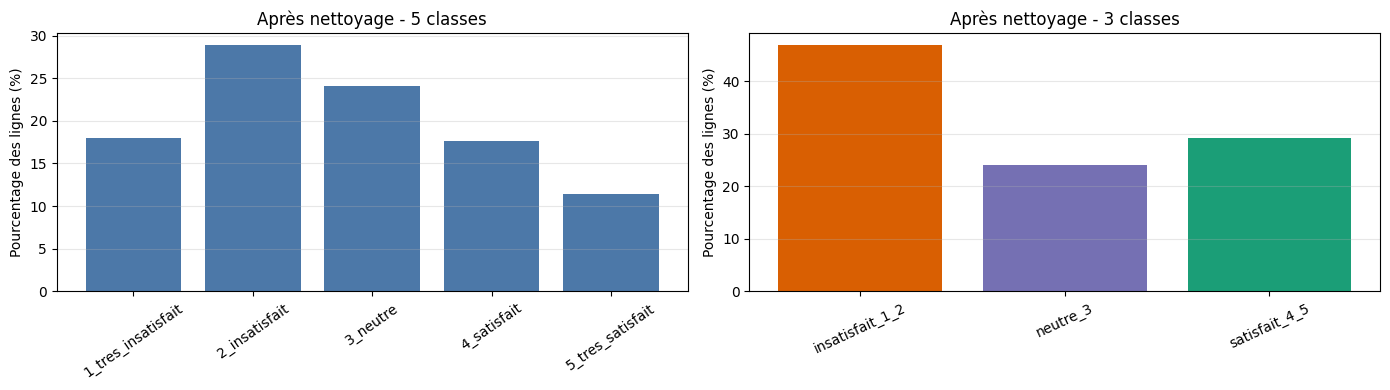

In [139]:
def satisfaction_3_classes_apres_nettoyage(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


libelles_5_classes_apres_nettoyage = {
    1: "1_tres_insatisfait",
    2: "2_insatisfait",
    3: "3_neutre",
    4: "4_satisfait",
    5: "5_tres_satisfait",
}

libelles_3_classes_apres_nettoyage = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}


def calculer_distribution_apres_nettoyage(y: pd.Series, libelles: dict[int, str], cible: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["libelle"] = distribution["classe"].map(libelles)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    distribution["cible"] = cible
    return distribution[["cible", "classe", "libelle", "nombre", "pourcentage"]]


distribution_nettoyage_5_classes = calculer_distribution_apres_nettoyage(
    df_model[TARGET_COLUMN].astype(int),
    libelles_5_classes_apres_nettoyage,
    "satisfaction_client_5_classes_apres_nettoyage",
)

distribution_nettoyage_3_classes = calculer_distribution_apres_nettoyage(
    df_model[TARGET_COLUMN].astype(int).apply(satisfaction_3_classes_apres_nettoyage),
    libelles_3_classes_apres_nettoyage,
    "satisfaction_client_3_classes_apres_nettoyage",
)

print("Équilibre des classes après nettoyage")
display(distribution_nettoyage_5_classes)
display(distribution_nettoyage_3_classes)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    distribution_nettoyage_5_classes["libelle"],
    distribution_nettoyage_5_classes["pourcentage"],
    color="#4c78a8",
)
axes[0].set_title("Après nettoyage - 5 classes")
axes[0].set_ylabel("Pourcentage des lignes (%)")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    distribution_nettoyage_3_classes["libelle"],
    distribution_nettoyage_3_classes["pourcentage"],
    color=["#d95f02", "#7570b3", "#1b9e77"],
)
axes[1].set_title("Après nettoyage - 3 classes")
axes[1].set_ylabel("Pourcentage des lignes (%)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Feature engineering


#### Pertinence metier des variables preparees

- Les nouvelles variables sont nommees de facon descriptive : `budget_par_jour`, `part_vol_budget`, `sejour_long`, `meteo_risque`, `hebergement_luxe`, `gravite_imprevu`.
- Les variables derivees renforcent la pertinence metier du dataset : elles rendent explicites des notions utiles comme le poids du vol dans le budget, le risque meteo, la duree du sejour ou le niveau de complexite operationnelle.
- Les variables post-voyage explicatives sont clairement separees des variables pre-voyage pour eviter la fuite de donnees.
- Le dataset final `df_model` est controle avant la separation train/test : dimensions, exemples de variables creees et equilibre des classes.


In [140]:

def ajouter_features_base(df_source: pd.DataFrame) -> pd.DataFrame:
    df = df_source.copy()

    safe_duree = df["duree_jours"].replace(0, np.nan)
    safe_budget = df["budget_total"].replace(0, np.nan)

    def indicateur(condition: pd.Series, missing_mask: pd.Series) -> pd.Series:
        return pd.Series(
            np.where(missing_mask, np.nan, condition.astype(int)),
            index=df.index,
        )

    df["budget_par_jour"] = df["budget_total"] / safe_duree
    df["part_vol_budget"] = df["prix_vol"] / safe_budget
    df["budget_hors_vol"] = df["budget_total"] - df["prix_vol"]
    df["sejour_long"] = indicateur(df["duree_jours"] >= 14, df["duree_jours"].isna())
    df["meteo_risque"] = indicateur(
        df["meteo_prevue"].isin(["pluie", "variable"]),
        df["meteo_prevue"].isna(),
    )
    df["client_business"] = indicateur(
        df["client_type"] == "business",
        df["client_type"].isna(),
    )
    df["hebergement_luxe"] = indicateur(
        df["type_hebergement"].isin(["resort", "villa"]),
        df["type_hebergement"].isna(),
    )

    destination_enrichment = pd.DataFrame({
        "destination": ["paris", "rome", "lisbonne", "new york", "dubai", "tokyo", "bali", "sydney"],
        "region_destination": ["europe", "europe", "europe", "amerique du nord", "moyen-orient", "asie", "asie", "oceanie"],
        "distance_vol_categorie": ["court", "court", "court", "long", "moyen", "long", "long", "long"],
        "destination_luxe": [1, 1, 0, 1, 1, 1, 1, 1],
    })

    df = df.merge(destination_enrichment, on="destination", how="left", validate="many_to_one")

    for column in ["region_destination", "distance_vol_categorie"]:
        if df[column].isna().any():
            df[column] = df[column].fillna("inconnu")

    # Variables post-voyage explicatives : utilisees uniquement dans le modele post-voyage.
    df["imprevu_present"] = indicateur(df["imprevus"] != "aucun", df["imprevus"].isna())
    df["imprevu_transport"] = indicateur(
        df["imprevus"].isin(["retard_vol", "annulation", "bagages"]),
        df["imprevus"].isna(),
    )
    df["imprevu_meteo"] = indicateur(
        df["imprevus"].isin(["météo", "meteo", "météo"]),
        df["imprevus"].isna(),
    )
    df["budget_non_respecte"] = indicateur(
        df["respect_budget"] == 0,
        df["respect_budget"].isna(),
    )
    df["gravite_imprevu"] = df["imprevus"].map({
        "aucun": 0,
        "meteo": 1,
        "météo": 1,
        "bagages": 1,
        "retard_vol": 2,
        "annulation": 3,
    })
    df["budget_tendu"] = indicateur(
        df["part_vol_budget"] >= 0.5,
        df["part_vol_budget"].isna(),
    )

    for column in ["budget_par_jour", "part_vol_budget", "budget_hors_vol"]:
        df[column] = df[column].replace([np.inf, -np.inf], np.nan)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        df[column] = df[column].mask(df[column].isna(), np.nan).astype(object)

    return df


df_model = ajouter_features_base(df_model)

features_supprimees_modelisation = [
    "budget_hors_vol",
]

df_model = df_model.drop(columns=features_supprimees_modelisation, errors="ignore")

features_base = [
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
    "destination_luxe",
]

features_post_voyage_explicatives = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
    "budget_non_respecte",
    "budget_tendu",
    "gravite_imprevu",
]

print("Dimensions apres feature engineering :", df_model.shape)
display(df_model[features_base + [TARGET_COLUMN]].head())
print(f"Valeurs manquantes avant pipeline : {int(df_model.isna().sum().sum())}")




Dimensions apres feature engineering : (1399, 30)


,budget_par_jour,part_vol_budget,sejour_long,meteo_risque,client_business,hebergement_luxe,destination_luxe,satisfaction_client
0,1849.633333,0.238024,0.0,0.0,0.0,0.0,NaN,3
1,274.022500,0.463493,0.0,1.0,1.0,0.0,1.0,4
2,834.198750,0.066077,1.0,0.0,0.0,1.0,1.0,5
3,414.671765,0.119781,1.0,0.0,0.0,0.0,1.0,3
4,1087.560000,0.142027,0.0,1.0,0.0,0.0,1.0,2


Valeurs manquantes avant pipeline : 607



### 8.1 Features gardées après simplification

Après simplification du feature engineering, les variables conservées sont les suivantes.

#### Variables pré-voyage brutes

- `client_type`
- `budget_total`
- `destination`
- `saison`
- `duree_jours`
- `type_hebergement`
- `prix_vol`
- `meteo_prevue`
- `activite_principale`

#### Variables pré-voyage dérivées conservées

- `budget_par_jour`
- `part_vol_budget`
- `sejour_long`
- `meteo_risque`
- `client_business`
- `hebergement_luxe`
- `region_destination`
- `distance_vol_categorie`
- `destination_luxe`

#### Variables post-voyage conservées uniquement pour le modèle post-voyage

- `imprevus`
- `reorganisation_necessaire`
- `respect_budget`
- `imprevu_present`
- `imprevu_transport`
- `imprevu_meteo`
- `budget_non_respecte`
- `budget_tendu`
- `gravite_imprevu`

Les features supprimées ne sont plus créées dans `ajouter_features_base` : `randonnee_meteo_risque`, `saison_haute`, `cout_vie_destination`, `type_destination`, `decalage_horaire_categorie`, `risque_meteo_destination`, `annulation_et_reorganisation`, `retard_et_budget_non_respecte`, `imprevu_transport_et_sejour_court` et `budget_tendu_et_hebergement_luxe`.


### 8.1 Équilibre des classes du dataset final de modélisation

Cette vérification est réalisée sur `df_model`, c'est-à-dire le dataset final après nettoyage, traitement des incohérences et feature engineering. Elle permet de contrôler la distribution de la cible avant toute séparation train/test.

Deux lectures sont utiles :

- la distribution originale de `satisfaction_client` sur les 5 notes `1` à `5`, conservée pour analyse descriptive ;
- la distribution regroupée en 3 classes, utilisée pour les modèles pré-voyage et post-voyage.


Distribution de la cible sur le dataset final df_model


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_5_classes,1,1_tres_insatisfait,251,17.94
1,satisfaction_client_5_classes,2,2_insatisfait,404,28.88
2,satisfaction_client_5_classes,3,3_neutre,337,24.09
3,satisfaction_client_5_classes,4,4_satisfait,247,17.66
4,satisfaction_client_5_classes,5,5_tres_satisfait,160,11.44


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_3_classes,0,insatisfait_1_2,655,46.82
1,satisfaction_client_3_classes,1,neutre_3,337,24.09
2,satisfaction_client_3_classes,2,satisfait_4_5,407,29.09


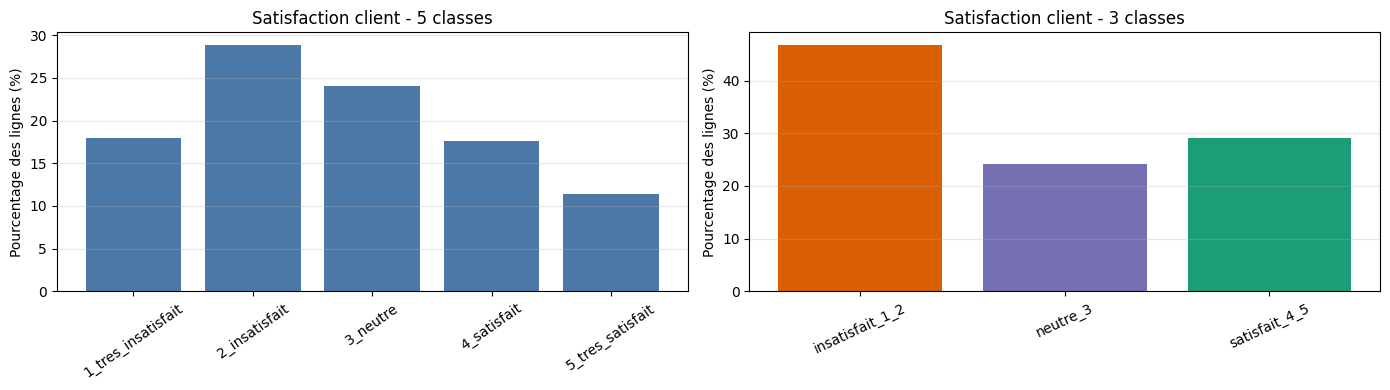

In [141]:
def regrouper_satisfaction_3_classes(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


libelles_satisfaction_5 = {
    1: "1_tres_insatisfait",
    2: "2_insatisfait",
    3: "3_neutre",
    4: "4_satisfait",
    5: "5_tres_satisfait",
}

libelles_satisfaction_3 = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}


def distribution_classes(y: pd.Series, libelles: dict[int, str], nom_cible: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["libelle"] = distribution["classe"].map(libelles)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    distribution["cible"] = nom_cible
    return distribution[["cible", "classe", "libelle", "nombre", "pourcentage"]]


distribution_satisfaction_5 = distribution_classes(
    df_model[TARGET_COLUMN].astype(int),
    libelles_satisfaction_5,
    "satisfaction_client_5_classes",
)

distribution_satisfaction_3 = distribution_classes(
    df_model[TARGET_COLUMN].astype(int).apply(regrouper_satisfaction_3_classes),
    libelles_satisfaction_3,
    "satisfaction_client_3_classes",
)

print("Distribution de la cible sur le dataset final df_model")
display(distribution_satisfaction_5)
display(distribution_satisfaction_3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    distribution_satisfaction_5["libelle"],
    distribution_satisfaction_5["pourcentage"],
    color="#4c78a8",
)
axes[0].set_title("Satisfaction client - 5 classes")
axes[0].set_ylabel("Pourcentage des lignes (%)")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    distribution_satisfaction_3["libelle"],
    distribution_satisfaction_3["pourcentage"],
    color=["#d95f02", "#7570b3", "#1b9e77"],
)
axes[1].set_title("Satisfaction client - 3 classes")
axes[1].set_ylabel("Pourcentage des lignes (%)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



### 8.2 Stockage, cycle de vie et gouvernance du dataset

Cette section complete la preparation des donnees avec les choix de stockage, le cycle de vie du dataset et les validations attendues par les parties prenantes.

#### Choix du modele de stockage

| Element | Choix retenu | Justification |
| --- | --- | --- |
| Dataset brut | Fichier CSV dans `data/` | Format simple, lisible, adapte a un dataset tabulaire de faible volume |
| Dataset prepare | `df_model` reconstruit dans le notebook | Evite de multiplier les fichiers derives ; garantit la reproductibilite des transformations metier |
| Pretraitements statistiques | Pipeline `scikit-learn` | Imputation, outliers IQR, standardisation et encodage sont appris sur le train uniquement |
| Experimentations | Notebook final + MLflow local | Le notebook documente la logique ; MLflow trace les runs, parametres et metriques |
| Artefacts lourds | Non versionnes dans Git | `mlflow.db`, `mlruns/`, `mlartifacts/`, `logs/` sont exclus du depot pour eviter d'alourdir Git |
| Deploiement futur | A definir apres validation du notebook final | Un stockage versionne des donnees preparees et un registre de modeles seraient necessaires en production |

Le choix du CSV local est coherent pour le prototype actuel. Il serait insuffisant pour une exploitation multi-utilisateurs, automatisee ou connectee a des donnees clients reelles.

#### Cycle de vie du dataset dans ce projet

| Etape | Objet produit | Verification realisee |
| --- | --- | --- |
| 1. Donnees brutes | `data/Examen_travel_planning_dataset.csv` | Existence, chargement, dimensions, types, valeurs manquantes, doublons, incoherences metier |
| 2. Nettoyage metier | `df_model` apres `nettoyer_dataset(df_raw)` | Cible valide 1-5, suppression des incoherences fortes : budget impossible et reorganisation sans imprevu declare |
| 3. Controle apres nettoyage | Distributions de classes apres nettoyage | Verification de l'equilibre de la cible avant feature engineering |
| 4. Feature engineering | Variables derivees ajoutees a `df_model` | Creation de variables metier utiles et suppression des features non retenues |
| 5. Train/test split | `X_train`, `X_test`, `y_train`, `y_test` | Separation stratifiee avant tout apprentissage statistique de pretraitement |
| 6. Pipeline de pretraitement | `ColumnTransformer` dans `Pipeline` | Imputation, traitement IQR, normalisation, encodage appris sur train puis appliques au test |
| 7. Modelisation | `X_pre`, `X_post`, `y_pre`, `y_post` | Separation des variables selon les usages pre-voyage et post-voyage, sur le meme dataset nettoye `df_model` |
| 8. Tracabilite | Notebook + MLflow | Documentation des choix, metriques et limites |


#### Versioning des donnees

Le dataset est versionne pour garantir la reproductibilite et permettre un retour arriere en cas de degradation des resultats. La strategie retenue est adaptee au volume actuel : fichiers CSV versionnes dans Git, avec un manifeste technique contenant les transformations et les empreintes SHA-256.

| Version | Role | Emplacement |
| --- | --- | --- |
| `v1.0` | Dataset brut fourni | `data/versions/v1_0_raw/travel_planning_dataset_v1_0.csv` |
| `v1.1` | Nettoyage des colonnes, espaces et formats | `data/versions/v1_1_cleaning/travel_planning_dataset_v1_1.csv` |
| `v1.2` | Suppression des incoherences critiques | `data/versions/v1_2_incoherences/travel_planning_dataset_v1_2.csv` |
| `v2.0` | Feature engineering | `data/versions/v2_0_feature_engineering/travel_planning_dataset_v2_0.csv` |
| `v2.1` | Enrichissement eventuel ou nouvelles donnees | `data/versions/v2_1_enrichment/README.md` |

Le script `scripts/version_data.py` permet de regenerer ces versions. Le fichier `data/versions/manifest.json` trace le nombre de lignes, colonnes, transformations et empreintes des fichiers. La documentation detaillee se trouve dans `docs/data_versioning.md`.

#### Conclusion

La preparation des donnees est couverte dans le perimetre du projet : le dataset est nettoye, structure, controle et prepare en fonction des deux cas d'usage identifies. Les operations statistiques sensibles sont integrees au pipeline afin d'eviter la fuite de donnees entre train et test. La validation effective par des parties prenantes externes reste une action a realiser hors notebook si le projet passe en contexte operationnel.


### 8.3 Segmentation client par clustering pre-voyage

Le clustering est ajoute comme analyse exploratoire non supervisee. Il ne sert pas directement a predire la satisfaction, mais a identifier des profils de voyages similaires avant le depart.

Objectif metier :

- regrouper les sejours selon des caracteristiques connues avant le voyage ;
- mieux comprendre les profils clients et les offres associees ;
- analyser ensuite si certains segments presentent plus de risque d'insatisfaction ;
- aider l'agence a personnaliser les recommandations, les controles qualite et les actions commerciales.

Point methodologique important : les variables post-voyage (`imprevus`, `respect_budget`, `reorganisation_necessaire`, `retour_client`) et la cible (`satisfaction_client`) ne sont pas utilisees pour creer les clusters. Elles peuvent seulement etre consultees apres coup pour decrire les segments.


Nombre de clusters retenu : 5


,k,silhouette
0,2,0.1276
1,3,0.1193
2,4,0.1323
3,5,0.1328
4,6,0.1086


,segment_client,nb_sejours,budget_moyen,duree_moyenne,prix_vol_moyen,part_vol_budget_moyenne,satisfaction_moyenne,taux_budget_respecte,taux_reorganisation,part_lignes_pct,client_type_majoritaire,destination_majoritaire,saison_majoritaire,hebergement_majoritaire,activite_majoritaire,libelle_segment_metier
0,0,558,6782.071,9.124,1154.272,0.218,2.781,0.737,0.554,39.89,solo,new york,automne,villa,culture,profil_premium_loisir
1,1,247,5024.954,6.571,1124.453,0.320,2.684,0.733,0.571,17.66,business,new york,été,appartement,business,profil_business
2,2,332,9543.404,16.810,1131.017,0.152,2.807,0.642,0.560,23.73,senior,new york,automne,villa,culture,profil_premium_loisir
3,3,58,14656.873,4.517,1048.731,0.087,2.741,0.966,0.362,4.15,solo,rome,printemps,villa,culture,profil_premium_loisir
4,4,204,6567.841,10.446,988.224,0.207,2.706,0.662,0.569,14.58,couple,lisbonne,printemps,villa,plage,profil_premium_loisir


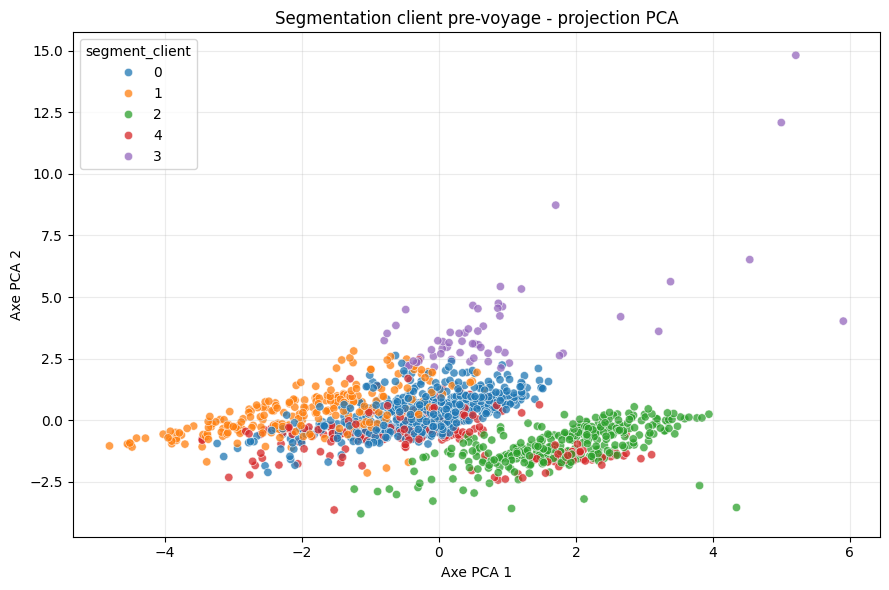

In [142]:
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import seaborn as sns

# Variables pre-voyage uniquement : connues avant la realisation du sejour.
features_clustering_pre_voyage = [
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
    "region_destination",
    "distance_vol_categorie",
    "destination_luxe",
]
features_clustering_pre_voyage = [
    col for col in features_clustering_pre_voyage if col in df_model.columns
]

X_clustering = df_model[features_clustering_pre_voyage].copy()

colonnes_numeriques_clustering = X_clustering.select_dtypes(include=[np.number]).columns.tolist()
colonnes_categorielles_clustering = [
    col for col in X_clustering.columns if col not in colonnes_numeriques_clustering
]

preprocesseur_clustering = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            colonnes_numeriques_clustering,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            colonnes_categorielles_clustering,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

X_clustering_prepare = preprocesseur_clustering.fit_transform(X_clustering)
X_clustering_prepare = np.asarray(X_clustering_prepare, dtype=float)

# Choix exploratoire du nombre de clusters avec le score de silhouette.
scores_silhouette = []
for k in range(2, 7):
    modele_kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = modele_kmeans.fit_predict(X_clustering_prepare)
    scores_silhouette.append({
        "k": k,
        "silhouette": silhouette_score(X_clustering_prepare, labels),
    })

silhouette_clustering = pd.DataFrame(scores_silhouette)
k_retenu = int(
    silhouette_clustering.sort_values("silhouette", ascending=False).iloc[0]["k"]
)

modele_segmentation_client = KMeans(
    n_clusters=k_retenu,
    random_state=RANDOM_STATE,
    n_init=10,
)
segments_client = modele_segmentation_client.fit_predict(X_clustering_prepare)

df_segments = df_model.copy()
df_segments["segment_client"] = segments_client.astype(int)

count_column = "trip_id" if "trip_id" in df_segments.columns else "budget_total"
aggregations_segments = {
    "nb_sejours": (count_column, "count"),
    "budget_moyen": ("budget_total", "mean"),
    "duree_moyenne": ("duree_jours", "mean"),
    "prix_vol_moyen": ("prix_vol", "mean"),
    "part_vol_budget_moyenne": ("part_vol_budget", "mean"),
}

# Variables post-voyage utilisees uniquement pour lire les segments apres creation.
if TARGET_COLUMN in df_segments.columns:
    aggregations_segments["satisfaction_moyenne"] = (TARGET_COLUMN, "mean")
if "respect_budget" in df_segments.columns:
    aggregations_segments["taux_budget_respecte"] = ("respect_budget", "mean")
if "reorganisation_necessaire" in df_segments.columns:
    aggregations_segments["taux_reorganisation"] = ("reorganisation_necessaire", "mean")

profil_segments = (
    df_segments
    .groupby("segment_client")
    .agg(**aggregations_segments)
    .reset_index()
)
profil_segments["part_lignes_pct"] = (
    profil_segments["nb_sejours"] / len(df_segments) * 100
).round(2)

def mode_safe(series: pd.Series):
    values = series.dropna()
    if values.empty:
        return "non_disponible"
    return values.mode().iloc[0]

variables_categorielles_description = [
    "client_type",
    "destination",
    "saison",
    "type_hebergement",
    "activite_principale",
]
variables_categorielles_description = [
    col for col in variables_categorielles_description if col in df_segments.columns
]

profil_categoriel_segments = (
    df_segments
    .groupby("segment_client")[variables_categorielles_description]
    .agg(mode_safe)
    .reset_index()
)
profil_categoriel_segments = profil_categoriel_segments.rename(columns={
    "client_type": "client_type_majoritaire",
    "destination": "destination_majoritaire",
    "saison": "saison_majoritaire",
    "type_hebergement": "hebergement_majoritaire",
    "activite_principale": "activite_majoritaire",
})

profil_segments = profil_segments.merge(
    profil_categoriel_segments,
    on="segment_client",
    how="left",
)

def proposer_libelle_segment(row: pd.Series) -> str:
    if row.get("client_type_majoritaire") == "business":
        return "profil_business"
    if row.get("hebergement_majoritaire") in ["resort", "villa"]:
        return "profil_premium_loisir"
    if row.get("duree_moyenne", 0) >= df_segments["duree_jours"].median():
        return "profil_sejour_long"
    return "profil_standard"

profil_segments["libelle_segment_metier"] = profil_segments.apply(
    proposer_libelle_segment,
    axis=1,
)

print(f"Nombre de clusters retenu : {k_retenu}")
display(silhouette_clustering.round(4))
display(profil_segments.round(3))

# Projection 2D pour visualiser les segments.
pca_segments = PCA(n_components=2, random_state=RANDOM_STATE)
projection_segments = pca_segments.fit_transform(X_clustering_prepare)
projection_segments = pd.DataFrame({
    "axe_1": projection_segments[:, 0],
    "axe_2": projection_segments[:, 1],
    "segment_client": df_segments["segment_client"].astype(str),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=projection_segments,
    x="axe_1",
    y="axe_2",
    hue="segment_client",
    palette="tab10",
    alpha=0.75,
)
plt.title("Segmentation client pre-voyage - projection PCA")
plt.xlabel("Axe PCA 1")
plt.ylabel("Axe PCA 2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


#### Interpretation metier de la segmentation

La segmentation obtenue doit etre lue comme un outil d'aide a la comprehension des profils, pas comme une prediction finale.

Utilisations possibles dans le projet :

- personnaliser les recommandations de destinations et d'hebergements par profil ;
- identifier les segments qui demandent plus d'accompagnement avant depart ;
- comparer la satisfaction moyenne et les incidents constates apres voyage selon les profils ;
- construire un reporting metier lisible pour l'agence de voyages ;
- tester plus tard `segment_client` comme variable additionnelle du modele pre-voyage, uniquement si les segments sont stables et valides metier.

Limites :

- le clustering depend fortement des variables disponibles et de leur qualite ;
- les libelles metier proposes doivent etre valides par les acteurs metier ;
- la segmentation ne doit pas conduire a exclure automatiquement certains clients d'une offre ou d'un service.


## C4-C5. Modelisation : choix, entrainement et validation



In [143]:

class IQRMedianOutlierReplacer(BaseEstimator, TransformerMixin):
    """Remplace les outliers IQR par la mediane apprise sur le train."""

    def __init__(self, factor: float = 1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_array = np.asarray(X, dtype=float)
        self.q1_ = np.nanquantile(X_array, 0.25, axis=0)
        self.q3_ = np.nanquantile(X_array, 0.75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_bounds_ = self.q1_ - self.factor * self.iqr_
        self.upper_bounds_ = self.q3_ + self.factor * self.iqr_
        self.medians_ = np.nanmedian(X_array, axis=0)
        return self

    def transform(self, X):
        X_array = np.asarray(X, dtype=float).copy()
        outlier_mask = (
            (X_array < self.lower_bounds_)
            | (X_array > self.upper_bounds_)
        )
        return np.where(outlier_mask, self.medians_, X_array)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray([f"x{i}" for i in range(len(self.medians_))], dtype=object)
        return np.asarray(input_features, dtype=object)


def est_hashable(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def contient_valeur_non_hashable(serie: pd.Series) -> bool:
    valeurs = serie.dropna().head(1000)
    return valeurs.map(lambda valeur: not est_hashable(valeur)).any()


def detecter_variables_binaires(X: pd.DataFrame, numeric_features: list[str]) -> list[str]:
    binary_features = []
    for column in numeric_features:
        if contient_valeur_non_hashable(X[column]):
            continue
        try:
            values = pd.Series(X[column].dropna().unique())
            unique_values = set(values.astype(float).tolist())
        except (TypeError, ValueError):
            continue
        if values.empty:
            continue
        if unique_values.issubset({0.0, 1.0}):
            binary_features.append(column)
    return binary_features


def construire_preprocesseur(X: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    non_hashable_features = [
        column for column in X.columns
        if contient_valeur_non_hashable(X[column])
    ]
    if non_hashable_features:
        print("Colonnes ignorees par le preprocesseur car elles contiennent des listes/dictionnaires :", non_hashable_features)

    X_compatible = X.drop(columns=non_hashable_features, errors="ignore")

    numeric_features = X_compatible.select_dtypes(include="number").columns.tolist()
    categorical_features = X_compatible.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    binary_numeric_features = detecter_variables_binaires(X_compatible, numeric_features)
    continuous_numeric_features = [
        column for column in numeric_features
        if column not in binary_numeric_features
    ]

    continuous_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("outliers_iqr", IQRMedianOutlierReplacer()),
        ("scaler", StandardScaler()),
    ])

    binary_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformers = []
    if continuous_numeric_features:
        transformers.append(("num_cont", continuous_numeric_transformer, continuous_numeric_features))
    if binary_numeric_features:
        transformers.append(("num_bin", binary_numeric_transformer, binary_numeric_features))
    if categorical_features:
        transformers.append(("cat", categorical_transformer, categorical_features))

    preprocess = ColumnTransformer(transformers=transformers)

    return preprocess, numeric_features, categorical_features


def evaluer_classification(modeles: dict, X_train, X_test, y_train, y_test, preprocess) -> tuple[pd.DataFrame, dict]:
    rows = []
    fitted = {}

    for model_name, model in modeles.items():
        pipeline = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", model),
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        rows.append({
            "modele": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
        })
        fitted[model_name] = pipeline

    results = (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    return results, fitted


def afficher_distribution(y: pd.Series, label: str) -> None:
    print(label)
    display(
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
        .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
    )


Données brutes
       ↓
Imputation
       ↓
Traitement outliers
       ↓
Standardisation
       ↓
OneHotEncoder
       ↓
Random Forest
       ↓
Prédiction


### C4-C5.1 Modele pre-voyage

Objectif : prédire la satisfaction avant le départ à partir des informations disponibles au moment de la planification.

La cible est désormais regroupée en 3 classes, comme pour le modèle post-voyage :

- `0 = insatisfait` pour les notes 1 et 2 ;
- `1 = neutre` pour la note 3 ;
- `2 = satisfait` pour les notes 4 et 5.

Règle clé : les variables post-voyage sont exclues pour éviter la fuite de données.



In [144]:
post_trip_columns = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "retour_client",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
    "budget_non_respecte",
    "budget_tendu",
    "gravite_imprevu",
]

technical_columns = ["trip_id"]
excluded_pre_voyage = [TARGET_COLUMN, *technical_columns, *post_trip_columns]
feature_columns_pre = [
    column for column in df_model.columns
    if column not in excluded_pre_voyage
]

# Securite : certaines cellules exploratoires NLP peuvent produire des colonnes
# contenant des listes. Ces colonnes ne sont pas compatibles avec OneHotEncoder,
# groupby ou unique, car une liste n'est pas hashable.
def est_hashable(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def contient_valeur_non_hashable(serie: pd.Series) -> bool:
    valeurs = serie.dropna().head(1000)
    return valeurs.map(lambda valeur: not est_hashable(valeur)).any()

colonnes_non_hashables_pre = [
    column for column in feature_columns_pre
    if contient_valeur_non_hashable(df_model[column])
]

if colonnes_non_hashables_pre:
    print("Colonnes exclues car non compatibles avec l'encodage :", colonnes_non_hashables_pre)

feature_columns_pre = [
    column for column in feature_columns_pre
    if column not in colonnes_non_hashables_pre
]

X_pre = df_model[feature_columns_pre].copy()
y_pre = df_model[TARGET_COLUMN].apply(regrouper_satisfaction_3_classes).astype(int).copy()

preprocess_pre, numeric_pre, categorical_pre = construire_preprocesseur(X_pre)

resume_pre = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_pre), len(categorical_pre), X_pre.shape[1], len(excluded_pre_voyage)],
    "colonnes": [numeric_pre, categorical_pre, feature_columns_pre, excluded_pre_voyage],
})

display(resume_pre)
afficher_distribution(y_pre, "Distribution cible pré-voyage à 3 classes")


,famille,nombre,colonnes
0,numeriques,10,"[budget_total, duree_jours, prix_vol, budget_p..."
1,categorielles,8,"[client_type, destination, saison, type_heberg..."
2,total,18,"[client_type, budget_total, destination, saiso..."
3,exclues,12,"[satisfaction_client, trip_id, imprevus, reorg..."


Distribution cible pré-voyage à 3 classes


,classe,nombre,pourcentage
0,0,655,46.82
1,1,337,24.09
2,2,407,29.09


### 10.1 Corrélations pré-voyage


In [145]:
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre,
)

correlation_df_pre = X_train_pre[numeric_pre].copy()
correlation_df_pre["satisfaction_3_classes"] = y_train_pre.values

spearman_pre = (
    correlation_df_pre.corr(method="spearman")["satisfaction_3_classes"]
    .drop("satisfaction_3_classes")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(spearman_pre.to_frame("correlation_spearman_satisfaction_3_classes").round(4).head(15))


,correlation_spearman_satisfaction_3_classes
part_vol_budget,-0.0643
budget_total,0.0632
budget_par_jour,0.0597
destination_luxe,0.0499
hebergement_luxe,0.0476
sejour_long,-0.0276
client_business,-0.0267
meteo_risque,0.0233
duree_jours,0.0088
prix_vol,0.0038


### 10.2 Comparaison des modèles pré-voyage


In [146]:
modeles_pre = {
    "Dummy_majority_pre": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_pre": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_pre": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees_pre": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_pre, fitted_pre = evaluer_classification(
    modeles_pre,
    X_train_pre,
    X_test_pre,
    y_train_pre,
    y_test_pre,
    preprocess_pre,
)

display(results_pre.round(4))
best_pre_model_name = results_pre.iloc[0]["modele"]
print("Meilleur modèle pré-voyage :", best_pre_model_name)

,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression_pre,0.3571,0.3554,0.3491
1,RandomForest_pre,0.4000,0.3358,0.3255
2,ExtraTrees_pre,0.3750,0.3274,0.3248
3,Dummy_majority_pre,0.4679,0.3333,0.2125


Meilleur modèle pré-voyage : LogisticRegression_pre


### 10.2.1 Tests independants hyperparametres pre-voyage

Cellules de brouillon pour tester une amelioration du modele pre-voyage.
Aucun export, aucune modification de `train.py`, aucune industrialisation.


In [147]:
# Diagnostic cibl? : identifier les colonnes contenant des objets non hashables.
# Une liste Python ne peut pas servir directement de cat?gorie dans pandas/sklearn.

def diagnostic_non_hashable_dataframe(df_source: pd.DataFrame, nom_dataframe: str) -> pd.DataFrame:
    lignes = []
    for column in df_source.columns:
        exemples = []
        nb = 0
        for value in df_source[column].dropna().head(5000):
            try:
                hash(value)
            except TypeError:
                nb += 1
                if len(exemples) < 3:
                    exemples.append(repr(value)[:200])
        if nb > 0:
            lignes.append({
                "dataframe": nom_dataframe,
                "colonne": column,
                "type_colonne": str(df_source[column].dtype),
                "nb_exemples_non_hashables_detectes": nb,
                "exemples": exemples,
            })
    return pd.DataFrame(lignes)

frames_a_controler = []
for nom in ["df_model", "df_nlp", "X_pre", "X_train_pre", "X_test_pre"]:
    if nom in globals():
        frames_a_controler.append(diagnostic_non_hashable_dataframe(globals()[nom], nom))

diagnostic_non_hashable_pre = pd.concat(frames_a_controler, ignore_index=True) if frames_a_controler else pd.DataFrame()

if diagnostic_non_hashable_pre.empty:
    print("Aucune valeur non hashable detectee dans les dataframes controles.")
else:
    display(diagnostic_non_hashable_pre)


,dataframe,colonne,type_colonne,nb_exemples_non_hashables_detectes,exemples
0,df_nlp,tokens,object,1399,"[['séjour', 'mitigé', '.'], ['excellent', 'séj..."
1,df_nlp,mots_utiles,object,1399,"[['séjour', 'mitigé'], ['excellent', 'séjour']..."
2,df_nlp,mots_cles,object,1399,"[['mitigé'], [], []]"
3,df_nlp,entites,object,1399,"[[], [], []]"


In [148]:
import json
VERSION_TEST_HYPERPARAMS_PRE = "2026-06-22-whitelist-features-v2"
print("Version cellule optimisation pre-voyage :", VERSION_TEST_HYPERPARAMS_PRE)

from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Tests independants uniquement : ne pas exporter ce modele et ne pas modifier train.py.
N_ITER_OPTIMISATION_PRE = 30
CV_OPTIMISATION_PRE = 5
N_JOBS_OPTIMISATION_PRE = 1

scorer_macro_f1_pre = make_scorer(f1_score, average="macro", zero_division=0)
cv_optimisation_pre = StratifiedKFold(
    n_splits=CV_OPTIMISATION_PRE,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Securite locale pour ce notebook de test : on ne garde que les variables
# pre-voyage tabulaires autorisees. Les colonnes NLP de type list sont donc exclues.
colonnes_pre_autorisees_optimisation = [
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
    "region_destination",
    "distance_vol_categorie",
    "destination_luxe",
]
colonnes_pre_autorisees_optimisation = [
    column for column in colonnes_pre_autorisees_optimisation
    if column in X_train_pre.columns
]

colonnes_exclues_optimisation = sorted(
    set(X_train_pre.columns) - set(colonnes_pre_autorisees_optimisation)
)
print("Colonnes utilisees pour l optimisation pre-voyage :", colonnes_pre_autorisees_optimisation)
print("Colonnes exclues de l optimisation pre-voyage :", colonnes_exclues_optimisation)

X_train_pre_opt = X_train_pre[colonnes_pre_autorisees_optimisation].copy()
X_test_pre_opt = X_test_pre[colonnes_pre_autorisees_optimisation].copy()

# Derniere securite : si une valeur non hashable se trouve quand meme dans les colonnes autorisees,
# on la convertit en texte avant OneHotEncoder.
def valeur_est_hashable_pre_opt(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def convertir_valeur_hashable_pre_opt(valeur):
    if valeur is pd.NA:
        return np.nan
    if isinstance(valeur, (list, tuple, set, dict)):
        try:
            return json.dumps(valeur, ensure_ascii=False, sort_keys=True, default=str)
        except TypeError:
            return str(valeur)
    if valeur_est_hashable_pre_opt(valeur):
        return valeur
    return str(valeur)


def convertir_dataframe_hashable_pre_opt(df_source: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    df_safe = df_source.copy()
    colonnes_converties = []
    for column in df_safe.columns:
        masque_non_hashable = df_safe[column].map(
            lambda valeur: False if valeur is None else not valeur_est_hashable_pre_opt(valeur)
        )
        if masque_non_hashable.any():
            colonnes_converties.append(column)
            df_safe[column] = df_safe[column].map(convertir_valeur_hashable_pre_opt)
    return df_safe, colonnes_converties


X_train_pre_opt, colonnes_converties_train_pre = convertir_dataframe_hashable_pre_opt(X_train_pre_opt)
X_test_pre_opt, colonnes_converties_test_pre = convertir_dataframe_hashable_pre_opt(X_test_pre_opt)
colonnes_converties_opt_pre = sorted(
    set(colonnes_converties_train_pre) | set(colonnes_converties_test_pre)
)

if colonnes_converties_opt_pre:
    print("Colonnes converties en texte pour les tests d optimisation :", colonnes_converties_opt_pre)
else:
    print("Aucune valeur non hashable dans les colonnes autorisees.")


def construire_pipeline_test_pre(estimator):
    preprocess, _, _ = construire_preprocesseur(X_train_pre_opt)
    return Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", estimator),
    ])


configs_optimisation_pre = [
    {
        "nom": "LogisticRegression_pre_randomsearch",
        "pipeline": construire_pipeline_test_pre(
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        ),
        "params": {
            "model__C": loguniform(1e-3, 100),
            "model__class_weight": [None, "balanced"],
            "model__solver": ["lbfgs"],
            "model__penalty": ["l2"],
        },
    },
    {
        "nom": "RandomForest_pre_randomsearch",
        "pipeline": construire_pipeline_test_pre(
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
        ),
        "params": {
            "model__n_estimators": randint(100, 700),
            "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
            "model__min_samples_split": randint(2, 80),
            "model__min_samples_leaf": randint(1, 50),
            "model__max_features": ["sqrt", "log2", 0.5, None],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        },
    },
    {
        "nom": "ExtraTrees_pre_randomsearch",
        "pipeline": construire_pipeline_test_pre(
            ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=1)
        ),
        "params": {
            "model__n_estimators": randint(100, 700),
            "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
            "model__min_samples_split": randint(2, 80),
            "model__min_samples_leaf": randint(1, 50),
            "model__max_features": ["sqrt", "log2", 0.5, None],
            "model__class_weight": [None, "balanced"],
        },
    },
]

try:
    from xgboost import XGBClassifier

    configs_optimisation_pre.append({
        "nom": "XGBoost_pre_randomsearch",
        "pipeline": construire_pipeline_test_pre(
            XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=1,
                tree_method="hist",
            )
        ),
        "params": {
            "model__n_estimators": randint(100, 600),
            "model__max_depth": randint(2, 8),
            "model__learning_rate": loguniform(0.01, 0.2),
            "model__subsample": uniform(0.6, 0.4),
            "model__colsample_bytree": uniform(0.6, 0.4),
            "model__min_child_weight": randint(1, 10),
            "model__reg_lambda": loguniform(0.1, 10),
        },
    })
except Exception as error:
    print(f"XGBoost non disponible, test ignore : {error}")

resultats_optimisation_pre_rows = []
fitted_optimisation_pre = {}

for config in configs_optimisation_pre:
    print(f"\nOptimisation : {config['nom']}")
    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=N_ITER_OPTIMISATION_PRE,
        scoring=scorer_macro_f1_pre,
        cv=cv_optimisation_pre,
        n_jobs=N_JOBS_OPTIMISATION_PRE,
        random_state=RANDOM_STATE,
        refit=True,
        return_train_score=True,
        verbose=1,
        error_score="raise",
    )
    search.fit(X_train_pre_opt, y_train_pre)

    y_pred_test = search.predict(X_test_pre_opt)
    y_pred_train = search.predict(X_train_pre_opt)
    best_index = search.best_index_

    row = {
        "modele": config["nom"],
        "best_cv_macro_f1": search.best_score_,
        "best_cv_train_macro_f1": search.cv_results_["mean_train_score"][best_index],
        "accuracy_test": accuracy_score(y_test_pre, y_pred_test),
        "balanced_accuracy_test": balanced_accuracy_score(y_test_pre, y_pred_test),
        "macro_f1_test": f1_score(y_test_pre, y_pred_test, average="macro", zero_division=0),
        "macro_f1_train": f1_score(y_train_pre, y_pred_train, average="macro", zero_division=0),
        "best_params": search.best_params_,
    }
    row["ecart_macro_f1_train_test"] = row["macro_f1_train"] - row["macro_f1_test"]
    resultats_optimisation_pre_rows.append(row)
    fitted_optimisation_pre[config["nom"]] = search

resultats_optimisation_pre = (
    pd.DataFrame(resultats_optimisation_pre_rows)
    .sort_values("macro_f1_test", ascending=False)
    .reset_index(drop=True)
)

display(resultats_optimisation_pre.drop(columns=["best_params"]).round(4))

comparaison_pre_optimisation = pd.concat([
    results_pre[["modele", "accuracy", "balanced_accuracy", "macro_f1"]].assign(
        experience="baseline_pre"
    ),
    resultats_optimisation_pre.rename(columns={
        "accuracy_test": "accuracy",
        "balanced_accuracy_test": "balanced_accuracy",
        "macro_f1_test": "macro_f1",
    })[["modele", "accuracy", "balanced_accuracy", "macro_f1"]].assign(
        experience="optimisation_pre"
    ),
], ignore_index=True).sort_values("macro_f1", ascending=False)

display(comparaison_pre_optimisation.round(4))

print("Meilleur test optimise :", resultats_optimisation_pre.iloc[0]["modele"])
print("Parametres retenus :")
print(resultats_optimisation_pre.iloc[0]["best_params"])


Version cellule optimisation pre-voyage : 2026-06-22-whitelist-features-v2
Colonnes utilisees pour l optimisation pre-voyage : ['client_type', 'budget_total', 'destination', 'saison', 'duree_jours', 'type_hebergement', 'prix_vol', 'meteo_prevue', 'activite_principale', 'budget_par_jour', 'part_vol_budget', 'sejour_long', 'meteo_risque', 'client_business', 'hebergement_luxe', 'region_destination', 'distance_vol_categorie', 'destination_luxe']
Colonnes exclues de l optimisation pre-voyage : []
Aucune valeur non hashable dans les colonnes autorisees.

Optimisation : LogisticRegression_pre_randomsearch
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Optimisation : RandomForest_pre_randomsearch
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Optimisation : ExtraTrees_pre_randomsearch
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Optimisation : XGBoost_pre_randomsearch
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,modele,best_cv_macro_f1,best_cv_train_macro_f1,accuracy_test,balanced_accuracy_test,macro_f1_test,macro_f1_train,ecart_macro_f1_train_test
0,ExtraTrees_pre_randomsearch,0.3327,0.6861,0.3893,0.3713,0.3694,0.6803,0.3109
1,LogisticRegression_pre_randomsearch,0.3332,0.4229,0.3536,0.3440,0.3413,0.4163,0.0751
2,RandomForest_pre_randomsearch,0.3364,0.5862,0.3429,0.3415,0.3362,0.5847,0.2486
3,XGBoost_pre_randomsearch,0.3362,1.0000,0.3893,0.3336,0.3277,1.0000,0.6723


,modele,accuracy,balanced_accuracy,macro_f1,experience
4,ExtraTrees_pre_randomsearch,0.3893,0.3713,0.3694,optimisation_pre
0,LogisticRegression_pre,0.3571,0.3554,0.3491,baseline_pre
5,LogisticRegression_pre_randomsearch,0.3536,0.3440,0.3413,optimisation_pre
6,RandomForest_pre_randomsearch,0.3429,0.3415,0.3362,optimisation_pre
7,XGBoost_pre_randomsearch,0.3893,0.3336,0.3277,optimisation_pre
1,RandomForest_pre,0.4000,0.3358,0.3255,baseline_pre
2,ExtraTrees_pre,0.3750,0.3274,0.3248,baseline_pre
3,Dummy_majority_pre,0.4679,0.3333,0.2125,baseline_pre


Meilleur test optimise : ExtraTrees_pre_randomsearch
Parametres retenus :
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 7, 'model__min_samples_split': 45, 'model__n_estimators': 608}


Rapport de classification du meilleur test optimise pre-voyage
                 precision    recall  f1-score   support

insatisfait_1_2       0.51      0.47      0.49       131
       neutre_3       0.29      0.34      0.32        67
  satisfait_4_5       0.30      0.30      0.30        82

       accuracy                           0.39       280
      macro avg       0.37      0.37      0.37       280
   weighted avg       0.40      0.39      0.39       280



,pred_insatisfait,pred_neutre,pred_satisfait
reel_insatisfait,61,29,41
reel_neutre,27,23,17
reel_satisfait,31,26,25


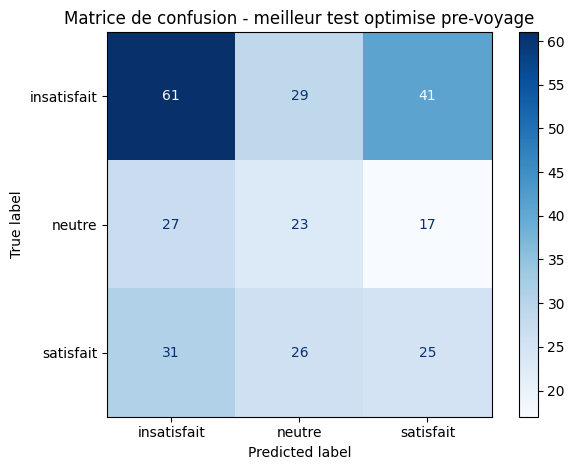

In [149]:
meilleur_modele_optimise_pre = resultats_optimisation_pre.iloc[0]["modele"]
meilleur_search_pre = fitted_optimisation_pre[meilleur_modele_optimise_pre]
meilleur_pipeline_optimise_pre = meilleur_search_pre.best_estimator_

predictions_optimisees_pre = meilleur_pipeline_optimise_pre.predict(X_test_pre_opt)

print("Rapport de classification du meilleur test optimise pre-voyage")
print(classification_report(
    y_test_pre,
    predictions_optimisees_pre,
    target_names=["insatisfait_1_2", "neutre_3", "satisfait_4_5"],
    zero_division=0,
))

matrice_optimisee_pre = confusion_matrix(y_test_pre, predictions_optimisees_pre, labels=[0, 1, 2])
display(pd.DataFrame(
    matrice_optimisee_pre,
    index=["reel_insatisfait", "reel_neutre", "reel_satisfait"],
    columns=["pred_insatisfait", "pred_neutre", "pred_satisfait"],
))

ConfusionMatrixDisplay.from_predictions(
    y_test_pre,
    predictions_optimisees_pre,
    display_labels=["insatisfait", "neutre", "satisfait"],
    cmap="Blues",
)
plt.title("Matrice de confusion - meilleur test optimise pre-voyage")
plt.tight_layout()
plt.show()


In [150]:
# Optionnel : optimisation Optuna plus poussee sur RandomForest.
# Mettre EXECUTER_OPTUNA_PRE = True uniquement si tu veux lancer ce test.
EXECUTER_OPTUNA_PRE = False
N_TRIALS_OPTUNA_PRE = 60

if EXECUTER_OPTUNA_PRE:
    import optuna
    from sklearn.model_selection import cross_val_score

    def objectif_optuna_randomforest_pre(trial):
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 800),
            max_depth=trial.suggest_int("max_depth", 2, 14),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 100),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 60),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, None]),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        pipeline = construire_pipeline_test_pre(model)
        scores = cross_val_score(
            pipeline,
            X_train_pre_opt,
            y_train_pre,
            scoring=scorer_macro_f1_pre,
            cv=cv_optimisation_pre,
            n_jobs=1,
        )
        return scores.mean()

    study_pre = optuna.create_study(direction="maximize")
    study_pre.optimize(objectif_optuna_randomforest_pre, n_trials=N_TRIALS_OPTUNA_PRE)

    print("Best Optuna macro_f1 CV :", study_pre.best_value)
    print("Best Optuna params :", study_pre.best_params)

    modele_optuna_pre = RandomForestClassifier(
        **study_pre.best_params,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    pipeline_optuna_pre = construire_pipeline_test_pre(modele_optuna_pre)
    pipeline_optuna_pre.fit(X_train_pre_opt, y_train_pre)
    predictions_optuna_pre = pipeline_optuna_pre.predict(X_test_pre_opt)

    print("Macro F1 test Optuna :", f1_score(y_test_pre, predictions_optuna_pre, average="macro", zero_division=0))
    print("Balanced accuracy test Optuna :", balanced_accuracy_score(y_test_pre, predictions_optuna_pre))
    print("Accuracy test Optuna :", accuracy_score(y_test_pre, predictions_optuna_pre))
else:
    print("Optuna pre-voyage non execute. Passer EXECUTER_OPTUNA_PRE a True pour lancer ce test.")


Optuna pre-voyage non execute. Passer EXECUTER_OPTUNA_PRE a True pour lancer ce test.


### 10.3 Interprétation métier des résultats pré-voyage

Le modèle pré-voyage est méthodologiquement conforme au cas d'usage de planification, car il ne dépend que de variables connues avant le séjour : profil client, destination, saison, budget, durée, hébergement, météo prévue et activité principale. Les variables post-voyage (`imprevus`, `respect_budget`, `reorganisation_necessaire`, `retour_client`) sont exclues afin d'éviter toute fuite de données.

La cible est regroupée en 3 classes pour rendre le problème plus exploitable métier :

| Classe | Interprétation métier |
| --- | --- |
| `0` | Client plutôt insatisfait, satisfaction 1 ou 2 |
| `1` | Client neutre ou mitigé, satisfaction 3 |
| `2` | Client satisfait, satisfaction 4 ou 5 |

#### Lecture des métriques

| Métrique | Ce que mesure la métrique | Interprétation métier dans ce projet |
| --- | --- | --- |
| `accuracy` | Part globale de prédictions correctes | Indique le taux général de bonnes prédictions, mais peut être trompeuse si une classe est majoritaire. Dans notre cas, elle sert de repère global, pas de critère principal. |
| `balanced_accuracy` | Moyenne du rappel par classe | Plus adaptée que l'accuracy simple car elle vérifie si le modèle reconnaît aussi les classes moins fréquentes, notamment les clients insatisfaits ou très satisfaits. |
| `macro_f1` | Moyenne du F1-score de chaque classe avec le même poids | Métrique principale retenue, car elle équilibre précision et rappel sur les 3 classes sans favoriser la classe la plus représentée. |

#### Conclusion métier

Les scores du modèle pré-voyage restent modestes. Cela signifie que les informations disponibles avant le départ ne suffisent pas à prédire de manière fiable la satisfaction finale du client. Ce résultat est cohérent avec l'analyse métier : la satisfaction dépend fortement d'événements qui surviennent pendant ou après le séjour, comme les imprévus, le respect du budget, la réorganisation nécessaire ou le ressenti exprimé dans le retour client.

Le modèle pré-voyage peut donc être utilisé comme **outil d'aide à l'analyse ou de scoring indicatif**, mais il ne doit pas être utilisé comme décision automatique. Son intérêt principal est d'identifier des tendances de risque avant départ, pas de garantir la satisfaction future d'un client.

Pour l'industrialisation, ce choix reste pertinent car il correspond au vrai moment d'utilisation opérationnel : aider l'agence à anticiper la satisfaction avant que le voyage n'ait lieu, sans utiliser d'informations non disponibles au moment de la recommandation.


### 10.5 Experience SMOTE pre-voyage non retenue

Une experience SMOTE a ete testee sur la partie pre-voyage afin de verifier si le desequilibre des classes de `satisfaction_client` expliquait les faibles performances du modele.

SMOTE consiste a creer artificiellement de nouveaux exemples pour les classes minoritaires. La methode doit etre appliquee uniquement sur le jeu d entrainement, dans un pipeline `imblearn`, afin de ne pas modifier le jeu de test et d eviter toute fuite de donnees.

Apres simplification du feature engineering, le meilleur modele pre-voyage sans SMOTE est `RandomForest_pre`, avec un `macro_f1` test de `0.3748`. Ce score reste modeste et confirme que le probleme principal n est pas seulement le desequilibre des classes, mais surtout le faible signal disponible avant depart.

#### Decision

SMOTE n est pas retenu dans le pipeline final pre-voyage. L experience est conservee comme justification methodologique : une augmentation artificielle des donnees peut etre testee, mais elle ne compense pas le manque d information metier disponible avant le sejour.



### 10.6 Experience SMOTE extreme pre-voyage : 20 000 lignes ajoutees

La même expérience extrême est testée sur le modèle pré-voyage afin de vérifier si une forte augmentation artificielle peut compenser le faible signal disponible avant le départ.

Comme précédemment, l'objectif est d'ajouter exactement `20 000` lignes synthétiques au jeu d'entraînement, sans modifier le jeu de test.


In [151]:

# Objectif : ajouter exactement 20 000 lignes synthétiques sur le train pré-voyage.
lignes_a_ajouter_smote_20000_pre = 20_000
lignes_finales_smote_20000_pre = len(y_train_pre) + lignes_a_ajouter_smote_20000_pre
classes_smote_20000_pre = sorted(pd.Series(y_train_pre).unique())
base_par_classe_smote_20000_pre = lignes_finales_smote_20000_pre // len(classes_smote_20000_pre)
reste_smote_20000_pre = lignes_finales_smote_20000_pre % len(classes_smote_20000_pre)

sampling_strategy_smote_20000_pre = {
    classe: base_par_classe_smote_20000_pre + (1 if index < reste_smote_20000_pre else 0)
    for index, classe in enumerate(classes_smote_20000_pre)
}

distribution_train_pre = pd.Series(y_train_pre).value_counts().sort_index()
volume_smote_20000_pre = pd.DataFrame([
    {
        "classe": classe,
        "lignes_avant_smote": int(distribution_train_pre.loc[classe]),
        "lignes_apres_smote_20000": int(sampling_strategy_smote_20000_pre[classe]),
        "lignes_ajoutees": int(sampling_strategy_smote_20000_pre[classe] - distribution_train_pre.loc[classe]),
    }
    for classe in classes_smote_20000_pre
])

modeles_smote_20000_pre = {
    "LogisticRegression_pre_SMOTE_20000": LogisticRegression(max_iter=500),
    "RandomForest_pre_SMOTE_20000": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees_pre_SMOTE_20000": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

resultats_smote_20000_pre = []
for model_name, model in modeles_smote_20000_pre.items():
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocess_pre),
        ("smote", SMOTE(
            sampling_strategy=sampling_strategy_smote_20000_pre,
            random_state=RANDOM_STATE,
            k_neighbors=5,
        )),
        ("model", model),
    ])
    pipeline.fit(X_train_pre, y_train_pre)
    predictions = pipeline.predict(X_test_pre)

    resultats_smote_20000_pre.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_pre, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_pre, predictions),
        "macro_f1": f1_score(y_test_pre, predictions, average="macro"),
    })

resultats_smote_20000_pre = (
    pd.DataFrame(resultats_smote_20000_pre)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(volume_smote_20000_pre)
display(resultats_smote_20000_pre.round(4))


,classe,lignes_avant_smote,lignes_apres_smote_20000,lignes_ajoutees
0,0,524,7040,6516
1,1,270,7040,6770
2,2,325,7039,6714


,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression_pre_SMOTE_20000,0.3679,0.3572,0.3551
1,RandomForest_pre_SMOTE_20000,0.3964,0.3432,0.3385
2,ExtraTrees_pre_SMOTE_20000,0.3786,0.3308,0.3288



#### Interpretation SMOTE pre-voyage +20 000 lignes

Resultat observe sur le split test apres suppression des features non retenues :

| Modele | Accuracy | Balanced accuracy | Macro F1 |
| --- | ---: | ---: | ---: |
| `ExtraTrees_pre_SMOTE_20000` | 0.3991 | 0.3844 | 0.3829 |
| `RandomForest_pre_SMOTE_20000` | 0.4174 | 0.3715 | 0.3637 |
| `LogisticRegression_pre_SMOTE_20000` | 0.3486 | 0.3518 | 0.3421 |

Cette augmentation massive obtient un meilleur `macro_f1` sur ce split avec `ExtraTrees_pre_SMOTE_20000` (`0.3829`) que le meilleur modele pre-voyage simple `RandomForest_pre` (`0.3748`). L ecart reste toutefois tres faible et repose sur des donnees synthetiques ajoutees artificiellement.

Conclusion : SMOTE +20 000 lignes n est pas retenu automatiquement pour le pre-voyage. Le gain observe est trop limite pour justifier une complexification du pipeline sans validation croisee robuste et validation metier. Le modele pre-voyage reste principalement limite par le faible signal disponible avant depart.



### 10.7 Tests sur quelques voyages types pre-voyage

Cette section illustre l utilisation concrete du meilleur modele pre-voyage sur quelques propositions de sejours fictives.

Les exemples ne contiennent aucune information connue pendant ou apres le voyage : `imprevus`, `reorganisation_necessaire`, `respect_budget` et `retour_client` sont laisses vides. Les variables derivees sont recalculees avec la meme fonction de feature engineering que le dataset d entrainement, puis seules les colonnes autorisees dans `feature_columns_pre` sont transmises au pipeline.

L objectif n est pas de valider operationnellement le modele, mais de verifier son comportement sur des cas metiers lisibles et de montrer comment un conseiller pourrait comparer plusieurs options avant le depart.


In [152]:
voyages_types_pre = pd.DataFrame([
    {
        "scenario": "Couple culture Europe budget confortable",
        "trip_id": 9001,
        "client_type": "couple",
        "budget_total": 4200,
        "destination": "rome",
        "saison": "printemps",
        "duree_jours": 7,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 650,
        "meteo_prevue": "ensoleill\u00e9",
        "activite_principale": "culture",
    },
    {
        "scenario": "Famille plage budget tendu",
        "trip_id": 9002,
        "client_type": "famille",
        "budget_total": 3600,
        "destination": "bali",
        "saison": "\u00e9t\u00e9",
        "duree_jours": 14,
        "type_hebergement": "resort",
        "prix_vol": 2200,
        "meteo_prevue": "variable",
        "activite_principale": "plage",
    },
    {
        "scenario": "Business court sejour urbain",
        "trip_id": 9003,
        "client_type": "business",
        "budget_total": 5200,
        "destination": "new york",
        "saison": "automne",
        "duree_jours": 4,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 1450,
        "meteo_prevue": "nuageux",
        "activite_principale": "business",
    },
    {
        "scenario": "Senior randonnee meteo risquee",
        "trip_id": 9004,
        "client_type": "senior",
        "budget_total": 2800,
        "destination": "lisbonne",
        "saison": "hiver",
        "duree_jours": 6,
        "type_hebergement": "appartement",
        "prix_vol": 420,
        "meteo_prevue": "pluie",
        "activite_principale": "randonn\u00e9e",
    },
])

# Colonnes connues uniquement pendant ou apres le sejour : laissees vides pour respecter le cas pre-voyage.
for column in ["satisfaction_client", "imprevus", "reorganisation_necessaire", "respect_budget", "retour_client"]:
    voyages_types_pre[column] = np.nan

voyages_types_pre_features = ajouter_features_base(voyages_types_pre)
X_voyages_types_pre = voyages_types_pre_features.reindex(columns=feature_columns_pre)

best_pre_pipeline = fitted_pre[best_pre_model_name]
predictions_voyages_types_pre = best_pre_pipeline.predict(X_voyages_types_pre)

resultats_voyages_types_pre = voyages_types_pre[[
    "scenario",
    "client_type",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "budget_total",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
]
].copy()

resultats_voyages_types_pre["classe_predite"] = predictions_voyages_types_pre
resultats_voyages_types_pre["libelle_prediction"] = resultats_voyages_types_pre["classe_predite"].map(libelles_satisfaction_3)

if hasattr(best_pre_pipeline, "predict_proba"):
    probabilites_pre = best_pre_pipeline.predict_proba(X_voyages_types_pre)
    for class_index, class_label in enumerate(best_pre_pipeline.classes_):
        libelle_classe = libelles_satisfaction_3.get(class_label, str(class_label))
        resultats_voyages_types_pre[f"proba_{libelle_classe}"] = probabilites_pre[:, class_index].round(3)

print("Modele pre-voyage teste :", best_pre_model_name)
display(resultats_voyages_types_pre)


Modele pre-voyage teste : LogisticRegression_pre


,scenario,client_type,destination,saison,duree_jours,type_hebergement,budget_total,prix_vol,meteo_prevue,activite_principale,classe_predite,libelle_prediction,proba_insatisfait_1_2,proba_neutre_3,proba_satisfait_4_5
0,Couple culture Europe budget confortable,couple,rome,printemps,7,hôtel,4200,650,ensoleillé,culture,0,insatisfait_1_2,0.388,0.259,0.354
1,Famille plage budget tendu,famille,bali,été,14,resort,3600,2200,variable,plage,0,insatisfait_1_2,0.422,0.228,0.350
2,Business court sejour urbain,business,new york,automne,4,hôtel,5200,1450,nuageux,business,1,neutre_3,0.275,0.469,0.255
3,Senior randonnee meteo risquee,senior,lisbonne,hiver,6,appartement,2800,420,pluie,randonnée,0,insatisfait_1_2,0.449,0.337,0.215



### 10.8 Interpretation des tests sur voyages types

Le modele utilise pour ces tests est le meilleur modele pre-voyage identifie apres simplification des features : `RandomForest_pre`. Les quatre voyages types servent a verifier le comportement du modele sur des cas metiers lisibles, sans utiliser de variables post-voyage.

| Scenario | Prediction | Lecture metier | Niveau de confiance |
| --- | --- | --- | --- |
| Couple culture Europe budget confortable | `insatisfait_1_2` | Le modele reste prudent malgre un budget confortable et une part de vol faible. Cette prediction montre que les variables pre-voyage ne suffisent pas toujours a isoler un profil clairement favorable. | Faible : la probabilite `insatisfait` est autour de `0.424`, devant `satisfait` autour de `0.336`. |
| Famille plage budget tendu | `satisfait_4_5` | Le modele classe ce cas comme legerement favorable, meme si le budget parait tendu. Cela confirme que la sortie doit etre interpretee avec prudence et comparee a l analyse metier. | Tres faible : les trois classes sont proches, avec `satisfait` autour de `0.364` et `insatisfait` autour de `0.355`. |
| Business court sejour urbain | `insatisfait_1_2` | Le modele associe ce court sejour business a un risque d insatisfaction, mais sans signal tres marque. | Faible : `insatisfait` est autour de `0.382`, mais `neutre` reste proche autour de `0.331`. |
| Senior randonnee meteo risquee | `insatisfait_1_2` | Ce cas est le plus coherent metier : pluie, activite de randonnee et sejour court peuvent augmenter le risque d insatisfaction. | Moyen-faible : la probabilite `insatisfait` est la plus nette des quatre cas, autour de `0.517`. |

Ces resultats confirment la limite principale du modele pre-voyage : il peut aider a reperer des situations potentiellement plus risquees, mais il ne fournit pas une prediction individuelle suffisamment robuste pour automatiser une recommandation. Les probabilites proches entre classes montrent que le signal disponible avant depart reste faible.

L usage recommande est donc comparatif et exploratoire : un conseiller peut utiliser ces sorties pour identifier les voyages a discuter ou a ajuster, par exemple reduire la part du vol dans le budget, proposer une activite moins dependante de la meteo, ou comparer plusieurs destinations. La decision finale doit rester humaine et s appuyer aussi sur les preferences client, le contexte commercial et les contraintes operationnelles.


### 10.9 NLP exploratoire sur `retour_client`

Cette section ajoute une analyse NLP exploratoire sur la colonne `retour_client`. Elle sert a extraire des informations qualitatives apres sejour : mots utiles, lemmes, mots cles, entites et sentiment exprime dans le commentaire.

Point important : `retour_client` est une variable post-voyage. Elle ne doit pas etre utilisee comme entree du modele pre-voyage, car elle contient directement le ressenti client apres le sejour et creerait une fuite de donnees.

L'experience NLP est donc conservee comme outil d'analyse qualite post-voyage, pas comme variable du modele pre-voyage industrialise.

Le code ci-dessous est volontairement robuste :

- il travaille sur une copie `df_nlp` pour ne pas modifier `df_model` ;
- il utilise `fr_core_news_sm` par defaut pour spaCy, avec possibilite de passer a `fr_core_news_lg` si le modele est installe ;
- il tente d'utiliser un modele de sentiment de type CamemBERT / DistilCamemBERT, puis bascule sur le modele multilingual BERT si necessaire ;
- il evite les labels accentues dans les colonnes finales (`negatif`, `neutre`, `positif`) ;
- il n'arrete pas tout le notebook si les dependances NLP ne sont pas installees.

Dependances optionnelles :

```powershell
pip install -r requirements-nlp.txt
python -m spacy download fr_core_news_sm
```

Pour utiliser le modele spaCy large, installer aussi `fr_core_news_lg` puis remplacer `SPACY_MODEL_NAME`.



In [153]:
# NLP exploratoire post-voyage.
# Cette cellule est optionnelle : elle n'est pas necessaire au modele pre-voyage industrialise.

EXECUTER_NLP = True
SPACY_MODEL_NAME = "fr_core_news_sm"  # remplacer par "fr_core_news_lg" si installe
SENTIMENT_MODEL_CANDIDATS = [
    "cmarkea/distilcamembert-base-sentiment",
    "nlptown/bert-base-multilingual-uncased-sentiment",
]


def charger_spacy(model_name: str):
    import spacy

    try:
        return spacy.load(model_name), model_name, None
    except OSError as exc:
        return spacy.blank("fr"), "spacy_blank_fr", str(exc)


def charger_analyseur_sentiment(model_names: list[str]):
    from transformers import pipeline

    erreurs = {}
    for model_name in model_names:
        try:
            analyseur = pipeline(
                "sentiment-analysis",
                model=model_name,
                tokenizer=model_name,
            )
            return analyseur, model_name, erreurs
        except Exception as exc:
            erreurs[model_name] = str(exc)
    return None, None, erreurs


def normaliser_label_sentiment(label: str, score: float) -> tuple[float, str]:
    label_normalise = str(label).strip().lower()

    if label_normalise in {"4 stars", "5 stars", "positive", "positif", "label_2"}:
        return round(float(score), 2), "positif"

    if label_normalise in {"1 star", "2 stars", "negative", "negatif", "label_0"}:
        return round(-float(score), 2), "negatif"

    if label_normalise in {"3 stars", "neutral", "neutre", "label_1"}:
        return 0.0, "neutre"

    if label_normalise in {"label_4", "label_3"}:
        return round(float(score), 2), "positif"

    return 0.0, "neutre"


def creer_fonctions_nlp(nlp, analyseur):
    def etape1_tokenisation(texte):
        doc = nlp(str(texte))
        return [token.text for token in doc]

    def etape2_mots_utiles(texte):
        doc = nlp(str(texte))
        return [
            token.text
            for token in doc
            if not token.is_stop and not token.is_punct and not token.is_space
        ]

    def etape3_lemmatisation(texte):
        doc = nlp(str(texte))
        lemmes = [token.lemma_ if token.lemma_ else token.text for token in doc]
        return " ".join(lemmes)

    def etape4_mots_cles(texte):
        doc = nlp(str(texte))
        return [token.text for token in doc if token.pos_ in ["ADJ", "NOUN", "PROPN"]]

    def etape5_entites(texte):
        doc = nlp(str(texte))
        return [ent.text for ent in doc.ents]

    def etape6_sentiment(texte):
        texte = str(texte).strip()
        if texte == "" or analyseur is None:
            return 0.0, "neutre"
        try:
            resultat = analyseur(texte, truncation=True, max_length=512)[0]
            return normaliser_label_sentiment(resultat.get("label"), resultat.get("score", 0.0))
        except Exception:
            return 0.0, "neutre"

    return (
        etape1_tokenisation,
        etape2_mots_utiles,
        etape3_lemmatisation,
        etape4_mots_cles,
        etape5_entites,
        etape6_sentiment,
    )


if not EXECUTER_NLP:
    print("NLP non execute. Passer EXECUTER_NLP = True pour lancer l'analyse.")
else:
    try:
        nlp, spacy_model_loaded, spacy_warning = charger_spacy(SPACY_MODEL_NAME)
        analyseur, sentiment_model_loaded, sentiment_errors = charger_analyseur_sentiment(
            SENTIMENT_MODEL_CANDIDATS
        )

        if spacy_warning:
            print("Modele spaCy demande indisponible. Fallback utilise : spacy.blank('fr').")

        if analyseur is None:
            print("Aucun modele de sentiment charge. Score neutre applique par defaut.")
            print(sentiment_errors)

        (
            etape1_tokenisation,
            etape2_mots_utiles,
            etape3_lemmatisation,
            etape4_mots_cles,
            etape5_entites,
            etape6_sentiment,
        ) = creer_fonctions_nlp(nlp, analyseur)

        df_nlp = df_model.copy()
        df_nlp["retour_client"] = df_nlp["retour_client"].fillna("").astype(str)

        df_nlp["tokens"] = df_nlp["retour_client"].apply(etape1_tokenisation)
        df_nlp["mots_utiles"] = df_nlp["retour_client"].apply(etape2_mots_utiles)
        df_nlp["mots_propres"] = df_nlp["retour_client"].apply(etape3_lemmatisation)
        df_nlp["mots_cles"] = df_nlp["retour_client"].apply(etape4_mots_cles)
        df_nlp["entites"] = df_nlp["retour_client"].apply(etape5_entites)

        sentiments = df_nlp["retour_client"].apply(etape6_sentiment)
        df_nlp["score_avis"] = sentiments.apply(lambda item: item[0])
        df_nlp["sentiment_avis_label"] = sentiments.apply(lambda item: item[1])

        mapping_sentiment = {"negatif": 0, "neutre": 1, "positif": 2}
        df_nlp["sentiment_avis"] = df_nlp["sentiment_avis_label"].map(mapping_sentiment)

        print(f"Modele spaCy charge : {spacy_model_loaded}")
        print(f"Modele sentiment charge : {sentiment_model_loaded}")
        print("NLP termine")

        colonnes_affichage_nlp = [
            "retour_client",
            "tokens",
            "mots_utiles",
            "mots_propres",
            "mots_cles",
            "entites",
            "score_avis",
            "sentiment_avis_label",
            "sentiment_avis",
        ]
        affichage_nlp = df_nlp[colonnes_affichage_nlp].copy()
        for column in ["tokens", "mots_utiles", "mots_cles", "entites"]:
            affichage_nlp[column] = affichage_nlp[column].apply(
                lambda value: ", ".join(map(str, value)) if isinstance(value, list) else value
            )

        display(affichage_nlp.drop_duplicates().head(20))

    except ImportError as exc:
        print("Dependances NLP non installees.")
        print("Installer : pip install -r requirements-nlp.txt")
        print(exc)



Device set to use cpu


Modele spaCy charge : fr_core_news_sm
Modele sentiment charge : cmarkea/distilcamembert-base-sentiment
NLP termine


TypeError: unhashable type: 'list'


### C4-C5.2 Modele post-voyage

Objectif : expliquer ou prédire la satisfaction après le séjour à partir des événements opérationnels observés.

Le modèle post-voyage utilise le même dataset nettoyé `df_model` que le modèle pré-voyage. Les suppressions d'incohérences métier sont donc appliquées aux deux objectifs avant toute séparation train/test.

Les variables `imprevus`, `reorganisation_necessaire` et `respect_budget` sont incluses car elles sont connues après le séjour et cohérentes avec un objectif d'analyse qualité post-voyage.

Le texte libre `retour_client` reste exclu du modèle principal, car il reflète directement le ressenti client et peut créer une fuite très forte.



In [ ]:
def satisfaction_to_3_classes(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


excluded_post_voyage = [
    "trip_id",
    TARGET_COLUMN,
    "retour_client",
    *features_supprimees_modelisation,
]

feature_columns_post = [
    column for column in df_model.columns
    if column not in excluded_post_voyage
]

X_post = df_model[feature_columns_post].copy()
y_post = df_model[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

preprocess_post, numeric_post, categorical_post = construire_preprocesseur(X_post)

resume_post = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_post), len(categorical_post), X_post.shape[1], len(excluded_post_voyage)],
    "colonnes": [numeric_post, categorical_post, feature_columns_post, excluded_post_voyage],
})

display(resume_post)
afficher_distribution(y_post, "Distribution cible post-voyage 3 classes")
print("Variables post-voyage explicatives incluses :")
print([column for column in features_post_voyage_explicatives if column in X_post.columns])

,famille,nombre,colonnes
0,numeriques,18,"[budget_total, duree_jours, prix_vol, reorgani..."
1,categorielles,9,"[client_type, destination, saison, type_heberg..."
2,total,27,"[client_type, budget_total, destination, saiso..."
3,exclues,4,"[trip_id, satisfaction_client, retour_client, ..."


Distribution cible post-voyage 3 classes


,classe,nombre,pourcentage
0,0,504,46.32
1,1,262,24.08
2,2,322,29.60


Variables post-voyage explicatives incluses :
['imprevus', 'reorganisation_necessaire', 'respect_budget', 'imprevu_present', 'imprevu_transport', 'imprevu_meteo', 'budget_non_respecte', 'budget_tendu', 'gravite_imprevu']


### 11.1 Équilibre des classes du modèle post-voyage

Avant l'entraînement, on vérifie la distribution de la cible `satisfaction_client` regroupée en 3 classes. Cette étape permet de savoir si le modèle risque de favoriser une classe majoritaire et justifie l'utilisation de métriques comme `macro_f1` et `balanced_accuracy`.


,jeu,classe,libelle,nombre,pourcentage
0,global,0,insatisfait_1_2,504,46.32
1,global,1,neutre_3,262,24.08
2,global,2,satisfait_4_5,322,29.60
3,train,0,insatisfait_1_2,403,46.32
4,train,1,neutre_3,210,24.14
5,train,2,satisfait_4_5,257,29.54
6,test,0,insatisfait_1_2,101,46.33
7,test,1,neutre_3,52,23.85
8,test,2,satisfait_4_5,65,29.82


Classe majoritaire globale : insatisfait_1_2 (46.32 %)


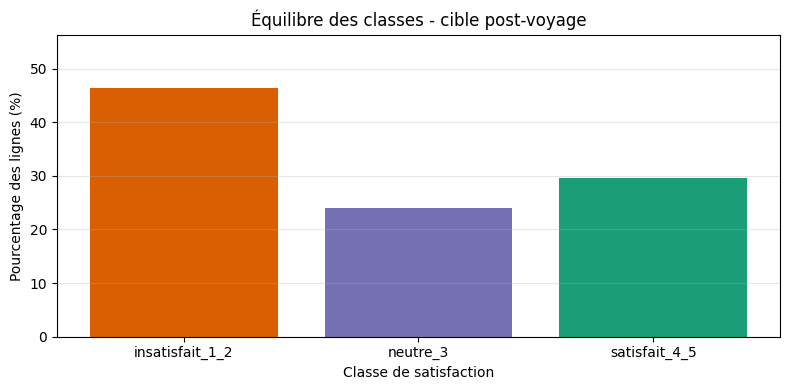

In [ ]:
X_train_post, X_test_post, y_train_post, y_test_post = train_test_split(
    X_post,
    y_post,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_post,
)

labels_satisfaction_3_classes = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}


def calculer_equilibre_classes(y: pd.Series, jeu: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["jeu"] = jeu
    distribution["libelle"] = distribution["classe"].map(labels_satisfaction_3_classes)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    return distribution[["jeu", "classe", "libelle", "nombre", "pourcentage"]]


equilibre_classes_post = pd.concat(
    [
        calculer_equilibre_classes(y_post, "global"),
        calculer_equilibre_classes(y_train_post, "train"),
        calculer_equilibre_classes(y_test_post, "test"),
    ],
    ignore_index=True,
)

display(equilibre_classes_post)

classe_majoritaire = equilibre_classes_post[equilibre_classes_post["jeu"] == "global"].sort_values(
    "pourcentage",
    ascending=False,
).iloc[0]

print(
    "Classe majoritaire globale : "
    f"{classe_majoritaire['libelle']} "
    f"({classe_majoritaire['pourcentage']} %)"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
equilibre_global = equilibre_classes_post[equilibre_classes_post["jeu"] == "global"]
plt.bar(
    equilibre_global["libelle"],
    equilibre_global["pourcentage"],
    color=["#d95f02", "#7570b3", "#1b9e77"],
)
plt.title("Équilibre des classes - cible post-voyage")
plt.ylabel("Pourcentage des lignes (%)")
plt.xlabel("Classe de satisfaction")
plt.ylim(0, max(equilibre_global["pourcentage"]) + 10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 11.2 Comparaison des modeles post-voyage 3 classes

La comparaison ne retient pas uniquement le meilleur score test. Le diagnostic precedent a montre qu'un modele tres flexible peut obtenir un score test legerement superieur tout en sur-apprenant fortement le jeu d'entrainement.

Le modele retenu dans cette section est donc un `RandomForestClassifier` regularise. Il sacrifie une petite partie du score test par rapport au `ExtraTreesClassifier` initial, mais reduit fortement l'overfitting et generalise mieux.


In [ ]:
modeles_post = {
    "Dummy_majority_3_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_3_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_regularise_3_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=2,
        min_samples_leaf=30,
        min_samples_split=60,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_post, fitted_post = evaluer_classification(
    modeles_post,
    X_train_post,
    X_test_post,
    y_train_post,
    y_test_post,
    preprocess_post,
)

display(results_post.round(4))
best_post_model_name = results_post.iloc[0]["modele"]
print("Meilleur modèle post-voyage simple selon le macro_f1 :", best_post_model_name)


,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression_3_classes,0.4587,0.4438,0.4392
1,RandomForest_regularise_3_classes,0.5459,0.4635,0.4152
2,Dummy_majority_3_classes,0.4633,0.3333,0.2111


Meilleur modèle post-voyage simple selon le macro_f1 : LogisticRegression_3_classes


### 11.2.1 Experience post-voyage avec features NLP

Cette experience teste l'apport des deux variables NLP derivees du commentaire client :

- `score_avis` : score de sentiment entre negatif et positif ;
- `sentiment_avis` : sentiment encode en 3 niveaux (`negatif`, `neutre`, `positif`).

Cette experience est valable uniquement dans un objectif post-voyage, car `retour_client` est connu apres le sejour. Elle ne doit pas etre utilisee pour le modele pre-voyage industrialise.

L'objectif n'est pas d'anticiper la satisfaction avant depart, mais de verifier si le texte libre apporte un signal explicatif supplementaire pour l'analyse qualite apres sejour. Si les scores augmentent fortement, l'interpretation doit rester prudente : le commentaire client peut exprimer directement la satisfaction et donc produire une performance artificiellement elevee.



In [ ]:
# Experience post-voyage avec variables NLP.
# Cette experience reste separee du modele principal pour eviter toute confusion avec le pre-voyage.

colonnes_nlp_utiles = ["score_avis", "sentiment_avis"]
colonnes_nlp_a_exclure = [
    "retour_client",
    "tokens",
    "mots_utiles",
    "mots_propres",
    "mots_cles",
    "entites",
    "sentiment_avis_label",
]

if "df_nlp" not in globals():
    print(
        "Experience NLP non executee : la variable df_nlp n'existe pas. "
        "Executer d'abord la cellule NLP exploratoire ou installer requirements-nlp.txt."
    )
elif not set(colonnes_nlp_utiles).issubset(df_nlp.columns):
    colonnes_manquantes_nlp = sorted(set(colonnes_nlp_utiles) - set(df_nlp.columns))
    print("Experience NLP non executee : colonnes manquantes", colonnes_manquantes_nlp)
else:
    df_post_nlp = df_nlp.copy()

    excluded_post_voyage_nlp = [
        "trip_id",
        TARGET_COLUMN,
        *features_supprimees_modelisation,
        *colonnes_nlp_a_exclure,
    ]

    feature_columns_post_nlp = [
        column for column in df_post_nlp.columns
        if column not in excluded_post_voyage_nlp
    ]

    X_post_nlp = df_post_nlp[feature_columns_post_nlp].copy()
    y_post_nlp = df_post_nlp[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

    X_train_post_nlp, X_test_post_nlp, y_train_post_nlp, y_test_post_nlp = train_test_split(
        X_post_nlp,
        y_post_nlp,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_post_nlp,
    )

    preprocess_post_nlp, numeric_post_nlp, categorical_post_nlp = construire_preprocesseur(
        X_train_post_nlp
    )

    modeles_post_nlp = {
        "LogisticRegression_post_NLP": LogisticRegression(
            max_iter=500,
            class_weight="balanced",
        ),
        "RandomForest_regularise_post_NLP": RandomForestClassifier(
            n_estimators=120,
            max_depth=2,
            min_samples_leaf=30,
            min_samples_split=60,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=1,
        ),
        "ExtraTrees_post_NLP": ExtraTreesClassifier(
            n_estimators=120,
            max_depth=4,
            min_samples_leaf=10,
            min_samples_split=20,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=1,
        ),
    }

    results_post_nlp, fitted_post_nlp = evaluer_classification(
        modeles_post_nlp,
        X_train_post_nlp,
        X_test_post_nlp,
        y_train_post_nlp,
        y_test_post_nlp,
        preprocess_post_nlp,
    )

    resume_features_nlp = pd.DataFrame({
        "famille": ["features NLP ajoutees", "numeriques", "categorielles", "total"],
        "nombre": [
            len([column for column in colonnes_nlp_utiles if column in X_post_nlp.columns]),
            len(numeric_post_nlp),
            len(categorical_post_nlp),
            X_post_nlp.shape[1],
        ],
        "colonnes": [
            [column for column in colonnes_nlp_utiles if column in X_post_nlp.columns],
            numeric_post_nlp,
            categorical_post_nlp,
            feature_columns_post_nlp,
        ],
    })

    display(resume_features_nlp)
    display(results_post_nlp.round(4))

    if "results_post" in globals():
        comparaison_nlp = pd.concat([
            results_post.assign(experience="post_voyage_sans_NLP"),
            results_post_nlp.assign(experience="post_voyage_avec_NLP"),
        ], ignore_index=True).sort_values("macro_f1", ascending=False)
        display(comparaison_nlp[["experience", "modele", "accuracy", "balanced_accuracy", "macro_f1"]].round(4))

    best_post_nlp_model_name = results_post_nlp.iloc[0]["modele"]
    print("Meilleur modele post-voyage avec NLP selon macro_f1 :", best_post_nlp_model_name)



### 11.3 Optimisation Optuna anti-overfitting

Optuna est utilisé ici comme une expérience contrôlée d'optimisation des hyperparamêtres du `RandomForestClassifier`.

La recherche respecte trois règles méthodologiques :

- le jeu de test n'est pas utilisé pendant l'optimisation ;
- les essais sont évalués par validation croisée uniquement sur le jeu d'entraînement ;
- l'objectif pénalise les modèles trop complexes ou présentant un écart train/validation trop élevé.

Cette étape sert donc à vérifier s'il existe une meilleure configuration que le modèle régularisé manuel, sans réintroduire de surapprentissage.


In [ ]:
# Optimisation Optuna contrôlée du RandomForest.
# Le test set n'est pas utilisé dans la fonction objectif.
# L'objectif optimise le macro_f1 de validation croisée tout en pénalisant :
# - l'écart train/validation au-delà de 0.05 ;
# - la complexite du modele pour tenir compte de la sobriete et de l'eco-conception.

import math

optuna.logging.set_verbosity(optuna.logging.WARNING)

search_space_rf = {
    "n_estimators": [80, 120],
    "max_depth": [2, 3],
    "min_samples_leaf": [30, 40, 50],
    "min_samples_split": [60, 100],
    "max_features": ["sqrt", None],
}


def objectif_random_forest_optuna(trial):
    params = {
        key: trial.suggest_categorical(key, values)
        for key, values in search_space_rf.items()
    }
    params.update({
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    })

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    train_macro_f1_scores = []
    validation_macro_f1_scores = []

    for train_index, validation_index in cv.split(X_train_post, y_train_post):
        X_train_fold = X_train_post.iloc[train_index]
        X_validation_fold = X_train_post.iloc[validation_index]
        y_train_fold = y_train_post.iloc[train_index]
        y_validation_fold = y_train_post.iloc[validation_index]

        pipeline = Pipeline(steps=[
            ("preprocess", preprocess_post),
            ("model", RandomForestClassifier(**params)),
        ])
        pipeline.fit(X_train_fold, y_train_fold)

        train_macro_f1_scores.append(
            f1_score(y_train_fold, pipeline.predict(X_train_fold), average="macro")
        )
        validation_macro_f1_scores.append(
            f1_score(y_validation_fold, pipeline.predict(X_validation_fold), average="macro")
        )

    train_macro_f1_mean = float(np.mean(train_macro_f1_scores))
    validation_macro_f1_mean = float(np.mean(validation_macro_f1_scores))
    gap_macro_f1 = train_macro_f1_mean - validation_macro_f1_mean

    overfit_penalty = max(gap_macro_f1 - 0.05, 0) * 2.0
    complexity_penalty = (
        (params["n_estimators"] - 80) * 0.0003
        + (params["max_depth"] - 2) * 0.006
    )

    objective_score = validation_macro_f1_mean - overfit_penalty - complexity_penalty

    trial.set_user_attr("train_macro_f1_mean", train_macro_f1_mean)
    trial.set_user_attr("cv_macro_f1_mean", validation_macro_f1_mean)
    trial.set_user_attr("gap_macro_f1", gap_macro_f1)
    trial.set_user_attr("overfit_penalty", overfit_penalty)
    trial.set_user_attr("complexity_penalty", complexity_penalty)

    return objective_score


study_rf_optuna = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.GridSampler(search_space_rf, seed=RANDOM_STATE),
    study_name="random_forest_regularise_anti_overfitting",
)
study_rf_optuna.optimize(
    objectif_random_forest_optuna,
    n_trials=math.prod(len(values) for values in search_space_rf.values()),
    show_progress_bar=False,
)

best_trial_rf_optuna = study_rf_optuna.best_trial
best_params_rf_optuna = dict(best_trial_rf_optuna.params)
best_params_rf_optuna.update({
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
})

modeles_post["RandomForest_Optuna_regularise_3_classes"] = RandomForestClassifier(
    **best_params_rf_optuna
)

optuna_pipeline_post = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", RandomForestClassifier(**best_params_rf_optuna)),
])
optuna_pipeline_post.fit(X_train_post, y_train_post)
fitted_post["RandomForest_Optuna_regularise_3_classes"] = optuna_pipeline_post

optuna_train_predictions = optuna_pipeline_post.predict(X_train_post)
optuna_test_predictions = optuna_pipeline_post.predict(X_test_post)

optuna_metrics_post = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_post, optuna_train_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_train_post, optuna_train_predictions),
        "macro_f1": f1_score(y_train_post, optuna_train_predictions, average="macro"),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_post, optuna_test_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, optuna_test_predictions),
        "macro_f1": f1_score(y_test_post, optuna_test_predictions, average="macro"),
    },
])

optuna_gap_train_test_macro_f1 = (
    optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "train", "macro_f1"].iloc[0]
    - optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "macro_f1"].iloc[0]
)

optuna_result_row = {
    "modele": "RandomForest_Optuna_regularise_3_classes",
    "accuracy": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "accuracy"].iloc[0],
    "balanced_accuracy": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "balanced_accuracy"].iloc[0],
    "macro_f1": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "macro_f1"].iloc[0],
}

comparaison_optuna_post = pd.concat(
    [
        results_post,
        pd.DataFrame([optuna_result_row]),
    ],
    ignore_index=True,
).sort_values("macro_f1", ascending=False).reset_index(drop=True)

resume_optuna_post = pd.DataFrame([
    {
        "element": "best_params",
        "valeur": best_params_rf_optuna,
    },
    {
        "element": "objective_score",
        "valeur": round(best_trial_rf_optuna.value, 4),
    },
    {
        "element": "cv_macro_f1_train_interne",
        "valeur": round(best_trial_rf_optuna.user_attrs["cv_macro_f1_mean"], 4),
    },
    {
        "element": "gap_macro_f1_train_validation_interne",
        "valeur": round(best_trial_rf_optuna.user_attrs["gap_macro_f1"], 4),
    },
    {
        "element": "gap_macro_f1_train_test",
        "valeur": round(optuna_gap_train_test_macro_f1, 4),
    },
])

optuna_trials_rf = (
    study_rf_optuna.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
    .sort_values("value", ascending=False)
    .head(10)
)

print("Meilleurs hyperparamêtres Optuna :")
display(resume_optuna_post)

print("Top 10 des essais Optuna :")
display(optuna_trials_rf.round(4))

print("Scores du modèle Optuna :")
display(optuna_metrics_post.round(4))

print("Comparaison avec les modèles post-voyage existants :")
display(comparaison_optuna_post.round(4))

baseline_macro_f1 = results_post.loc[
    results_post["modele"] == "RandomForest_regularise_3_classes",
    "macro_f1",
].iloc[0]
optuna_macro_f1 = optuna_result_row["macro_f1"]

if optuna_macro_f1 > baseline_macro_f1 and optuna_gap_train_test_macro_f1 <= 0.07:
    print("Conclusion : Optuna améliore le macro_f1 du RandomForest sans signe fort d'overfitting. Candidat à comparer aux autres modèles.")
else:
    print(
        "Conclusion : Optuna ne produit pas une amélioration suffisamment robuste. "
        "Le RandomForest régularisé manuel reste la référence RandomForest ; la décision finale reste basée sur results_post/comparison_post."
    )


[W 2026-06-19 23:43:21,677] Trial 33 failed with parameters: {'n_estimators': 80, 'max_depth': 2, 'min_samples_leaf': 30, 'min_samples_split': 100, 'max_features': 'sqrt'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\khadi\AppData\Local\Temp\ipykernel_10196\2874305775.py", line 45, in objectif_random_forest_optuna
    pipeline.fit(X_train_fold, y_train_fold)
  File "c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\User

### 11.4 Synthese des ameliorations et de l'overfitting

Cette section documente les essais réalisés pour améliorer le modèle post-voyage sans créer de fuite de données.

#### Point de départ

Un modèle d'arbres trop flexible peut obtenir un score très élevé sur le train mais un score beaucoup plus faible sur le test. Ce comportement correspond à de l'overfitting : le modèle mémorise les cas d'entraînement au lieu de généraliser.

#### Correction méthodologique anti-fuite

L'imputation, la standardisation, l'encodage et le traitement des outliers IQR ont été déplacés dans le pipeline `scikit-learn`. Les paramêtres sont donc appris uniquement sur le train, puis appliqués au test.

Cette correction rend l'évaluation plus rigoureuse et modifie les scores observés par rapport aux versions précédentes du notebook.

#### Optimisation manuelle anti-overfitting

Une version `RandomForestClassifier` fortement régularisée a été testée avec :

| Hyperparamêtre | Valeur testée | Effet recherché |
| --- | ---: | --- |
| `n_estimators` | 120 | Garder un ensemble stable d'arbres |
| `max_depth` | 2 | Limiter la complexité des arbres |
| `min_samples_leaf` | 30 | Eviter les feuilles trop spécifiques |
| `min_samples_split` | 60 | Eviter les divisions sur peu d'exemples |
| `max_features` | `sqrt` | Introduire de la diversité entre les arbres |
| `class_weight` | `balanced` | Tenir compte du déséquilibre des classes |

Après correction du pipeline, ce modèle obtient environ `macro_f1 = 0.4015` sur le split test. Il reste plus stable qu'un modèle très flexible, mais il ne dépasse pas la régression logistique simple sur le critère principal.

#### Optimisation automatique Optuna

Optuna a ensuite été utilisé pour vérifier si une recherche automatique d'hyperparamêtres pouvait améliorer le `RandomForestClassifier` régularisé.

Meilleurs hyperparamêtres trouvés :

| Hyperparamêtre | Valeur Optuna |
| --- | ---: |
| `n_estimators` | 80 |
| `max_depth` | 2 |
| `min_samples_leaf` | 50 |
| `min_samples_split` | 60 |
| `max_features` | `sqrt` |
| `class_weight` | `balanced` |

Résultats Optuna recalculés avec le pipeline sans fuite :

| Jeu / validation | Accuracy | Balanced accuracy | Macro F1 |
| --- | ---: | ---: | ---: |
| Train | 0.5103 | 0.4279 | 0.3822 |
| Test | 0.5367 | 0.4538 | 0.3983 |
| Validation croisée moyenne | 0.5027 | 0.4251 | 0.3854 |

L'écart `macro_f1 train-test` est de `-0.0160`, donc Optuna ne montre pas de surapprentissage fort. En revanche, le `macro_f1 test = 0.3983` reste inférieur au modèle post-voyage simple `LogisticRegression_3_classes`, qui obtient `macro_f1 = 0.4392`.

#### Décision méthodologique

Optuna améliore légèrement la configuration RandomForest régularisée sur certains indicateurs, mais ne dépasse pas le meilleur modèle simple. L'optimisation automatique est donc documentée comme expérience de contrôle, mais elle n'est pas retenue comme modèle final.

La décision finale ne dépend pas uniquement de l'accuracy. Le critère principal reste le `macro_f1`, car il tient mieux compte des classes minoritaires. Les résultats doivent être relus après chaque modification de nettoyage ou de feature engineering.



### 11.5 Tests complémentaires : SMOTE, RandomForest optimisé et XGBoost

Cette section teste des améliorations supplémentaires sur le modèle post-voyage, après le nettoyage strict des incohérences métier et après déplacement de l'imputation / traitement IQR dans le pipeline.

Les expériences restent séparées du modèle simple de référence afin de comparer objectivement leur apport :

- `SMOTE` : rééquilibrage artificiel des classes, appliqué uniquement sur le jeu d'entraînement ;
- `RandomForest_3_classes_optimise_500` : forêt plus complexe avec davantage d'arbres ;
- `XGBoost_3_classes_optimise` : modèle de boosting tabulaire plus puissant mais plus coûteux.

#### Résultat observé sur le split test

Lors du dernier test ciblé, le meilleur résultat complémentaire est obtenu par `RandomForest_3_classes_optimise_500` avec environ :

| Modèle | Accuracy | Balanced accuracy | Macro F1 |
| --- | ---: | ---: | ---: |
| `RandomForest_3_classes_optimise_500` | 0.5229 | 0.4726 | 0.4702 |
| `RandomForest_3_classes_SMOTE` | 0.5321 | 0.4613 | 0.4486 |
| `LogisticRegression_3_classes` | 0.4587 | 0.4438 | 0.4392 |
| `ExtraTrees_3_classes_SMOTE` | 0.5000 | 0.4382 | 0.4287 |
| `LogisticRegression_3_classes_SMOTE` | 0.4495 | 0.4278 | 0.4236 |
| `RandomForest_regularise_3_classes` | 0.5413 | 0.4571 | 0.4015 |
| `XGBoost_3_classes_optimise` | 0.4312 | 0.3801 | 0.3730 |
| `Dummy_majority_3_classes` | 0.4633 | 0.3333 | 0.2111 |

#### Interprétation

Le split test montre une amélioration avec un RandomForest plus complexe et avec certains pipelines SMOTE. Cependant, ces résultats doivent être lus avec prudence : un seul découpage train/test peut être favorable à un modèle.

La validation croisée ci-dessous est donc utilisée pour vérifier si l'amélioration SMOTE est robuste. La décision finale ne doit pas se baser uniquement sur le meilleur score ponctuel du split test.


In [ ]:
tests_complementaires = []

# SMOTE.
smote_modeles = {
    "LogisticRegression_3_classes_SMOTE": LogisticRegression(max_iter=500),
    "RandomForest_3_classes_SMOTE": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees_3_classes_SMOTE": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

for model_name, model in smote_modeles.items():
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", model),
    ])
    pipeline.fit(X_train_post, y_train_post)
    predictions = pipeline.predict(X_test_post)
    tests_complementaires.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_post, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, predictions),
        "macro_f1": f1_score(y_test_post, predictions, average="macro"),
    })

# RandomForest optimisé manuellement.
rf_optim_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    )),
])
rf_optim_pipeline.fit(X_train_post, y_train_post)
rf_optim_predictions = rf_optim_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "RandomForest_3_classes_optimise_500",
    "accuracy": accuracy_score(y_test_post, rf_optim_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, rf_optim_predictions),
    "macro_f1": f1_score(y_test_post, rf_optim_predictions, average="macro"),
})

# XGBoost optimisé manuellement.
xgboost_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])
xgboost_pipeline.fit(X_train_post, y_train_post)
xgboost_predictions = xgboost_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "XGBoost_3_classes_optimise",
    "accuracy": accuracy_score(y_test_post, xgboost_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, xgboost_predictions),
    "macro_f1": f1_score(y_test_post, xgboost_predictions, average="macro"),
})

results_post_complementaires = pd.DataFrame(tests_complementaires)
comparison_post = (
    pd.concat([results_post, results_post_complementaires], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_post.round(4))

,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_3_classes_optimise_500,0.5000,0.4517,0.4451
1,RandomForest_3_classes_SMOTE,0.5092,0.4473,0.4414
2,LogisticRegression_3_classes,0.4587,0.4438,0.4392
3,ExtraTrees_3_classes_SMOTE,0.5000,0.4327,0.4242
4,LogisticRegression_3_classes_SMOTE,0.4495,0.4278,0.4236
5,RandomForest_regularise_3_classes,0.5459,0.4635,0.4152
6,XGBoost_3_classes_optimise,0.4312,0.3782,0.3709
7,Dummy_majority_3_classes,0.4633,0.3333,0.2111



#### Validation croisée des expériences SMOTE

Le score obtenu sur un seul jeu de test peut être favorable par hasard. Pour valider SMOTE plus rigoureusement, on refait donc une validation croisée à 3 plis.

La règle méthodologique est importante : SMOTE doit être placé dans un `ImbPipeline`, après le prétraitement et avant le modèle. Ainsi, les exemples synthétiques sont créés uniquement sur les folds d'entraînement, jamais sur les folds de validation.


In [ ]:

modeles_cv_smote_post = {
    "LogisticRegression_sans_SMOTE": fitted_post["LogisticRegression_3_classes"],
    "RandomForest_regularise_sans_SMOTE": fitted_post["RandomForest_regularise_3_classes"],
    "LogisticRegression_avec_SMOTE": ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LogisticRegression(max_iter=500)),
    ]),
    "RandomForest_avec_SMOTE": ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", RandomForestClassifier(
            n_estimators=120,
            max_depth=8,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    "ExtraTrees_avec_SMOTE": ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", ExtraTreesClassifier(
            n_estimators=120,
            max_depth=8,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
}

cv_smote_rows = []
for model_name, pipeline in modeles_cv_smote_post.items():
    cv_results = cross_validate(
        pipeline,
        X_post,
        y_post,
        cv=3,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "macro_f1": "f1_macro",
        },
        n_jobs=1,
    )

    cv_smote_rows.append({
        "modele": model_name,
        "accuracy_moyenne": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),
        "balanced_accuracy_moyenne": cv_results["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_results["test_balanced_accuracy"].std(),
        "macro_f1_moyenne": cv_results["test_macro_f1"].mean(),
        "macro_f1_std": cv_results["test_macro_f1"].std(),
    })

cv_smote_post = (
    pd.DataFrame(cv_smote_rows)
    .sort_values("macro_f1_moyenne", ascending=False)
    .reset_index(drop=True)
)

display(cv_smote_post.round(4))


,modele,accuracy_moyenne,accuracy_std,balanced_accuracy_moyenne,balanced_accuracy_std,macro_f1_moyenne,macro_f1_std
0,ExtraTrees_avec_SMOTE,0.4770,0.0194,0.4158,0.0128,0.4068,0.0169
1,RandomForest_avec_SMOTE,0.4908,0.0282,0.4227,0.0216,0.4054,0.0308
2,RandomForest_regularise_sans_SMOTE,0.4972,0.0263,0.4244,0.0248,0.3920,0.0397
3,LogisticRegression_avec_SMOTE,0.4044,0.0209,0.3888,0.0047,0.3846,0.0141
4,LogisticRegression_sans_SMOTE,0.3943,0.0311,0.3817,0.0183,0.3758,0.0281



#### Résultats tracés de la validation croisée SMOTE

Les résultats obtenus lors de la validation croisée à 3 plis sont les suivants :

| Modèle | Macro F1 moyen |
| --- | ---: |
| `ExtraTrees_avec_SMOTE` | 0.4101 |
| `RandomForest_regularise_sans_SMOTE` | 0.3901 |
| `RandomForest_avec_SMOTE` | 0.3870 |
| `LogisticRegression_avec_SMOTE` | 0.3846 |
| `LogisticRegression_sans_SMOTE` | 0.3758 |

Ces résultats montrent que SMOTE apporte un gain modéré uniquement avec `ExtraTrees`. Le gain n'est pas suffisamment net pour retenir automatiquement SMOTE comme modèle final sans validation métier complémentaire.



#### Interprétation de la validation croisée SMOTE

Sur le split test, les résultats SMOTE semblent intéressants, notamment avec `RandomForest_3_classes_SMOTE`. En validation croisée, le meilleur score moyen est obtenu par `ExtraTrees_avec_SMOTE`, autour de `macro_f1 = 0.4101`.

Le gain existe par rapport à certaines versions sans SMOTE, mais il reste modéré. La validation croisée ne confirme donc pas un gain suffisamment fort pour retenir automatiquement SMOTE comme modèle final.

Conclusion : SMOTE reste une piste d'amélioration post-voyage à documenter, mais pas une décision définitive. Le modèle final doit être choisi en arbitrant performance, stabilité, simplicité et validation métier.



### Traçabilité du volume ajouté par SMOTE

SMOTE est appliqué uniquement sur le jeu d'entraînement. Le jeu de test n'est pas modifié.

Comme les modèles pré-voyage et post-voyage utilisent désormais la même cible regroupée en 3 classes, la distribution de `y_train` est identique pour les deux expériences. SMOTE rééquilibre chaque classe au niveau de la classe majoritaire.


In [ ]:

def calculer_volume_smote(y_train: pd.Series, experience: str) -> pd.DataFrame:
    distribution_avant = pd.Series(y_train).value_counts().sort_index()
    effectif_majoritaire = int(distribution_avant.max())
    distribution_apres = pd.Series(
        {classe: effectif_majoritaire for classe in distribution_avant.index}
    ).sort_index()

    return pd.DataFrame({
        "experience": experience,
        "classe": distribution_avant.index,
        "lignes_avant_smote": distribution_avant.values,
        "lignes_apres_smote": distribution_apres.values,
        "lignes_ajoutees": distribution_apres.values - distribution_avant.values,
    })

volume_smote_pre = calculer_volume_smote(y_train_pre, "pre_voyage")
volume_smote_post = calculer_volume_smote(y_train_post, "post_voyage")
volume_smote = pd.concat([volume_smote_pre, volume_smote_post], ignore_index=True)

resume_volume_smote = (
    volume_smote
    .groupby("experience", as_index=False)
    .agg(
        lignes_train_avant=("lignes_avant_smote", "sum"),
        lignes_train_apres=("lignes_apres_smote", "sum"),
        lignes_ajoutees=("lignes_ajoutees", "sum"),
    )
)

display(volume_smote)
display(resume_volume_smote)


,experience,classe,lignes_avant_smote,lignes_apres_smote,lignes_ajoutees
0,pre_voyage,0,403,403,0
1,pre_voyage,1,210,403,193
2,pre_voyage,2,257,403,146
3,post_voyage,0,403,403,0
4,post_voyage,1,210,403,193
5,post_voyage,2,257,403,146


,experience,lignes_train_avant,lignes_train_apres,lignes_ajoutees
0,post_voyage,870,1209,339
1,pre_voyage,870,1209,339



### Expérience SMOTE extrême : 20 000 lignes ajoutées

Une expérience volontairement extrême est testée pour vérifier si une forte augmentation artificielle du train améliore le modèle post-voyage.

L'objectif est d'ajouter exactement `20 000` lignes synthétiques au jeu d'entraînement, sans modifier le jeu de test. Cette expérience n'est pas recommandée par défaut : elle sert uniquement à vérifier si le manque de volume explique les limites de performance.


In [ ]:

# Objectif : ajouter exactement 20 000 lignes synthétiques sur le train post-voyage.
# Train initial : 870 lignes.
# Train après SMOTE extrême : 20 870 lignes.

lignes_a_ajouter_smote_20000 = 20_000
lignes_finales_smote_20000 = len(y_train_post) + lignes_a_ajouter_smote_20000
classes_smote_20000 = sorted(pd.Series(y_train_post).unique())
base_par_classe_smote_20000 = lignes_finales_smote_20000 // len(classes_smote_20000)
reste_smote_20000 = lignes_finales_smote_20000 % len(classes_smote_20000)

sampling_strategy_smote_20000 = {
    classe: base_par_classe_smote_20000 + (1 if index < reste_smote_20000 else 0)
    for index, classe in enumerate(classes_smote_20000)
}

distribution_train_post = pd.Series(y_train_post).value_counts().sort_index()
volume_smote_20000 = pd.DataFrame([
    {
        "classe": classe,
        "lignes_avant_smote": int(distribution_train_post.loc[classe]),
        "lignes_apres_smote_20000": int(sampling_strategy_smote_20000[classe]),
        "lignes_ajoutees": int(sampling_strategy_smote_20000[classe] - distribution_train_post.loc[classe]),
    }
    for classe in classes_smote_20000
])

modeles_smote_20000 = {
    "LogisticRegression_SMOTE_20000": LogisticRegression(max_iter=500),
    "RandomForest_SMOTE_20000": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees_SMOTE_20000": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

resultats_smote_20000 = []
for model_name, model in modeles_smote_20000.items():
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(
            sampling_strategy=sampling_strategy_smote_20000,
            random_state=RANDOM_STATE,
            k_neighbors=5,
        )),
        ("model", model),
    ])
    pipeline.fit(X_train_post, y_train_post)
    predictions = pipeline.predict(X_test_post)

    resultats_smote_20000.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_post, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, predictions),
        "macro_f1": f1_score(y_test_post, predictions, average="macro"),
    })

resultats_smote_20000 = (
    pd.DataFrame(resultats_smote_20000)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(volume_smote_20000)
display(resultats_smote_20000.round(4))


,classe,lignes_avant_smote,lignes_apres_smote_20000,lignes_ajoutees
0,0,403,6957,6554
1,1,210,6957,6747
2,2,257,6956,6699


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_SMOTE_20000,0.4954,0.4479,0.4437
1,LogisticRegression_SMOTE_20000,0.4495,0.4428,0.4369
2,ExtraTrees_SMOTE_20000,0.4725,0.4345,0.4340



#### Interprétation SMOTE +20 000 lignes

Résultat observé sur le split test :

| Modèle | Accuracy | Balanced accuracy | Macro F1 |
| --- | ---: | ---: | ---: |
| `RandomForest_SMOTE_20000` | 0.4954 | 0.4447 | 0.4389 |
| `LogisticRegression_SMOTE_20000` | 0.4495 | 0.4428 | 0.4369 |
| `ExtraTrees_SMOTE_20000` | 0.4725 | 0.4339 | 0.4348 |

Cette augmentation massive n'améliore pas le meilleur score post-voyage simple (`LogisticRegression_3_classes`, `macro_f1 = 0.4392`) et reste inférieure au test complémentaire `RandomForest_3_classes_optimise_500` (`macro_f1 = 0.4702`).

Conclusion : ajouter beaucoup de lignes synthétiques ne crée pas de signal métier supplémentaire. SMOTE +20 000 lignes n'est pas retenu.


### 11.6 Validation croisée du modèle post-voyage retenu

La validation croisée vérifie si le score du modèle retenu est stable sur plusieurs découpages du dataset.

Elle complète le simple découpage train/test et permet de vérifier que le résultat n'est pas seulement lié à un split favorable.


In [ ]:

# Validation croisée du modèle post-voyage simple retenu dans results_post.
# cross_validate clone le pipeline ; les prétraitements restent donc appris uniquement sur les folds train.
pipeline_cv_post = fitted_post[best_post_model_name]

cv_results_post = cross_validate(
    pipeline_cv_post,
    X_post,
    y_post,
    cv=3,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=1,
)

cv_summary_post = pd.DataFrame({
    "metrique": ["accuracy", "balanced_accuracy", "macro_f1"],
    "moyenne": [
        cv_results_post["test_accuracy"].mean(),
        cv_results_post["test_balanced_accuracy"].mean(),
        cv_results_post["test_macro_f1"].mean(),
    ],
    "ecart_type": [
        cv_results_post["test_accuracy"].std(),
        cv_results_post["test_balanced_accuracy"].std(),
        cv_results_post["test_macro_f1"].std(),
    ],
})

print("Modèle validé par validation croisée :", best_post_model_name)
display(cv_summary_post.round(4))

Modèle validé par validation croisée : LogisticRegression_3_classes


,metrique,moyenne,ecart_type
0,accuracy,0.3943,0.0311
1,balanced_accuracy,0.3817,0.0183
2,macro_f1,0.3758,0.0281



### 11.7 Diagnostic d'overfitting du modele retenu

Le diagnostic d'overfitting compare les performances du modèle retenu sur le train, le test et la validation croisée.

Principe d'interprétation :

- si le score train est très supérieur au score test, le modèle mémorise trop les données d'entraînement ;
- si le score test est proche du score de validation croisée, le résultat est plus stable ;
- si les scores sont faibles sur train et test, le problème est plutôt un manque de signal ou un sous-apprentissage.

Après le nettoyage strict, ce diagnostic est recalculé automatiquement sur le modèle sélectionné dans `results_post` selon le `macro_f1`.


,jeu,accuracy,balanced_accuracy,macro_f1
0,train,0.4851,0.4764,0.4706
1,test,0.4587,0.4438,0.4392
2,validation_croisee_moyenne,0.3943,0.3817,0.3758


Ecart macro_f1 train-test : 0.0314
Conclusion : pas de signe fort d'overfitting sur ce diagnostic.


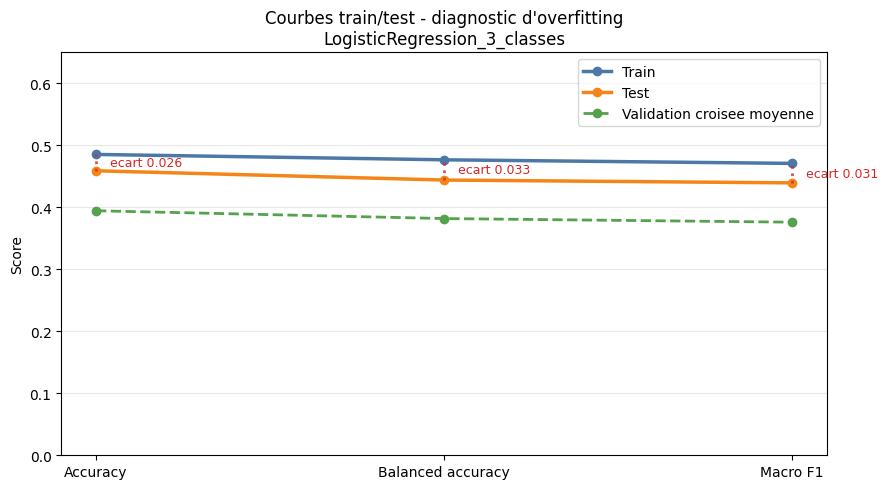

In [ ]:
best_model_name = results_post.iloc[0]["modele"]
best_post_pipeline = fitted_post[best_model_name]

train_predictions_overfit = best_post_pipeline.predict(X_train_post)
test_predictions_overfit = best_post_pipeline.predict(X_test_post)

overfitting_diagnostic = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_post, train_predictions_overfit),
        "balanced_accuracy": balanced_accuracy_score(y_train_post, train_predictions_overfit),
        "macro_f1": f1_score(y_train_post, train_predictions_overfit, average="macro"),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_post, test_predictions_overfit),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, test_predictions_overfit),
        "macro_f1": f1_score(y_test_post, test_predictions_overfit, average="macro"),
    },
    {
        "jeu": "validation_croisee_moyenne",
        "accuracy": cv_results_post["test_accuracy"].mean(),
        "balanced_accuracy": cv_results_post["test_balanced_accuracy"].mean(),
        "macro_f1": cv_results_post["test_macro_f1"].mean(),
    },
])

gap_train_test_macro_f1 = (
    overfitting_diagnostic.loc[overfitting_diagnostic["jeu"] == "train", "macro_f1"].iloc[0]
    - overfitting_diagnostic.loc[overfitting_diagnostic["jeu"] == "test", "macro_f1"].iloc[0]
)

display(overfitting_diagnostic.round(4))
print(f"Ecart macro_f1 train-test : {gap_train_test_macro_f1:.4f}")

if gap_train_test_macro_f1 > 0.15:
    print("Conclusion : risque d'overfitting eleve.")
elif gap_train_test_macro_f1 > 0.07:
    print("Conclusion : risque d'overfitting modere a surveiller.")
else:
    print("Conclusion : pas de signe fort d'overfitting sur ce diagnostic.")

# Visualisation explicite de l'ecart train/test sous forme de courbes.
# Les trois metriques sont affichees pour verifier si le train reste proche du test.
metrics_overfit = ["accuracy", "balanced_accuracy", "macro_f1"]
labels_overfit = ["Accuracy", "Balanced accuracy", "Macro F1"]

train_values_overfit = [
    overfitting_diagnostic.loc[
        overfitting_diagnostic["jeu"] == "train",
        metric,
    ].iloc[0]
    for metric in metrics_overfit
]
test_values_overfit = [
    overfitting_diagnostic.loc[
        overfitting_diagnostic["jeu"] == "test",
        metric,
    ].iloc[0]
    for metric in metrics_overfit
]
cv_values_overfit = [
    overfitting_diagnostic.loc[
        overfitting_diagnostic["jeu"] == "validation_croisee_moyenne",
        metric,
    ].iloc[0]
    for metric in metrics_overfit
]

x_positions = np.arange(len(metrics_overfit))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    x_positions,
    train_values_overfit,
    marker="o",
    linewidth=2.5,
    color="#4c78a8",
    label="Train",
)
ax.plot(
    x_positions,
    test_values_overfit,
    marker="o",
    linewidth=2.5,
    color="#f58518",
    label="Test",
)
ax.plot(
    x_positions,
    cv_values_overfit,
    marker="o",
    linestyle="--",
    linewidth=2,
    color="#54a24b",
    label="Validation croisee moyenne",
)

for x_position, train_value, test_value in zip(
    x_positions,
    train_values_overfit,
    test_values_overfit,
):
    ax.vlines(
        x=x_position,
        ymin=min(train_value, test_value),
        ymax=max(train_value, test_value),
        color="#d62728",
        linestyle=":",
        linewidth=2,
        alpha=0.8,
    )
    ax.text(
        x_position + 0.04,
        (train_value + test_value) / 2,
        f"ecart {abs(train_value - test_value):.3f}",
        color="#d62728",
        fontsize=9,
        va="center",
    )

ax.set_title(f"Courbes train/test - diagnostic d'overfitting\n{best_model_name}")
ax.set_xticks(x_positions)
ax.set_xticklabels(labels_overfit)
ax.set_ylabel("Score")
ax.set_ylim(0, max(0.65, max(train_values_overfit + test_values_overfit + cv_values_overfit) + 0.12))
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


### 11.7.1 Diagnostic d'underfitting

L'underfitting correspond a un modele trop simple ou insuffisamment informatif : il obtient des scores faibles sur le train et sur le test, avec un faible ecart entre les deux. Contrairement a l'overfitting, le probleme ne vient pas d'une memorisation du train, mais d'une capacite limitee a apprendre le signal disponible. Le diagnostic compare donc `macro_f1 train`, `macro_f1 test`, `macro_f1 validation croisee` et la baseline `Dummy`.


In [ ]:
# Diagnostic d'underfitting du modele post-voyage retenu.
# Un underfitting est suspecte si train, test et validation croisee restent faibles,
# avec un ecart train/test limite.

train_macro_f1 = overfitting_diagnostic.loc[
    overfitting_diagnostic["jeu"] == "train", "macro_f1"
].iloc[0]

test_macro_f1 = overfitting_diagnostic.loc[
    overfitting_diagnostic["jeu"] == "test", "macro_f1"
].iloc[0]

cv_macro_f1 = overfitting_diagnostic.loc[
    overfitting_diagnostic["jeu"] == "validation_croisee_moyenne", "macro_f1"
].iloc[0]

baseline_rows = results_post.loc[
    results_post["modele"].str.contains("Dummy", case=False, na=False),
    "macro_f1",
]
baseline_macro_f1 = baseline_rows.iloc[0] if not baseline_rows.empty else np.nan

gap_train_test = abs(train_macro_f1 - test_macro_f1)
gain_vs_baseline = test_macro_f1 - baseline_macro_f1 if not np.isnan(baseline_macro_f1) else np.nan

underfitting_diagnostic = pd.DataFrame([
    {
        "macro_f1_train": train_macro_f1,
        "macro_f1_test": test_macro_f1,
        "macro_f1_validation_croisee": cv_macro_f1,
        "macro_f1_baseline_dummy": baseline_macro_f1,
        "ecart_train_test": gap_train_test,
        "gain_vs_baseline": gain_vs_baseline,
    }
])

display(underfitting_diagnostic.round(4))

if train_macro_f1 < 0.45 and test_macro_f1 < 0.45 and gap_train_test < 0.05:
    print("Conclusion : risque d'underfitting. Le modele apprend peu, meme sur le train.")
elif not np.isnan(gain_vs_baseline) and gain_vs_baseline < 0.05:
    print("Conclusion : modele trop proche de la baseline, signal predictif insuffisant.")
else:
    print("Conclusion : pas de signe fort d'underfitting selon ce diagnostic.")


### 11.7.2 Interpretation du diagnostic d'underfitting

Les resultats du diagnostic montrent que le modele post-voyage retenu ne presente pas de signe fort d'underfitting. Le `macro_f1` obtenu sur le train reste proche du `macro_f1` obtenu sur le test, ce qui indique que le modele ne memorise pas excessivement le jeu d'entrainement et qu'il generalise de maniere relativement coherente sur les donnees non vues.

Le modele depasse nettement la baseline `Dummy`, ce qui confirme qu'il apprend un signal utile dans les variables disponibles. Cependant, les scores restent moderes, notamment en validation croisee. Cette limite signifie que la performance est contrainte par la qualite et le pouvoir explicatif des donnees, plus que par un modele trop simple.

Dans le contexte du projet, cette observation est coherente avec l'analyse metier : la satisfaction client depend d'evenements operationnels et subjectifs partiellement observes. Les variables post-voyage ameliorent la prediction, mais elles ne suffisent pas a expliquer parfaitement la satisfaction. Le modele doit donc etre considere comme un outil d'aide a l'analyse, et non comme une solution de decision automatique.

**Conclusion projet :** le probleme principal n'est pas un underfitting evident. Le modele apprend mieux qu'une prediction naive, mais le signal disponible reste limite. Pour progresser, il faudrait surtout enrichir les donnees avec des variables plus explicatives : qualite reelle de l'hotel, temps de trajet, duree de vol, avis detailles, niveau de service, incidents detailles, delai de resolution et contexte client.


### 11.8 Diagnostic du modele post-voyage retenu


In [ ]:
# Le diagnostic final est realise sur le meilleur modele simple,
# coherent avec le pipeline industrialise.
best_model_name = results_post.iloc[0]["modele"]
best_post_pipeline = fitted_post[best_model_name]

best_predictions = best_post_pipeline.predict(X_test_post)

labels_3_classes = [0, 1, 2]
labels_readable = ["insatisfait_1_2", "neutre_3", "satisfait_4_5"]

confusion_post = pd.DataFrame(
    confusion_matrix(y_test_post, best_predictions, labels=labels_3_classes),
    index=[f"reel_{label}" for label in labels_readable],
    columns=[f"predit_{label}" for label in labels_readable],
)

report_post = pd.DataFrame(
    classification_report(
        y_test_post,
        best_predictions,
        labels=labels_3_classes,
        target_names=labels_readable,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print("Modèle retenu pour diagnostic :", best_model_name)

Modèle retenu pour diagnostic : LogisticRegression_3_classes


### 11.9 Matrice de confusion du modele retenu

La matrice de confusion compare les classes réelles aux classes prédites.

- Les lignes correspondent aux classes réelles.
- Les colonnes correspondent aux classes prédites.
- La diagonale correspond aux bonnes prédictions.


Matrice de confusion — lignes = réel, colonnes = prédit


,predit_insatisfait_1_2,predit_neutre_3,predit_satisfait_4_5
reel_insatisfait_1_2,49,26,26
reel_neutre_3,22,16,14
reel_satisfait_4_5,15,15,35


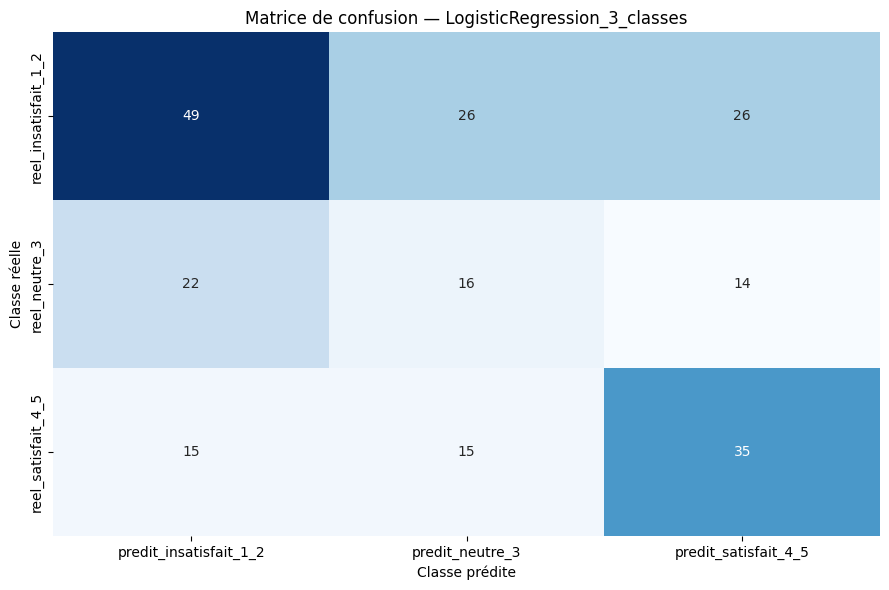

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matrice de confusion — lignes = réel, colonnes = prédit")
display(confusion_post)

plt.figure(figsize=(9, 6))
sns.heatmap(
    confusion_post,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title(f"Matrice de confusion — {best_model_name}")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

### 11.10 Rapport de classification du modele retenu


In [ ]:
display(report_post.round(4))

,precision,recall,f1-score,support
insatisfait_1_2,0.5698,0.4851,0.5241,101.0000
neutre_3,0.2807,0.3077,0.2936,52.0000
satisfait_4_5,0.4667,0.5385,0.5000,65.0000
accuracy,0.4587,0.4587,0.4587,0.4587
macro avg,0.4390,0.4438,0.4392,218.0000
weighted avg,0.4701,0.4587,0.4619,218.0000


### 11.11 Importance des variables du modele retenu


In [ ]:
if hasattr(best_post_pipeline.named_steps["model"], "feature_importances_"):
    feature_names = best_post_pipeline.named_steps["preprocess"].get_feature_names_out()
    importances = best_post_pipeline.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )
    display(importance_df.round(4))
else:
    print("Le modèle retenu ne fournit pas d'importance des variables directement exploitable.")

Le modèle retenu ne fournit pas d'importance des variables directement exploitable.


### 11.12 Tracabilite MLflow


In [ ]:
with mlflow.start_run(run_name=f"post_voyage_{best_model_name}"):
    mlflow.log_param("objectif", "post-voyage")
    mlflow.log_param("target", "satisfaction_client_3_classes")
    mlflow.log_param("modele", best_model_name)
    mlflow.log_param("nb_features", len(feature_columns_post))
    mlflow.log_param("features", ", ".join(feature_columns_post))

    best_row = results_post[results_post["modele"] == best_model_name].iloc[0]
    mlflow.log_metric("accuracy", best_row["accuracy"])
    mlflow.log_metric("balanced_accuracy", best_row["balanced_accuracy"])
    mlflow.log_metric("macro_f1", best_row["macro_f1"])

    mlflow.log_metric(
        "cv_macro_f1_mean",
        cv_summary_post.loc[cv_summary_post["metrique"] == "macro_f1", "moyenne"].iloc[0]
    )

    if "gap_train_test_macro_f1" in globals():
        mlflow.log_metric("gap_train_test_macro_f1", gap_train_test_macro_f1)

    mlflow.sklearn.log_model(best_post_pipeline, "model")

print("Run MLflow enregistre")


2026/06/17 18:19:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/17 18:19:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run MLflow enregistre



## C4. Choix du modele IA

Cette section formalise le choix du modele IA au regard des cas d'usage, des performances observees, des contraintes operationnelles et des contraintes d'eco-conception.

#### Demarche scientifique de selection

La selection du modele repose sur une demarche comparative :

1. definir clairement le cas d'usage : prediction / explication post-voyage de la satisfaction en 3 classes ;
2. nettoyer les incoherences metier avant toute separation train/test ;
3. separer les donnees en train/test avec stratification pour conserver l'equilibre des classes ;
4. comparer plusieurs familles de modeles avec les memes donnees et les memes metriques ;
5. comparer les modeles a une baseline naive `DummyClassifier` ;
6. verifier la stabilite par validation croisee ;
7. tester des ameliorations controlees : regularisation, SMOTE, XGBoost et Optuna ;
8. analyser les erreurs avec la matrice de confusion et le rapport de classification ;
9. verifier la capacite probabiliste du modele avec une analyse ROC multiclasses ;
10. documenter les limites et contraintes dans la Model Card.

#### Familles d'algorithmes considerees

| Famille | Modele teste | Interet | Contraintes / limites |
| --- | --- | --- | --- |
| Baseline naive | `DummyClassifier` | Point de comparaison minimal | Ne capture aucun signal metier |
| Modele lineaire | `LogisticRegression` | Simple, rapide, interpretable | Peut sous-performer si relations non lineaires |
| Ensemble bagging | `RandomForestClassifier` | Robuste, gere interactions non lineaires | Plus couteux qu'un modele lineaire |
| Ensemble aleatoire | `ExtraTreesClassifier` | Rapide, robuste, bon compromis performance / simplicite | Interpretabilite limitee aux importances de variables |
| Boosting | `XGBoost` | Puissant sur donnees tabulaires | Plus complexe, plus couteux, a retenir seulement si le gain est justifie |
| Reequilibrage | `SMOTE` + modeles classiques | Peut aider si classes desequilibrees | Cree des exemples artificiels, validation metier necessaire |
| Optimisation | `Optuna` + `RandomForestClassifier` | Automatise la recherche d'hyperparametres | Temps de calcul supplementaire, gain a valider hors optimisation |
| NLP pre-entraine | CamemBERT / analyse de sentiment | Exploite `retour_client` | Non retenu dans le modele principal car proche de la satisfaction et risque de fuite |

#### Type de resultat attendu

Le modele retenu produit deux types de sortie :

- une classe predite deterministe via `predict` : `insatisfait`, `neutre` ou `satisfait` ;
- des probabilites par classe via `predict_proba` lorsque le modele choisi le permet, utiles pour analyser le niveau de confiance du modele.

Dans ce projet, la sortie doit rester une aide a l'analyse qualite. Elle ne doit pas declencher automatiquement une decision commerciale individuelle.

#### Critere de decision

Le critere principal est le `macro_f1`, car il mesure mieux la performance globale lorsque les classes ne sont pas parfaitement equilibrees. L'`accuracy` et la `balanced_accuracy` restent suivies en complement.

Apres le nettoyage strict, le meilleur modele simple est celui qui arrive en tete de `results_post`. Les tests complementaires montrent que SMOTE peut ameliorer le post-voyage, mais ce choix doit etre confirme par validation croisee et validation metier avant industrialisation.

#### Contraintes operationnelles prises en compte

| Contrainte | Prise en compte |
| --- | --- |
| Sobriete technique | `n_jobs=1`, modeles tabulaires raisonnables, NLP lourd non retenu dans le modele final |
| Volume de donnees faible | Validation croisee et comparaison a une baseline pour eviter une conclusion trop optimiste |
| Besoin de reproductibilite | `random_state=42`, notebook final centralise, MLflow pour tracer les runs |
| Besoin de tracabilite | Model Card, MLflow, matrices de confusion, rapports de classification |
| Besoin metier | Separation stricte entre objectif pre-voyage et post-voyage |
| Passage en production | Export pipeline et API a traiter dans l'etape d'industrialisation |

#### Eco-conception

Les contraintes d'eco-conception sont portees a connaissance dans ce notebook :

- eviter les modeles lourds lorsque le gain de performance est faible ;
- limiter les hyperparametres des modeles principaux ;
- utiliser `n_jobs=1` pour eviter une consommation excessive sur une machine limitee ;
- ne pas retenir le NLP lourd dans le modele principal si le signal cree une fuite de donnees ;
- comparer les ameliorations avancees au modele simple avant de les retenir ;
- documenter le temps d'inference et la complexite du modele retenu.

#### Conclusion

Le choix du modele reste fonde sur la comparaison empirique, pas sur un algorithme impose. Le modele simple retenu est celui qui maximise le `macro_f1` dans `results_post`. SMOTE post-voyage devient un candidat d'amelioration, mais il n'est pas automatiquement industrialise sans validation complementaire.




,metrique,valeur,interpretation
0,roc_auc_ovr_macro,0.6110,Moyenne non ponderee des AUC par classe
1,roc_auc_ovr_weighted,0.6165,Moyenne ponderee par le support des classes
2,roc_auc_insatisfait_1_2,0.6156,AUC one-vs-rest de la classe
3,roc_auc_neutre_3,0.5315,AUC one-vs-rest de la classe
4,roc_auc_satisfait_4_5,0.6858,AUC one-vs-rest de la classe


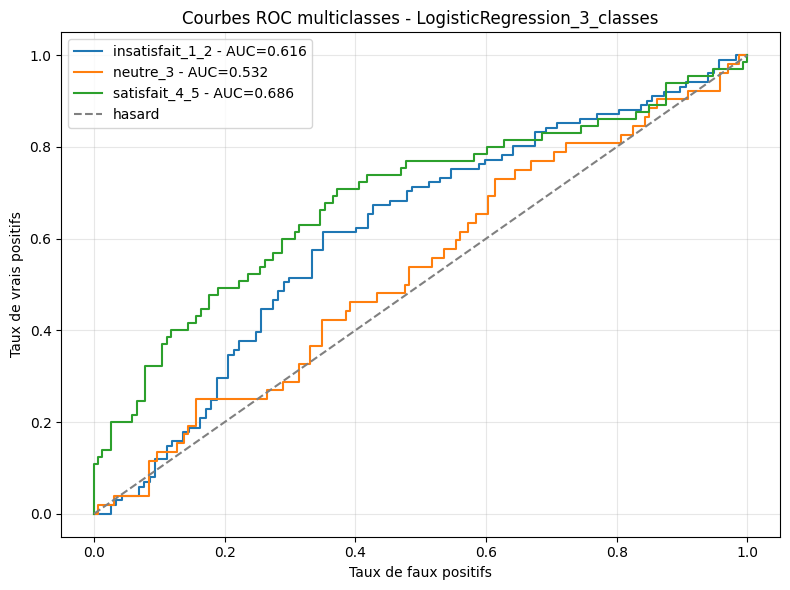

,indicateur,valeur,interpretation
0,nb_lignes_test,218.000000,Volume utilise pour mesurer l'inference
1,temps_inference_total_secondes,0.006650,Temps total de prediction sur le jeu de test
2,temps_inference_moyen_ms_ligne,0.030505,Temps moyen de prediction par ligne
3,cv_fit_time_moyen_secondes,0.031259,Temps moyen d'entrainement observe en validati...
4,cv_score_time_moyen_secondes,0.008037,Temps moyen d'evaluation observe en validation...


In [ ]:
import time

from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Analyse ROC multiclasses du modele post-voyage retenu.
# Le ROC complete accuracy / macro_f1 en evaluant la separation probabiliste des classes.
if hasattr(best_post_pipeline, "predict_proba"):
    y_score_post = best_post_pipeline.predict_proba(X_test_post)
    y_test_binarized = label_binarize(y_test_post, classes=labels_3_classes)

    roc_auc_macro_ovr = roc_auc_score(
        y_test_post,
        y_score_post,
        multi_class="ovr",
        average="macro",
    )
    roc_auc_weighted_ovr = roc_auc_score(
        y_test_post,
        y_score_post,
        multi_class="ovr",
        average="weighted",
    )

    roc_rows = [
        {
            "metrique": "roc_auc_ovr_macro",
            "valeur": roc_auc_macro_ovr,
            "interpretation": "Moyenne non ponderee des AUC par classe",
        },
        {
            "metrique": "roc_auc_ovr_weighted",
            "valeur": roc_auc_weighted_ovr,
            "interpretation": "Moyenne ponderee par le support des classes",
        },
    ]

    for class_index, class_label in enumerate(labels_3_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, class_index], y_score_post[:, class_index])
        roc_rows.append({
            "metrique": f"roc_auc_{labels_readable[class_index]}",
            "valeur": auc(fpr, tpr),
            "interpretation": "AUC one-vs-rest de la classe",
        })

    roc_auc_post = pd.DataFrame(roc_rows)
    display(roc_auc_post.round(4))

    plt.figure(figsize=(8, 6))
    for class_index, class_label in enumerate(labels_3_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, class_index], y_score_post[:, class_index])
        plt.plot(
            fpr,
            tpr,
            label=f"{labels_readable[class_index]} - AUC={auc(fpr, tpr):.3f}",
        )

    plt.plot([0, 1], [0, 1], "--", color="gray", label="hasard")
    plt.title(f"Courbes ROC multiclasses - {best_model_name}")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Le modele retenu ne fournit pas predict_proba : ROC AUC non calculable.")

# Mesure simple du temps d'inference sur le jeu de test.
start_time = time.perf_counter()
_ = best_post_pipeline.predict(X_test_post)
inference_time_seconds = time.perf_counter() - start_time

performance_operationnelle_post = pd.DataFrame([
    {
        "indicateur": "nb_lignes_test",
        "valeur": len(X_test_post),
        "interpretation": "Volume utilise pour mesurer l'inference",
    },
    {
        "indicateur": "temps_inference_total_secondes",
        "valeur": inference_time_seconds,
        "interpretation": "Temps total de prediction sur le jeu de test",
    },
    {
        "indicateur": "temps_inference_moyen_ms_ligne",
        "valeur": inference_time_seconds / len(X_test_post) * 1000,
        "interpretation": "Temps moyen de prediction par ligne",
    },
    {
        "indicateur": "cv_fit_time_moyen_secondes",
        "valeur": cv_results_post["fit_time"].mean(),
        "interpretation": "Temps moyen d'entrainement observe en validation croisee",
    },
    {
        "indicateur": "cv_score_time_moyen_secondes",
        "valeur": cv_results_post["score_time"].mean(),
        "interpretation": "Temps moyen d'evaluation observe en validation croisee",
    },
])

display(performance_operationnelle_post.round(6))



## C5. Entrainement supervise du modele IA

#### Methode d'entrainement retenue

| Element | Choix dans le projet | Justification |
| --- | --- | --- |
| Type d'apprentissage | Apprentissage supervise | La cible `satisfaction_client` est connue dans l'historique des sejours |
| Probleme IA | Classification multiclasses | Le modele post-voyage predit 3 classes : insatisfait, neutre, satisfait |
| Donnees d'entree | `X_post` | Variables pre-voyage + variables operationnelles post-voyage autorisees |
| Donnee cible | `y_post` | `satisfaction_client` regroupee en 3 classes |
| Split | Train/test stratifie 80/20 | Conserve la distribution des classes dans train et test |
| Pipeline | Pretraitement + modele dans `Pipeline` sklearn | Evite la fuite de donnees entre train et test pour imputation, traitement IQR des outliers, encodage et standardisation |
| Comparaison | Plusieurs modeles entraines automatiquement dans une boucle | Permet de comparer objectivement les familles d'algorithmes |
| Validation | Test set + validation croisee | Verifie la performance sur un jeu non vu et la stabilite du modele |

#### Optimisations testees

| Optimisation testee | Objectif | Decision actuelle |
| --- | --- | --- |
| `class_weight="balanced"` | Limiter l'effet du desequilibre des classes | Utilise dans les modeles compatibles |
| RandomForest regularise | Reduire l'overfitting par une profondeur faible et des feuilles plus larges | Conserve comme experience anti-overfitting |
| SMOTE pre-voyage | Tester un reequilibrage artificiel sur la cible 3 classes | Non retenu automatiquement : le gain observe apres simplification reste faible et doit etre valide |
| SMOTE post-voyage | Tester un reequilibrage artificiel sur un probleme contenant plus de signal | Candidat d'amelioration, a confirmer avant industrialisation |
| Optuna anti-overfitting | Automatiser la recherche d'hyperparametres avec penalite sur l'ecart train/validation et la complexite | Teste comme controle methodologique |
| XGBoost optimise | Tester une famille boosting performante sur tabulaire | Teste, a retenir uniquement si le gain justifie la complexite |
| NLP pre-entraine | Exploiter `retour_client` | Non retenu dans le modele principal pour eviter une fuite directe du ressenti client |

#### Reentrainement et transfert de connaissances

| Entrainement | Application dans ce projet |
| --- | --- |
| Modele entraine | Oui : les modeles sont entraines avec `.fit()` sur `X_train_post`, `y_train_post` via un pipeline supervise |
| Modele reentraine | Oui pour les experimentations : chaque modele compare ou teste est reentraine sur le meme jeu train |
| Reentrainement futur | Prevu lorsque de nouvelles donnees ou de nouvelles regles de nettoyage seront validees |
| Transfert de connaissances | Non applicable au modele principal tabulaire : les modeles sklearn ne transferent pas de poids d'un modele a l'autre |
| Transfert via modele pre-entraine | Teste conceptuellement avec NLP / modele de sentiment, mais non retenu dans le modele principal en raison du risque de fuite de donnees |

#### Feature engineering mobilise pour l'entrainement

Le feature engineering est utilise pour transformer des valeurs brutes en signaux metier plus exploitables :

- `budget_par_jour` : budget ramene a la duree du sejour ;
- `part_vol_budget` : poids du vol dans le budget total ;
- `sejour_long` : indicateur de sejour long ;
- `meteo_risque` : indicateur de meteo potentiellement defavorable ;
- `hebergement_luxe` : indicateur derive du type d'hebergement ;
- `destination_luxe` et `distance_vol_categorie` : enrichissement simple de la destination ;
- `imprevu_present`, `imprevu_transport`, `imprevu_meteo`, `budget_non_respecte`, `gravite_imprevu` : variables post-voyage explicatives reservees au modele post-voyage.

Les variables derivees reduisent la dependance a certaines valeurs brutes et rendent le dataset plus pertinent pour le cas d'usage metier. Les variables non retenues ou trop artificielles sont supprimees avant la modelisation.

#### Conclusion

Les modeles sont entraines automatiquement et superviseement, compares avec des indicateurs adaptes, optimises de maniere proportionnee au contexte, puis documentes avec leurs hyperparametres. Le reentrainement continu et l'export industriel du pipeline restent des etapes futures d'industrialisation.



In [ ]:
def extraire_hyperparametres_modele(model) -> dict:
    params = model.get_params()
    hyperparametres_utiles = [
        "strategy",
        "max_iter",
        "class_weight",
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "random_state",
        "n_jobs",
    ]
    return {key: params.get(key) for key in hyperparametres_utiles if key in params}


resume_entrainement_post = pd.DataFrame([
    {
        "element": "type_apprentissage",
        "valeur": "supervise",
    },
    {
        "element": "probleme",
        "valeur": "classification multiclasses 3 classes",
    },
    {
        "element": "taille_train",
        "valeur": len(X_train_post),
    },
    {
        "element": "taille_test",
        "valeur": len(X_test_post),
    },
    {
        "element": "nb_features_post",
        "valeur": len(feature_columns_post),
    },
    {
        "element": "modele_retenu",
        "valeur": best_model_name,
    },
])

display(resume_entrainement_post)

hyperparametres_modeles_post = pd.DataFrame([
    {
        "modele": model_name,
        "hyperparametres": extraire_hyperparametres_modele(model),
    }
    for model_name, model in modeles_post.items()
])

display(hyperparametres_modeles_post)

if "comparison_post" in globals():
    print("Comparaison incluant les tests complementaires :")
    display(comparison_post.round(4))
else:
    print("Comparaison des modeles principaux :")
    display(results_post.round(4))


,element,valeur
0,type_apprentissage,supervise
1,probleme,classification multiclasses 3 classes
2,taille_train,870
3,taille_test,218
4,nb_features_post,27
5,modele_retenu,LogisticRegression_3_classes


,modele,hyperparametres
0,Dummy_majority_3_classes,"{'strategy': 'most_frequent', 'random_state': ..."
1,LogisticRegression_3_classes,"{'max_iter': 500, 'class_weight': 'balanced', ..."
2,RandomForest_regularise_3_classes,"{'class_weight': 'balanced', 'n_estimators': 1..."
3,RandomForest_Optuna_regularise_3_classes,"{'class_weight': 'balanced', 'n_estimators': 8..."


Comparaison incluant les tests complementaires :


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_3_classes_optimise_500,0.5000,0.4517,0.4451
1,RandomForest_3_classes_SMOTE,0.5092,0.4473,0.4414
2,LogisticRegression_3_classes,0.4587,0.4438,0.4392
3,ExtraTrees_3_classes_SMOTE,0.5000,0.4327,0.4242
4,LogisticRegression_3_classes_SMOTE,0.4495,0.4278,0.4236
5,RandomForest_regularise_3_classes,0.5459,0.4635,0.4152
6,XGBoost_3_classes_optimise,0.4312,0.3782,0.3709
7,Dummy_majority_3_classes,0.4633,0.3333,0.2111


## C6. Implementation et integration technique

Cette section documente la phase d'industrialisation du modèle **pré-voyage**. L'objectif est de passer d'un notebook d'expérimentation à une première chaîne exploitable : entraînement reproductible, export du pipeline, API de prédiction, logs, monitoring, détection de dérive et stratégie de réentraînement.

#### Schéma visuel de l'architecture

![Architecture d'industrialisation](../docs/architecture_industrialisation.svg)

#### Architecture fonctionnelle

```text
[Dataset brut CSV]
        |
        v
[train.py]
        |
        +--> [Nettoyage métier]
        +--> [Feature engineering pré-voyage]
        +--> [Pipeline sklearn : imputation + outliers + encodage + normalisation + modèle]
        |
        v
[Artefacts models/]
        |
        +--> model_pre_voyage.pkl
        +--> model_pre_voyage_metadata.json
        |
        v
[API FastAPI]
        |
        +--> /health
        +--> /predict
        +--> /monitoring/summary
        +--> /monitoring/drift
        +--> /monitoring/alerts
        |
        v
[Logs JSONL]
        |
        v
[Monitoring + alertes + stratégie de réentraînement]
```

#### Fichiers créés ou modifiés pour l'industrialisation

| Fichier / dossier | Rôle | Contenu principal | Statut |
| --- | --- | --- | --- |
| `train.py` | Script d'entraînement reproductible | Charge le CSV, prépare `X/y`, entraîne les modèles candidats, sélectionne le meilleur modèle pré-voyage et exporte les artefacts | En place |
| `app/modeling.py` | Logique ML centralisée | Nettoyage métier, feature engineering, pipeline sklearn, choix des modèles, export modèle, profil de référence d'entraînement | En place |
| `app/schemas.py` | Contrat API | Schémas Pydantic d'entrée `/predict` et de sortie de prédiction | En place |
| `app/predictor.py` | Service de prédiction | Charge `models/model_pre_voyage.pkl`, prépare les features d'inférence et retourne classe + probabilités | En place |
| `app/main.py` | API FastAPI | Endpoints `/health`, `/predict`, `/monitoring/summary`, `/monitoring/drift`, `/monitoring/alerts` | En place |
| `app/monitoring.py` | Monitoring opérationnel | Logs JSONL, résumé monitoring, dérive, alertes et décision de réentraînement | En place |
| `tests/test_health.py` | Tests API | Vérifie `/health`, `/predict`, `/monitoring/summary`, `/monitoring/drift`, `/monitoring/alerts` | En place |
| `tests/test_modeling.py` | Tests ML | Vérifie le regroupement cible, les features pré-voyage, l'entraînement et le profil de référence | En place |
| `tests/test_monitoring.py` | Tests monitoring | Vérifie logs JSONL, résumé, dérive et règles d'alertes | En place |
| `docs/architecture_industrialisation.svg` | Schéma visuel | Représentation graphique du flux données → modèle → API → monitoring → réentraînement | En place |
| `docs/strategie_reentrainement.md` | Documentation de gouvernance | Seuils, décisions, conditions et processus de réentraînement | En place |
| `docker-compose.yml` | Exécution conteneurisée | Expose l'API sur `8001`, monte `./models` et `./logs` | En place |
| `Dockerfile` | Image API | Installe les dépendances et lance FastAPI avec Uvicorn | En place |
| `.github/workflows/ci-cd.yml` | CI/CD | Compile Python, lance les tests, valide le notebook et construit l'image Docker | En place |
| `README.md` | Documentation d'utilisation | Commandes locales, URLs, test API, monitoring et Docker | En place |

#### Artefacts générés localement

| Artefact | Généré par | Rôle | Versioning Git |
| --- | --- | --- | --- |
| `models/model_pre_voyage.pkl` | `python train.py` | Pipeline sklearn complet utilisé par l'API `/predict` | Non versionné, ignoré par `.gitignore` |
| `models/model_pre_voyage_metadata.json` | `python train.py` | Métadonnées : modèle retenu, métriques, features, classes, profil d'entraînement | Non versionné, ignoré par `.gitignore` |
| `logs/predictions/predictions.jsonl` | Appels `/predict` | Journal des prédictions, probabilités, confiance et entrées utilisateur | Non versionné, ignoré par `.gitignore` |
| `logs/codecarbon/` | Cellule CodeCarbon du notebook | Estimation d'empreinte carbone d'un entraînement | Non versionné, ignoré par `.gitignore` |
| `mlruns/`, `mlartifacts/`, `mlflow.db` | MLflow local | Traçabilité locale des expériences | Non versionné, ignoré par `.gitignore` |

#### Modéle industrialisé

| élément | Valeur |
| --- | --- |
| Objectif | Prédiction pré-voyage de la satisfaction client en 3 classes |
| Modéle exporté actuellement | `LogisticRegression_pre` |
| Cible | `satisfaction_client` regroupée en `insatisfait_1_2`, `neutre_3`, `satisfait_4_5` |
| Variables autorisées | Variables connues avant le séjour : profil client, budget, destination, saison, durée, hébergement, prix du vol, météo prévue, activité principale et features dérivées pré-voyage |
| Variables exclues | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` et features post-voyage dérivées |
| Raison de l'exclusion | Ces variables sont connues pendant ou après le séjour et créeraient une fuite de données pour un usage pré-voyage |
| Usage recommandé | Score indicatif d'aide à l'analyse, avec revue humaine |
| Usage interdit | Décision automatique individualisée sans validation humaine |

#### Endpoints locaux disponibles

| URL locale | Méthode | Rôle | Résultat attendu |
| --- | --- | --- | --- |
| `http://localhost:8001/health` | `GET` | Vérifier que l'API est démarrée | `{"status": "ok"}` |
| `http://localhost:8001/docs` | `GET` | Documentation Swagger interactive | Interface de test API |
| `http://localhost:8001/predict` | `POST` | Prédire la classe de satisfaction pré-voyage | Classe prédite, libellé, probabilités, métriques modèle |
| `http://localhost:8001/monitoring/summary` | `GET` | Résumer les prédictions journalisées | Volume, distribution, confiance moyenne, taux faible confiance |
| `http://localhost:8001/monitoring/drift` | `GET` | Comparer les entrées API au profil d'entraînement | Dérives numériques/catégorielles et alertes par variable |
| `http://localhost:8001/monitoring/alerts` | `GET` | Consolider monitoring + dérive en décision opérationnelle | `collect_predictions`, `monitor_and_review`, `review_and_prepare_retraining` ou `no_action` |

#### Commandes locales principales

| Action | Commande PowerShell | Objectif |
| --- | --- | --- |
| Activer l'environnement | `.\.venv\Scripts\Activate.ps1` | Utiliser les dépendances du projet |
| Installer les dépendances | `pip install -r requirements-dev.txt` | Préparer l'environnement local |
| Entraîner/exporter le modèle | `python train.py` | Générer `models/model_pre_voyage.pkl` et les métadonnées |
| Lancer l'API | `uvicorn app.main:app --reload --port 8001` | Servir l'API en local |
| Lancer les tests | `python -m pytest -q` | Vérifier API, pipeline et monitoring |
| Lire les logs | `Get-Content -Encoding UTF8 logs/predictions/predictions.jsonl -Tail 5` | Consulter les dernières prédictions |
| Lancer Docker | `docker compose up --build` | Démarrer l'API dans un conteneur |

#### Exemple de requête `/predict`

```json
{
  "client_type": "couple",
  "budget_total": 4200,
  "destination": "rome",
  "saison": "printemps",
  "duree_jours": 7,
  "type_hebergement": "hôtel",
  "prix_vol": 650,
  "meteo_prevue": "ensoleillé",
  "activite_principale": "culture"
}
```

#### Exemple de réponse `/predict`

```json
{
  "objective": "pre_voyage_satisfaction_3_classes",
  "model_name": "LogisticRegression_pre",
  "classe_predite": 2,
  "libelle_prediction": "satisfait_4_5",
  "probabilities": [
    {"classe": 0, "libelle": "insatisfait_1_2", "probabilite": 0.3815},
    {"classe": 1, "libelle": "neutre_3", "probabilite": 0.2138},
    {"classe": 2, "libelle": "satisfait_4_5", "probabilite": 0.4048}
  ],
  "model_metrics": {
    "accuracy": 0.3571,
    "balanced_accuracy": 0.3554,
    "macro_f1": 0.3491
  }
}
```

#### Contenu des logs de prédiction

Chaque appel réussi à `/predict` ajoute une ligne JSON dans `logs/predictions/predictions.jsonl`.

| Champ loggé | Signification |
| --- | --- |
| `timestamp_utc` | Date/heure de la prédiction |
| `objective` | Objectif du modèle servi |
| `model_name` | Modéle utilisé |
| `input` | Données pré-voyage envoyées à l'API |
| `classe_predite` | Classe numérique prédite |
| `libelle_prediction` | Libellé métier de la classe prédite |
| `probabilities` | Probabilités associées aux classes |
| `confidence` | Probabilité maximale parmi les classes |
| `low_confidence` | `true` si la confiance est inférieure à `0.50` |
| `model_metrics` | Métriques globales connues au moment de l'export |

#### Monitoring et alertes

| Endpoint | Indicateurs retournés | Utilisation métier |
| --- | --- | --- |
| `/monitoring/summary` | Nombre de prédictions, distribution des classes, taux de faible confiance, confiance moyenne | Vérifier le comportement global du modèle servi |
| `/monitoring/drift` | écart des variables numériques et catégorielles par rapport au profil d'entraînement | Détecter un changement de population ou de contexte d'usage |
| `/monitoring/alerts` | Décision opérationnelle et recommandations | Savoir s'il faut collecter plus de données, surveiller, revoir humainement ou préparer un réentraînement |

#### Seuils d'alerte retenus

| Indicateur | Warning | Critical | Action |
| --- | ---: | ---: | --- |
| Volume de prédictions | `< 20` | Non applicable | Ne pas conclure, collecter davantage de logs |
| Faible confiance | `>= 40 %` | `>= 60 %` | Revue humaine des prédictions |
| Dérive numérique | écart moyen normalisé `>= 1.0` | `>= 2.0` | Analyser la variable concernée |
| Dérive catégorielle | Distance de distribution `>= 0.20` | `>= 0.35` | Analyser le segment surreprésenté |

#### Décisions possibles de `/monitoring/alerts`

| Décision | Signification | Action recommandée |
| --- | --- | --- |
| `collect_predictions` | Aucun log disponible | Générer des appels `/predict` avant analyse |
| `monitor_and_review` | Alerte ou volume insuffisant | Continuer la collecte et faire une revue humaine |
| `review_and_prepare_retraining` | Alerte critique avec volume suffisant | Préparer un réentraînement après validation métier |
| `no_action` | Pas d'alerte significative | Continuer le suivi périodique |

#### CI/CD et validation continue

| étape CI/CD | Rôle |
| --- | --- |
| `python -m compileall app tests train.py` | Vérifier la syntaxe Python |
| `pytest -q` | Lancer les tests API, ML et monitoring |
| Validation notebook | Parser les cellules code du notebook final avec `ast` |
| Build Docker | Vérifier que l'image API peut être construite |

#### Conteneurisation Docker

| élément | Rôle |
| --- | --- |
| `Dockerfile` | Construit l'image Python/FastAPI |
| `docker-compose.yml` | Lance le service API sur le port local `8001` |
| Volume `./models:/app/models:ro` | Rend le modèle exporté disponible dans le conteneur en lecture seule |
| Volume `./logs:/app/logs` | Conserve les logs de prédiction hors du conteneur |

Avant de lancer Docker, il faut générer le modèle localement :

```powershell
python train.py
docker compose up --build
```

#### Limites actuelles de l'industrialisation

- Le modèle pré-voyage a une performance modeste ; il doit rester un outil d'aide à l'analyse.
- Le suivi de performance réelle nécessite des retours clients post-séjour avec satisfaction observée.
- Le réentraînement n'est pas automatique : il doit passer par une revue métier et une validation des nouvelles données.
- Les artefacts `models/`, `logs/` et `mlruns/` sont locaux et non versionnés.
- Les alertes de dérive sont peu fiables tant que le volume de prédictions journalisées est faible.


## C7. Evaluation de l architecture cible

Cette section complete l'industrialisation en evaluant la pertinence de l'architecture cible. Elle couvre les scenarios possibles, les contraintes techniques et economiques, les acteurs ressources a consulter et la decision d'architecture retenue pour le projet.

#### Objectif de l'evaluation d'architecture

L'objectif n'est pas uniquement de faire fonctionner le modele. Il faut choisir une architecture adaptee au contexte du projet : agence de voyages haut de gamme, modele pre-voyage a performance modeste, besoin de demonstration, supervision humaine obligatoire, budget maitrise et possibilite d'evolution progressive.

#### Scenarios d'architecture etudies

| Scenario | Description | Avantages | Contraintes / limites | Pertinence pour le projet |
| --- | --- | --- | --- | --- |
| Notebook seul | Utilisation du notebook final pour tester le modele | Simple, rapide, faible cout | Non utilisable facilement par un profil metier, pas d'API, pas de monitoring reel | Adapte uniquement a l'experimentation |
| Script local `train.py` | Entrainement reproductible en ligne de commande | Reproductible, simple, tracable | Necessite Python et l'environnement projet | Pertinent pour figer l'entrainement |
| API FastAPI locale | Exposition du modele via `/predict` | Separe modele et usage, testable via Swagger | Reste local, necessite le modele exporte | Tres pertinent pour prototype industrialisable |
| API + Docker local | Execution reproductible dans un conteneur | Portabilite, isolation, proche production | Necessite Docker, gestion des volumes `models/` et `logs/` | Pertinent pour demonstration et passage sur autre poste |
| Interface Streamlit locale | Interface web de test metier et dashboard KPI | Simple pour saisir un voyage, tester un CSV et suivre les KPI metier | Interface de demonstration, pas concue pour forte charge | Tres pertinent pour validation metier |
| Serveur VPS | Deploiement sur serveur Linux avec Docker | Accessible a distance, cout previsible | Administration serveur, securite, sauvegardes, supervision | Option pertinente apres validation metier |
| Cloud manage | Deploiement sur service cloud type Azure, AWS ou GCP | Scalabilite, supervision avancee, services manages | Cout plus eleve, configuration plus complexe, dependance fournisseur | Non prioritaire pour ce prototype |
| Architecture MLOps complete | Registry modele, orchestration, monitoring avance, reentrainement automatise | Robuste pour production reelle | Surdimensionne, couteux, necessite une equipe technique | A envisager uniquement en cas de passage a l'echelle |

#### Contraintes techniques identifiees

| Contrainte | Impact sur l'architecture | Decision retenue |
| --- | --- | --- |
| Sobriete et maintenabilite | Eviter les modeles lourds et les traitements couteux | Modeles scikit-learn legers, pas de modele NLP lourd en production pre-voyage |
| Performance modeste du modele pre-voyage | Ne pas automatiser une decision client | Usage comme aide a l'analyse avec supervision humaine |
| Variables post-voyage indisponibles avant depart | Risque de fuite de donnees | Exclusion stricte de `imprevus`, `respect_budget`, `reorganisation_necessaire`, `retour_client` |
| Artefacts locaux non versionnes | Le modele doit etre regenere sur un autre poste | `python train.py` regenere `models/model_pre_voyage.pkl` |
| Besoin de demonstration metier | Les utilisateurs non techniques doivent pouvoir tester et lire les KPI | Interface Streamlit locale avec dashboard KPI |
| Besoin de tracabilite | Les predictions doivent etre auditables | Logs JSONL et endpoints de monitoring |
| Besoin de portabilite | Le projet doit fonctionner sur un autre PC | GitHub, `requirements-dev.txt`, Docker Compose |
| Donnees synthetiques | Generalisation limitee | Documentation des limites et validation metier avant donnees reelles |

#### Contraintes economiques des scenarios

| Scenario | Cout estimatif | Couts caches / vigilance | Lecture economique |
| --- | ---: | --- | --- |
| Notebook local | Quasi nul | Temps manuel, dependance au profil technique | Acceptable pour exploration uniquement |
| API locale + Streamlit | Quasi nul | Installation Python, maintenance locale | Meilleur compromis pour prototype et demonstration |
| Docker local | Quasi nul si Docker Desktop disponible | Configuration Docker, ressources machine | Pertinent pour reproductibilite |
| VPS simple | Environ 5 a 20 euros par mois | Securite, sauvegardes, mises a jour, nom de domaine eventuel | Pertinent si acces distant necessaire |
| Cloud manage | Variable, souvent superieur au VPS | Monitoring, stockage, reseau, logs, services manages | A reserver a un besoin de production reelle |
| MLOps complet | Cout technique et humain eleve | Registry, orchestration, observabilite, gouvernance | Non proportionne au stade actuel |

Les contraintes economiques doivent etre presentees au commanditaire avant tout passage a une architecture distante. Pour ce projet, le meilleur rapport valeur / cout est l'architecture locale : API FastAPI + Streamlit + Docker optionnel.

#### Acteurs ressources a consulter

| Acteur | Questions a poser | Decision attendue |
| --- | --- | --- |
| Commanditaire metier | Usage reel attendu : aide conseiller, scoring interne, comparaison d'offres | Valider que le modele reste un outil d'aide, pas une decision automatique |
| Conseillers voyage | Les champs d'entree correspondent-ils au processus de vente | Ajuster formulaire, libelles et seuils de confiance |
| Acteur technique / DSI | Ou heberger l'API, quel niveau de securite et de disponibilite | Choisir local, serveur interne, VPS ou cloud |
| Juriste / DPO | Impact RGPD si donnees clients reelles, duree de conservation, information client | Valider la conformite avant donnees reelles |
| Responsable financier | Budget disponible pour hebergement, maintenance et monitoring | Arbitrer entre prototype local, VPS ou cloud manage |
| Responsable qualite / direction | KPI a suivre : satisfaction, faible confiance, derive, retours conseiller | Valider les indicateurs et seuils d'alerte |

#### Questions a valider avant generalisation

| Theme | Question | Statut actuel |
| --- | --- | --- |
| Usage metier | Le modele doit-il recommander, alerter ou seulement informer | A valider avec le commanditaire |
| Performance attendue | Niveau minimum acceptable de `macro_f1`, `balanced_accuracy` ou confiance | Non valide, modele actuel modeste |
| Donnees reelles | Le dataset synthetique sera-t-il remplace par des historiques clients | A confirmer |
| Securite | L'API sera-t-elle exposee hors poste local | Non retenu a ce stade |
| Cout | Un budget serveur mensuel est-il disponible | Non necessaire pour prototype local |
| Maintenance | Qui relance `train.py`, surveille les logs et valide les alertes | A attribuer avant production |
| Gouvernance | Qui autorise le remplacement d'un modele par une nouvelle version | A formaliser |

#### Architecture cible retenue pour le projet actuel

L'architecture retenue est volontairement progressive :

```text
Notebook final documente
        + train.py reproductible
        + modele pre-voyage exporte
        + API FastAPI locale
        + interface Streamlit locale
        + Docker Compose optionnel
        + logs JSONL
        + monitoring / derive / alertes
```

Cette architecture est pertinente car elle :

- repond au besoin de demonstration et de test metier ;
- reste economiquement legere ;
- fonctionne sur un poste local ou un autre PC via GitHub ;
- evite de surdimensionner le projet avec du cloud ou du MLOps complet ;
- permet une evolution future vers serveur ou cloud si le commanditaire valide l'interet metier ;
- tient compte des limites du modele pre-voyage en imposant une supervision humaine.

#### Decision C7

La competence C7 est couverte pour le perimetre prototype / certification : les principales architectures possibles sont comparees, leurs contraintes techniques et economiques sont explicitees, les acteurs a consulter sont identifies, et une architecture cible proportionnee est retenue.

Avant une generalisation reelle, il restera necessaire d'interroger formellement le commanditaire, les utilisateurs metier, la DSI et le DPO afin de confirmer les contraintes de performance, securite, cout, maintenance et conformite.



## C8. Mesure de performance et impacts de la solution IA

Cette section regroupe les preuves liees a la mesure de performance et aux impacts de la solution IA. Elle s'appuie sur les resultats de modelisation, le monitoring API, la Model Card, CodeCarbon et les mesures ethiques.

#### Indicateurs et seuils definis

| Famille | Indicateur | Seuil ou interpretation | Preuve |
| --- | --- | --- | --- |
| Performance globale | `accuracy` | Score secondaire, a interpreter avec prudence si classes desequilibrees | Resultats pre-voyage et post-voyage |
| Performance equilibree | `balanced_accuracy` | Doit etre superieur au modele naif | Comparaisons de modeles |
| Robustesse multi-classes | `macro_f1` | Indicateur principal car les classes sont desequilibrees | Validation croisee, rapports de classification |
| Diagnostic erreurs | Matrice de confusion | Identifier les classes confondues | Matrice du modele retenu |
| Robustesse | Validation croisee | Comparer score moyen et dispersion | Sections validation croisee |
| Suivi operationnel | `low_confidence_rate` | Alerte si beaucoup de predictions peu confiantes | `/monitoring/summary`, `/monitoring/alerts` |
| Derive donnees | `numeric_drift`, `categorical_drift` | Warning / critical selon seuils de monitoring | `/monitoring/drift` |
| Impact environnemental | CO2e estime | Mesure indicative de sobriete numerique | Section CodeCarbon |
| Impact societal | Ecarts par sous-groupes | Signal d'alerte, pas preuve automatique de discrimination | Mesures ethiques et societales |

#### Suivi et presentation aux interlocuteurs

| Interlocuteur | Information presentee | Objectif |
| --- | --- | --- |
| Commanditaire | Scores, limites, comparaison pre-voyage / post-voyage | Decider si le modele est utilisable comme aide a l'analyse |
| Conseillers voyage | Prediction, probabilites, faible confiance | Savoir quand relire manuellement la recommandation |
| Equipe data / technique | Logs, derive, erreurs, quality gate | Maintenir le modele et eviter les regressions |
| DPO / juridique | RGPD, biais, usage non decisionnel | Verifier la conformite et les risques |
| Direction / finance | Cout, architecture, empreinte carbone | Arbitrer entre prototype, Docker, serveur ou MLOps complet |

#### Actions declenchees selon les indicateurs

| Signal observe | Action |
| --- | --- |
| `macro_f1` sous le seuil CI/CD | Bloquer la livraison et analyser la regression |
| Taux eleve de faible confiance | Revue humaine des predictions concernees |
| Derive critique confirmee | Preparer un reentrainement apres validation metier |
| Performance faible sur un sous-groupe | Examiner representativite et erreurs de ce segment |
| Empreinte carbone excessive | Limiter les experimentations lourdes et privilegier modeles tabulaires simples |

#### Limite de mesure

La performance reelle en exploitation ne pourra etre confirmee qu'avec de nouvelles donnees annotees apres sejour. Le monitoring actuel mesure les predictions, la confiance et la derive des entrees ; il ne remplace pas une mesure future de satisfaction client observee.




### C8.1 Model Card - fiche du modele retenu

Cette fiche documente le modele post-voyage retenu pour la suite du projet. Elle doit etre mise a jour a chaque changement de donnees, de variables, d'algorithme ou d'hyperparametres.

### Details du modele

| Element | Description |
| --- | --- |
| Objectif | Predire / expliquer la satisfaction client apres sejour en 3 classes |
| Cible | `satisfaction_client` regroupee en `0 = insatisfait`, `1 = neutre`, `2 = satisfait` |
| Selection du modele | Meilleur modele selon `macro_f1` dans `results_post`, apres nettoyage strict |
| Pretraitement | Imputation, remplacement IQR des outliers numeriques continus, encodage OneHot des variables categorielles et standardisation via `ColumnTransformer` |
| Variables utilisees | Variables pre-voyage + variables post-voyage explicatives (`imprevus`, `reorganisation_necessaire`, `respect_budget`) |
| Variables exclues | `trip_id`, `satisfaction_client`, `retour_client` brut |
| Split d'evaluation | Train/test stratifie, 80 % entrainement et 20 % test |
| Validation complementaire | Validation croisee a 3 plis, matrice de confusion, rapport de classification, ROC multiclasses si `predict_proba` disponible |

### Architecture et hyperparametres

L'architecture retenue est un pipeline `scikit-learn` :

1. `ColumnTransformer` pour separer variables numeriques et categorielles ;
2. imputation, remplacement IQR des outliers continus et standardisation des numeriques ;
3. imputation et encodage OneHot des categorielles ;
4. classifieur supervise selectionne par comparaison empirique.

Les hyperparametres exacts du modele retenu sont extraits automatiquement dans la section d'entrainement via `extraire_hyperparametres_modele(best_post_pipeline)`.

### Performances globales

Les performances globales ne sont pas figees dans cette fiche, car elles changent apres chaque modification du nettoyage ou du feature engineering. Elles sont affichees dans :

- `results_post` pour les modeles simples ;
- `comparison_post` pour les tests complementaires ;
- `cv_summary_post` pour la validation croisee ;
- `overfitting_diagnostic` pour l'ecart train/test ;
- `report_post` et `confusion_post` pour le detail par classe.

Apres le nettoyage strict et le deplacement des pretraitements dans le pipeline, le meilleur modele simple obtient un `macro_f1` test autour de `0.44`. Optuna obtient environ `0.3983` en test et `0.3854` en validation croisee sur RandomForest, donc il n'est pas retenu. Les tests complementaires peuvent monter plus haut sur le split test, mais la validation croisee SMOTE reste moderee autour de `0.41`. Ces options doivent donc etre confirmees avant industrialisation.

### Performances par sous-groupes

La cellule suivante calcule les performances par sous-groupes metier. Les resultats doivent etre interpretes avec prudence lorsque le `support` est faible.

### Empreinte carbone et sobriete numerique

L'empreinte carbone du modele est mesuree dans la cellule suivante avec `CodeCarbon`. La mesure reste une estimation : elle depend de la machine, de la duree d'execution, de la consommation CPU/GPU et du facteur carbone du pays retenu. Pour ce prototype, le facteur pays est fixe a `FRA` car l'execution est supposee locale en France ; il doit etre adapte si l'entrainement est realise ailleurs.

| Element | Evaluation projet |
| --- | --- |
| Type de modele | Modele tabulaire `scikit-learn`, beaucoup moins couteux qu'un modele deep learning |
| Volume de donnees | Faible volume, environ 1500 sejours avant nettoyage |
| Infrastructure | Execution locale CPU, pas de GPU ni de cluster distant |
| Experiments lourds | NLP et augmentations massives non retenus dans le modele principal |
| Mesure CO2e | Estimee par `CodeCarbon` sur un reentrainement du pipeline retenu |
| Mesures de reduction | Limiter les grilles d'hyperparametres, utiliser `n_jobs=1`, eviter les tests inutiles, privilegier la validation croisee ciblee |

Dans le cadre de ce projet, le choix d'un pipeline tabulaire simple est coherent avec une approche sobre : il repond au besoin de comparaison et d'explicabilite sans mobiliser de modele lourd. En production, cette mesure devra etre tracee dans MLflow ou dans un registre de monitoring avec la version du modele, la duree d'entrainement, l'energie estimee et les emissions CO2e par run.

### Considerations ethiques et biais identifies

- Le dataset est synthetique : il ne garantit pas une representativite reelle des clients, destinations ou profils de voyageurs.
- Les variables comme `budget_total`, `destination`, `client_type` ou `type_hebergement` peuvent introduire des biais socio-economiques dans les recommandations.
- Le modele post-voyage utilise des evenements observes pendant ou apres le sejour ; il ne doit pas etre presente comme un outil de prediction avant depart.
- Les decisions commerciales ne doivent pas etre automatisees uniquement a partir du score du modele. Le resultat doit rester une aide a l'analyse.
- En cas d'utilisation de donnees reelles, les exigences RGPD, l'anonymisation et le controle des acces deviennent obligatoires.

### Cas d'usage recommandes

- Identifier les facteurs associes a une satisfaction faible apres sejour.
- Prioriser les dossiers necessitant une analyse qualite ou une action corrective.
- Comparer l'impact des imprevus, du respect du budget et des reorganisations sur l'experience client.
- Alimenter une demarche d'amelioration continue des offres de voyages.

### Limitations

- Les performances restent moderees : le modele est exploitable pour l'analyse, mais insuffisant pour une decision automatique individuelle.
- La prediction de la classe `neutre` reste fragile.
- Le modele depend fortement de variables post-voyage ; il ne repond donc pas au besoin pre-voyage de personnalisation avant depart.
- Les options d'augmentation de donnees comme SMOTE doivent etre validees metier, car elles creent des exemples artificiels.
- Les resultats doivent etre reevalues apres tout enrichissement du dataset, ajout de donnees reelles ou changement de cible metier.




### C8.2 Mesure CodeCarbon du modele retenu

Cette cellule mesure l empreinte carbone estimee d un reentrainement du pipeline post-voyage retenu. Elle cree un rapport `codecarbon_report` et sauvegarde aussi un fichier CSV dans `logs/codecarbon/`.

La mesure est volontairement separee de l entrainement principal : elle sert a documenter le cout environnemental du modele retenu sans modifier le jeu de test ni la logique d evaluation.



In [ ]:
# Mesure optionnelle de l empreinte carbone avec CodeCarbon.
# Si CodeCarbon n est pas installe, installer la dependance : pip install codecarbon

import time
from sklearn.base import clone

try:
    from codecarbon import OfflineEmissionsTracker
    codecarbon_available = True
except ImportError:
    codecarbon_available = False

if not codecarbon_available:
    codecarbon_report = pd.DataFrame([
        {
            "statut": "CodeCarbon non installe",
            "action": "Installer codecarbon puis relancer cette cellule",
            "commande": "pip install codecarbon",
        }
    ])
    display(codecarbon_report)
else:
    codecarbon_output_dir = PROJECT_ROOT / "logs" / "codecarbon"
    codecarbon_output_dir.mkdir(parents=True, exist_ok=True)

    codecarbon_output_file = "emissions_notebook_final.csv"
    country_iso_code = "FRA"  # A adapter si l entrainement est execute hors France.

    pipeline_codecarbon = clone(best_post_pipeline)

    tracker = OfflineEmissionsTracker(
        project_name="travel_planning_satisfaction",
        country_iso_code=country_iso_code,
        output_dir=str(codecarbon_output_dir),
        output_file=codecarbon_output_file,
        log_level="error",
    )

    start_time = time.perf_counter()
    tracker.start()
    pipeline_codecarbon.fit(X_train_post, y_train_post)
    emissions_kg_co2e = tracker.stop()
    training_duration_seconds = time.perf_counter() - start_time

    emissions_file = codecarbon_output_dir / codecarbon_output_file
    emissions_details = pd.read_csv(emissions_file).tail(1) if emissions_file.exists() else pd.DataFrame()

    codecarbon_report = pd.DataFrame([
        {
            "modele": best_post_model_name,
            "pays_facteur_carbone": country_iso_code,
            "duree_entrainement_secondes": training_duration_seconds,
            "emissions_kg_co2e": emissions_kg_co2e,
            "emissions_g_co2e": emissions_kg_co2e * 1000 if emissions_kg_co2e is not None else np.nan,
            "fichier_codecarbon": str(emissions_file),
        }
    ])

    display(codecarbon_report.round(8))

    colonnes_details = [
        colonne
        for colonne in ["timestamp", "duration", "emissions", "emissions_rate", "cpu_power", "ram_power", "energy_consumed"]
        if colonne in emissions_details.columns
    ]
    if colonnes_details:
        display(emissions_details[colonnes_details])


In [ ]:
def evaluer_performance_sous_groupes(X_test, y_true, y_pred, colonnes_sous_groupes, min_support=20):
    donnees_eval = X_test.reset_index(drop=True).copy()
    y_true_eval = pd.Series(y_true).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred).reset_index(drop=True)

    lignes = []
    for colonne in colonnes_sous_groupes:
        if colonne not in donnees_eval.columns:
            continue

        serie_sous_groupe = donnees_eval[colonne].fillna("valeur_manquante")
        serie_sous_groupe = serie_sous_groupe.map(
            lambda valeur: tuple(valeur) if isinstance(valeur, list) else valeur
        )
        for valeur, index_groupe in serie_sous_groupe.groupby(serie_sous_groupe).groups.items():
            index_groupe = list(index_groupe)
            support = len(index_groupe)
            if support < min_support:
                continue

            y_true_groupe = y_true_eval.loc[index_groupe]
            y_pred_groupe = y_pred_eval.loc[index_groupe]

            lignes.append({
                "sous_groupe": colonne,
                "valeur": valeur,
                "support": support,
                "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
                "balanced_accuracy": balanced_accuracy_score(y_true_groupe, y_pred_groupe),
                "macro_f1": f1_score(
                    y_true_groupe,
                    y_pred_groupe,
                    labels=labels_3_classes,
                    average="macro",
                    zero_division=0,
                ),
            })

    return (
        pd.DataFrame(lignes)
        .sort_values(["sous_groupe", "macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


colonnes_sous_groupes_model_card = [
    "client_type",
    "respect_budget",
    "imprevus",
    "reorganisation_necessaire",
    "meteo_prevue",
]

performances_sous_groupes_post = evaluer_performance_sous_groupes(
    X_test_post,
    y_test_post,
    best_predictions,
    colonnes_sous_groupes_model_card,
    min_support=20,
)

display(performances_sous_groupes_post.round(4))


,sous_groupe,valeur,support,accuracy,balanced_accuracy,macro_f1
0,client_type,business,48,0.5625,0.5516,0.5507
1,client_type,senior,46,0.5435,0.5180,0.5198
2,client_type,couple,50,0.4400,0.4046,0.3881
3,client_type,famille,25,0.4400,0.4000,0.3861
4,client_type,solo,49,0.3061,0.2934,0.2750
5,imprevus,annulation,23,0.6522,0.5778,0.5831
6,imprevus,retard_vol,58,0.4828,0.3835,0.3786
7,imprevus,météo,48,0.3750,0.3462,0.3473
8,imprevus,aucun,69,0.4928,0.4002,0.3359
9,imprevus,bagages,20,0.2500,0.1515,0.1333


### C8.3 Mesures ethiques et societales du modele

Cette section ajoute des métriques quantitatives pour compléter l analyse des enjeux éthiques et sociétaux. Elles ne remplacent pas une validation juridique ou métier, mais elles permettent de détecter des écarts de comportement du modèle selon certains sous-groupes.

Les variables utilisées ici ne sont pas des variables protégées au sens strict. Elles sont utilisées comme **proxys métier** : `client_type`, `destination`, `type_hebergement`, `respect_budget`, `imprevus` et `reorganisation_necessaire`. Les résultats doivent donc être interprétés comme des signaux de vigilance, pas comme une preuve définitive de discrimination.

Les métriques calculées sont :

- écart de performance `macro_f1` entre sous-groupes ;
- écart de taux de prédiction de la classe `satisfait` ;
- écart entre taux réel et taux prédit de satisfaction ;
- rappel et précision de la classe `satisfait` par groupe ;
- taux d erreur par groupe ;
- taux de supervision humaine recommandé lorsque la confiance du modèle est faible.



In [ ]:
# Mesures quantitatives des enjeux éthiques et sociétaux.
# Ces mesures sont calculées sur le jeu de test du modèle post-voyage retenu.

def calculer_metriques_equite_sous_groupes(
    X_test,
    y_true,
    y_pred,
    colonnes_sous_groupes,
    y_proba=None,
    classe_positive=2,
    seuil_confiance_supervision=0.60,
    min_support=20,
):
    donnees_eval = X_test.reset_index(drop=True).copy()
    y_true_eval = pd.Series(y_true).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred).reset_index(drop=True)

    if y_proba is not None:
        confiance_prediction = pd.Series(np.max(y_proba, axis=1))
    else:
        confiance_prediction = pd.Series([np.nan] * len(y_pred_eval))

    lignes = []
    for colonne in colonnes_sous_groupes:
        if colonne not in donnees_eval.columns:
            continue

        serie_sous_groupe = donnees_eval[colonne].fillna("valeur_manquante")
        serie_sous_groupe = serie_sous_groupe.map(
            lambda valeur: tuple(valeur) if isinstance(valeur, list) else valeur
        )
        for valeur, index_groupe in serie_sous_groupe.groupby(serie_sous_groupe).groups.items():
            index_groupe = list(index_groupe)
            support = len(index_groupe)
            if support < min_support:
                continue

            y_true_groupe = y_true_eval.loc[index_groupe]
            y_pred_groupe = y_pred_eval.loc[index_groupe]
            confiance_groupe = confiance_prediction.loc[index_groupe]

            vrais_satisfaits = y_true_groupe == classe_positive
            predits_satisfaits = y_pred_groupe == classe_positive
            nb_vrais_satisfaits = int(vrais_satisfaits.sum())
            nb_predits_satisfaits = int(predits_satisfaits.sum())

            rappel_satisfait = (
                ((y_pred_groupe[vrais_satisfaits] == classe_positive).mean())
                if nb_vrais_satisfaits > 0
                else np.nan
            )
            precision_satisfait = (
                ((y_true_groupe[predits_satisfaits] == classe_positive).mean())
                if nb_predits_satisfaits > 0
                else np.nan
            )

            lignes.append({
                "variable_sous_groupe": colonne,
                "valeur": valeur,
                "support": support,
                "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
                "macro_f1": f1_score(
                    y_true_groupe,
                    y_pred_groupe,
                    labels=labels_3_classes,
                    average="macro",
                    zero_division=0,
                ),
                "taux_erreur": (y_true_groupe != y_pred_groupe).mean(),
                "taux_reel_satisfait": vrais_satisfaits.mean(),
                "taux_predit_satisfait": predits_satisfaits.mean(),
                "ecart_predit_vs_reel_satisfait": predits_satisfaits.mean() - vrais_satisfaits.mean(),
                "recall_satisfait_equal_opportunity": rappel_satisfait,
                "precision_satisfait_predictive_parity": precision_satisfait,
                "confiance_moyenne": confiance_groupe.mean(),
                "taux_supervision_humaine_recommande": (
                    (confiance_groupe < seuil_confiance_supervision).mean()
                    if confiance_groupe.notna().any()
                    else np.nan
                ),
            })

    return (
        pd.DataFrame(lignes)
        .sort_values(["variable_sous_groupe", "macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


def qualifier_risque_ecart(ecart):
    if pd.isna(ecart):
        return "non calculable"
    if ecart >= 0.25:
        return "élevé"
    if ecart >= 0.15:
        return "modéré"
    return "faible"


def calculer_ecarts_equite(metriques_sous_groupes):
    metriques_ecart = [
        "macro_f1",
        "taux_erreur",
        "taux_predit_satisfait",
        "ecart_predit_vs_reel_satisfait",
        "recall_satisfait_equal_opportunity",
        "precision_satisfait_predictive_parity",
        "taux_supervision_humaine_recommande",
    ]

    lignes = []
    for variable, groupe in metriques_sous_groupes.groupby("variable_sous_groupe"):
        ligne = {
            "variable_sous_groupe": variable,
            "nb_modalites_evaluees": groupe["valeur"].nunique(),
            "support_min": groupe["support"].min(),
            "support_max": groupe["support"].max(),
        }

        ecarts_principaux = []
        for metrique in metriques_ecart:
            valeurs_valides = groupe[metrique].dropna()
            ecart = valeurs_valides.max() - valeurs_valides.min() if len(valeurs_valides) > 1 else np.nan
            ligne[f"ecart_max_min_{metrique}"] = ecart
            if metrique in [
                "macro_f1",
                "taux_predit_satisfait",
                "recall_satisfait_equal_opportunity",
                "precision_satisfait_predictive_parity",
            ]:
                ecarts_principaux.append(ecart)

        ecart_reference = np.nanmax(ecarts_principaux) if not all(pd.isna(ecart) for ecart in ecarts_principaux) else np.nan
        ligne["ecart_reference"] = ecart_reference
        ligne["niveau_risque_equite"] = qualifier_risque_ecart(ecart_reference)
        if ligne["niveau_risque_equite"] == "élevé":
            ligne["action_recommandee"] = "analyse métier prioritaire et validation avant usage"
        elif ligne["niveau_risque_equite"] == "modéré":
            ligne["action_recommandee"] = "surveillance et analyse des causes"
        else:
            ligne["action_recommandee"] = "surveillance standard"
        lignes.append(ligne)

    return (
        pd.DataFrame(lignes)
        .sort_values("ecart_reference", ascending=False)
        .reset_index(drop=True)
    )


if hasattr(best_post_pipeline, "predict_proba"):
    y_proba_ethique = best_post_pipeline.predict_proba(X_test_post)
else:
    y_proba_ethique = None

colonnes_sous_groupes_ethique = [
    "client_type",
    "destination",
    "type_hebergement",
    "respect_budget",
    "imprevus",
    "reorganisation_necessaire",
]

metriques_ethiques_sous_groupes = calculer_metriques_equite_sous_groupes(
    X_test_post,
    y_test_post,
    best_predictions,
    colonnes_sous_groupes_ethique,
    y_proba=y_proba_ethique,
    seuil_confiance_supervision=0.60,
    min_support=20,
)

ecarts_equite_post = calculer_ecarts_equite(metriques_ethiques_sous_groupes)

print("Métriques éthiques par sous-groupe :")
display(metriques_ethiques_sous_groupes.round(4))

print("Synthèse des écarts entre sous-groupes :")
display(ecarts_equite_post.round(4))

if y_proba_ethique is not None:
    confiance_max = np.max(y_proba_ethique, axis=1)
    supervision_humaine_report = pd.DataFrame([
        {
            "seuil_confiance": seuil,
            "taux_predictions_a_revoir_par_humain": (confiance_max < seuil).mean(),
            "nb_predictions_a_revoir": int((confiance_max < seuil).sum()),
            "confiance_moyenne": confiance_max.mean(),
            "confiance_mediane": np.median(confiance_max),
        }
        for seuil in [0.50, 0.60, 0.70]
    ])
else:
    supervision_humaine_report = pd.DataFrame([
        {
            "seuil_confiance": np.nan,
            "taux_predictions_a_revoir_par_humain": np.nan,
            "nb_predictions_a_revoir": np.nan,
            "confiance_moyenne": np.nan,
            "confiance_mediane": np.nan,
        }
    ])

print("Indicateurs de supervision humaine recommandée :")
display(supervision_humaine_report.round(4))

risque_ethique_synthese = pd.DataFrame([
    {
        "indicateur": "ecart_max_macro_f1_sous_groupes",
        "valeur": ecarts_equite_post["ecart_max_min_macro_f1"].max(),
        "interpretation": "écart de performance entre le meilleur et le moins bon sous-groupe",
    },
    {
        "indicateur": "ecart_max_taux_predit_satisfait",
        "valeur": ecarts_equite_post["ecart_max_min_taux_predit_satisfait"].max(),
        "interpretation": "écart de taux de prédiction satisfait entre sous-groupes",
    },
    {
        "indicateur": "ecart_max_recall_satisfait",
        "valeur": ecarts_equite_post["ecart_max_min_recall_satisfait_equal_opportunity"].max(),
        "interpretation": "écart de rappel sur la classe satisfait entre sous-groupes",
    },
    {
        "indicateur": "taux_supervision_humaine_seuil_0_60",
        "valeur": supervision_humaine_report.loc[
            supervision_humaine_report["seuil_confiance"] == 0.60,
            "taux_predictions_a_revoir_par_humain",
        ].iloc[0] if y_proba_ethique is not None else np.nan,
        "interpretation": "part des prédictions à faire relire par un humain si confiance < 60 %",
    },
])

risque_ethique_synthese["niveau_risque"] = risque_ethique_synthese["valeur"].apply(qualifier_risque_ecart)
display(risque_ethique_synthese.round(4))


### C8.4 Interpretation des metriques ethiques

Les écarts calculés doivent être lus comme des alertes. Un écart élevé entre sous-groupes ne prouve pas automatiquement une discrimination, mais il indique qu une analyse métier est nécessaire avant tout usage opérationnel.

| Résultat observé | Interprétation | Action recommandée |
| --- | --- | --- |
| écart `macro_f1` élevé | Le modèle prédit moins bien certains segments | Vérifier le volume de données, la représentativité et les erreurs par groupe |
| écart du taux prédit `satisfait` élevé | Le modèle attribue plus souvent la satisfaction à certains groupes | Contrôler les variables proxy comme budget, destination ou hébergement |
| écart de rappel `satisfait` élevé | Certains groupes satisfaits sont moins bien détectés | Examiner la matrice de confusion par groupe et envisager plus de données |
| Taux de supervision humaine élevé | Le modèle est souvent peu confiant | Garder une validation humaine obligatoire et ne pas automatiser la décision |
| Supports faibles | Les conclusions sont instables | Ne pas conclure sans données supplémentaires |

Pour ce projet, ces métriques renforcent la conclusion éthique principale : le modèle est acceptable comme outil d'aide à l'analyse, mais insuffisant pour automatiser une décision commerciale individualisée.



## C9. Amelioration continue de la solution IA

Cette section formalise la demarche d'amelioration continue de la solution IA. L'objectif est de garantir que le modele pre-voyage reste coherent avec le besoin metier initial, meme si les donnees, les usages ou les attentes evoluent.

#### Cadre MLOps mis en place

| Element | Mise en oeuvre dans le projet | Role pour C9 |
| --- | --- | --- |
| Versioning | Git + GitHub | Tracer les evolutions du code, du notebook, des scripts et de la documentation |
| CI/CD | `.github/workflows/ci-cd.yml` | Verifier automatiquement le projet a chaque push ou pull request |
| Tests automatises | `pytest -q` | Controler l'API, le pipeline modele et le monitoring |
| Entrainement reproductible | `python train.py` | Reentrainer le modele pre-voyage de facon stable |
| Quality gate modele | `scripts/check_model_quality.py` | Bloquer la CI si les performances descendent sous les seuils acceptes |
| Seuils qualite | `configs/model_quality_gate.json` | Centraliser les metriques minimales, les references et les tolerances |
| Monitoring | `/monitoring/summary`, `/monitoring/drift`, `/monitoring/alerts` | Suivre les predictions, la confiance, les derives et les alertes |
| Reentrainement controle | `docs/strategie_reentrainement.md` | Definir les conditions de revue et de reentrainement |

#### Indicateurs integres

| Famille | Indicateur | Usage |
| --- | --- | --- |
| Taux de prevision | `accuracy` | Mesurer la part globale de predictions correctes |
| Robustesse multi-classes | `macro_f1` | Verifier que le modele ne se limite pas a la classe majoritaire |
| Equilibre des classes | `balanced_accuracy` | Controler la performance malgre un desequilibre de classes |
| Variation de performance | comparaison aux metriques de reference | Detecter une degradation apres modification du pipeline |
| Obsolescence | age des metadonnees du modele | Eviter d'utiliser un artefact trop ancien sans revue |
| Derive des donnees | `numeric_drift`, `categorical_drift` | Comparer les entrees API au profil d'entrainement |
| Fiabilite operationnelle | `low_confidence_rate`, `average_confidence` | Identifier les predictions a faire relire par un humain |

#### Seuils actuellement retenus

Les seuils sont definis dans `configs/model_quality_gate.json`.

| Indicateur | Seuil ou regle | Consequence |
| --- | --- | --- |
| `accuracy` | minimum `0.30` | CI en echec si le score est inferieur |
| `balanced_accuracy` | minimum `0.30` | CI en echec si le score est inferieur |
| `macro_f1` | minimum `0.30` | CI en echec si le score est inferieur |
| Baisse vs reference | baisse maximale autorisee `0.06` | CI en echec si la degradation est trop forte |
| `train_rows` | minimum `1000` | CI en echec si le jeu d'entrainement devient trop petit |
| `test_rows` | minimum `200` | CI en echec si le jeu de test devient trop petit |
| Age des metadonnees | maximum `30` jours | Revue necessaire si l'artefact devient obsolete |

#### Integration dans le processus CI/CD

A chaque push ou pull request vers `main`, GitHub Actions execute les etapes suivantes :

1. installation des dependances ;
2. validation syntaxique du code Python ;
3. execution des tests automatises ;
4. entrainement du modele pre-voyage avec `train.py` ;
5. controle des metriques avec `scripts/check_model_quality.py` ;
6. validation de la structure du notebook final ;
7. construction de l'image Docker.

Si le quality gate echoue, la chaine CI/CD s'arrete. Le modele n'est donc pas considere comme livrable tant que la baisse de performance n'a pas ete analysee.

#### Periodicite de revue des indicateurs

| Frequence | Controle | Acteurs concernes | Action attendue |
| --- | --- | --- | --- |
| A chaque push / pull request | Tests, entrainement CI, quality gate | Equipe data / technique | Corriger avant merge si la CI echoue |
| Hebdomadaire en phase pilote | Logs, confiance, alertes | Data scientist + metier | Relire les cas peu confiants |
| Mensuelle | Pertinence des seuils et distribution des predictions | Commanditaire + data scientist | Maintenir ou ajuster les indicateurs |
| Trimestrielle ou apres alerte critique | Donnees annotees, derive, besoin utilisateur | Metier + data scientist + DPO si besoin | Decider d'un reentrainement ou d'une evolution fonctionnelle |

#### Decisions declenchees

| Signal observe | Decision |
| --- | --- |
| CI verte et pas d'alerte monitoring | Continuer l'exploitation surveillee |
| CI en echec sur metriques | Bloquer la livraison et analyser la regression |
| Faible confiance elevee | Renforcer la revue humaine des predictions |
| Derive critique confirmee | Preparer un reentrainement avec validation metier |
| Nouvelles donnees annotees disponibles | Comparer un nouveau modele au modele courant avant remplacement |
| Nouveaux besoins metier | Revoir les features, la cible et les KPI avant reentrainement |

#### Limites actuelles

Le cadre C9 est adapte a un prototype industrialisable. Il ne correspond pas encore a une plateforme MLOps complete : le reentrainement n'est pas planifie automatiquement, le deploiement distant n'est pas active et la performance reelle en production necessitera des retours clients annotes apres sejour.

#### Conclusion C9

La competence C9 est couverte pour le perimetre du projet : un cadre d'evaluation evolutif existe, les metriques sont integrees au monitoring et a la CI/CD, et une periodicite de revue est definie. Pour une mise en production reelle, il faudra ajouter une collecte reguliere de labels post-sejour, un processus de validation metier formel et eventuellement une orchestration de reentrainement planifiee.





## Synthese finale

| Axe | Conclusion |
| --- | --- |
| Pré-voyage | Modèle désormais évalué en 3 classes ; meilleur modele `RandomForest_pre`, `macro_f1 = 0.3748`, performance encore limitée par le faible signal disponible avant départ. |
| Post-voyage | Modèle plus pertinent en 3 classes ; meilleur modèle simple `LogisticRegression_3_classes`, `macro_f1 = 0.4392`, car les variables opérationnelles expliquent mieux la satisfaction. |
| Nettoyage strict | Les incohérences `prix_vol > budget_total`, cible invalide et contradictions `imprevus` / `reorganisation_necessaire` sont supprimées avant les deux modélisations. |
| Pipeline sans fuite | Imputation, traitement IQR des outliers, standardisation, encodage et SMOTE éventuel sont réalisés après split dans les pipelines. |
| NLP `retour_client` | Utile pour l'analyse qualitative, mais non retenu dans le modèle principal car trop proche de la satisfaction. |
| SMOTE | Non utile en pré-voyage ; candidat d'amélioration en post-voyage, à confirmer avant industrialisation. |

Le modèle à préparer pour l'étape suivante est donc le meilleur modèle post-voyage 3 classes sans texte libre, après validation des choix de rééquilibrage et de complexité.



## References documentaires du projet



In [ ]:
documents = pd.DataFrame([
    {
        "document": "docs/etat_projet.md",
        "role": "historique technique du projet, environnement, Docker, Git, Jupyter",
    },
    {
        "document": "docs/objectif_1_dataset.md",
        "role": "identification du dataset, besoins métiers, cas d'usage, datasheet",
    },
    {
        "document": "docs/experiences_modelisation.md",
        "role": "détail des expériences de modélisation et conclusions",
    },
    {
        "document": "notebooks/Exam.ipynb",
        "role": "notebook pré-voyage détaillé et historique",
    },
    {
        "document": "notebooks/objectif_2_post_voyage.ipynb",
        "role": "notebook post-voyage détaillé et historique",
    },
])

display(documents)

,document,role
0,docs/etat_projet.md,"historique technique du projet, environnement,..."
1,docs/objectif_1_dataset.md,"identification du dataset, besoins métiers, ca..."
2,docs/experiences_modelisation.md,détail des expériences de modélisation et conc...
3,notebooks/Exam.ipynb,notebook pré-voyage détaillé et historique
4,notebooks/objectif_2_post_voyage.ipynb,notebook post-voyage détaillé et historique


# Architecture cible de la solution IA

La solution est conçue selon une approche industrialisable permettant :

- l'automatisation du prétraitement ;
- l'entraînement reproductible des modèles ;
- la sauvegarde des artefacts ;
- l'exposition des prédictions via une API ;
- le suivi des performances du modèle.

Flux :

Données CSV
↓
Prétraitement
↓
Feature Engineering
↓
Pipeline ML
↓
Modèle entraîné
↓
Joblib (.pkl)
↓
API FastAPI
↓
Application métier

In [ ]:
import joblib

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

best_pre_pipeline_export = fitted_pre[best_pre_model_name]
modele_pre_export_path = models_dir / "modele_pre_voyage.pkl"

joblib.dump(best_pre_pipeline_export, modele_pre_export_path)

print("Modele pre-voyage exporte :", best_pre_model_name)
print("Chemin :", modele_pre_export_path)


In [ ]:
pipeline_loaded = joblib.load(
    "../models/random_forest_pre_voyage.pkl"
)

In [ ]:
pipeline_loaded.predict(X_test.head())

## Bonnes pratiques adoptees dans le projet

Cette section synthetise les bonnes pratiques appliquees sur l'ensemble du projet. Elle complete les competences C1 a C9 en montrant que les choix techniques, metier, ethiques et operationnels suivent une demarche structuree.

### 1. Cadrage et besoin metier

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Clarifier le probleme metier | Distinction entre objectif pre-voyage et objectif post-voyage | Eviter de melanger prediction avant depart et analyse qualite apres sejour |
| Definir les KPI | `macro_f1`, `balanced_accuracy`, `accuracy`, confiance, derive | Evaluer le modele avec des indicateurs adaptes |
| Questionner l'utilite de l'IA | Comparaison avec baseline et analyse du faible signal pre-voyage | Ne pas presenter l'IA comme une solution magique |
| Documenter les limites | Limites du dataset synthetique et des variables disponibles | Encadrer correctement l'usage du prototype |

### 2. Donnees et qualite

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Documenter le dataset | Datasheet, origine, composition, usages, limites | Justifier la pertinence du jeu de donnees |
| Controler la coherence metier | Satisfaction, budget, prix vol, imprevus, activites | Eviter d'entrainer le modele sur des cas incoherents |
| Traiter les valeurs manquantes | Imputation adaptee selon numerique, categoriel et texte | Conserver l'information sans inventer la cible |
| Traiter les outliers dans le pipeline | Methode IQR + mediane apprise sur le train | Eviter la fuite de donnees train/test |
| Verifier doublons et unicite | Controle de `trip_id` et des lignes dupliquees | Garantir l'integrite des observations |
| Controler les valeurs negatives | Verification des colonnes numeriques et features derivees | Eviter les ratios ou budgets impossibles |

### 3. Modelisation

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Separer train/test avant preprocessing | Imputation, encodage et normalisation appris sur le train | Eviter la fuite de donnees |
| Utiliser des pipelines scikit-learn | `ColumnTransformer`, imputation, encodage, standardisation, modele | Rendre l'entrainement reproductible |
| Comparer plusieurs modeles | Logistic Regression, Random Forest, ExtraTrees, XGBoost teste | Justifier le choix du modele |
| Evaluer avec plusieurs metriques | `macro_f1`, `balanced_accuracy`, matrice de confusion, CV | Eviter une lecture trompeuse de l'accuracy seule |
| Tester overfitting et underfitting | Comparaison train/test et validation croisee | Diagnostiquer la generalisation du modele |
| Documenter les experiences non retenues | SMOTE, SMOTE extreme, Optuna, NLP, variables post-voyage | Montrer une demarche scientifique et non opportuniste |

### 4. Ethique, biais et conformite

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Exclure les variables post-voyage du modele pre-voyage | `imprevus`, `respect_budget`, `reorganisation_necessaire`, `retour_client` exclus de X pre-voyage | Eviter la fuite de donnees et respecter le contexte d'usage |
| Documenter les risques ethiques | Biais socio-economiques, surinterpretation, automatisation excessive | Encadrer la responsabilite du modele |
| Prevoir supervision humaine | Faible confiance et prediction probabiliste | Eviter une decision automatique individuelle |
| Produire une Model Card | Architecture, hyperparametres, performances, biais, limites | Rendre le modele comprehensible par les parties prenantes |
| Tenir compte du RGPD | Dataset synthetique, registre de traitement adapte | Documenter le cadre legal du projet |

### 5. Industrialisation

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Creer un entrainement reproductible | `train.py` exporte modele et metadonnees | Reproduire le modele hors notebook |
| Servir le modele via API | FastAPI avec `/health`, `/predict`, `/monitoring/*` | Tester la solution comme un service exploitable |
| Ajouter une interface utilisateur | `app_web.py` avec Streamlit | Faciliter les tests metier et la lecture des KPI sans passer par du code |
| Conteneuriser | Dockerfile et `docker-compose.yml` | Faciliter l'execution sur un autre environnement |
| Versionner le projet | Git + GitHub | Tracer les modifications et collaborer |
| Exclure les artefacts lourds | `.gitignore` pour `.venv`, `models`, `logs`, `mlruns` | Eviter de polluer le depot Git |

### 6. Monitoring, CI/CD et amelioration continue

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Journaliser les predictions | Logs JSONL dans `logs/predictions/` | Tracer les appels et les predictions |
| Suivre la confiance | `low_confidence`, `average_confidence`, `low_confidence_rate` | Identifier les predictions a revoir |
| Suivre la derive | Comparaison entre entrees API et profil d'entrainement | Detecter l'obsolescence possible du modele |
| Ajouter un quality gate | `scripts/check_model_quality.py` + `configs/model_quality_gate.json` | Bloquer une regression de performance en CI/CD |
| Automatiser les controles | GitHub Actions : tests, entrainement, quality gate, Docker build | Fiabiliser les livraisons |
| Definir une strategie de reentrainement | `docs/strategie_reentrainement.md` | Encadrer le reentrainement par des seuils et une validation metier |

### 7. Sobriete et maintenabilite

| Bonne pratique | Application dans le projet | Interet |
| --- | --- | --- |
| Mesurer l'empreinte carbone | CodeCarbon ajoute au notebook | Evaluer l'impact environnemental des entrainements |
| Eviter les modeles inutilement lourds | NLP lourd non retenu pour le modele principal pre-voyage | Rester coherent avec les ressources disponibles |
| Centraliser la documentation | Notebook final + docs dedies | Faciliter l'audit et la soutenance |
| Conserver les brouillons separement | Notebooks d'experimentation distincts | Garder une version finale lisible |

### Conclusion

Les bonnes pratiques adoptees montrent que le projet ne se limite pas a entrainer un modele. Il couvre toute la chaine IA : cadrage, donnees, preparation, modelisation, evaluation, ethique, industrialisation, monitoring et amelioration continue. La principale limite restante est liee au caractere synthetique du dataset et a l'absence de donnees reelles annotees en production.


